# PriceMyRide PL: Car Valuation Engine

The automotive market in Poland is dynamic and highly diverse, with thousands of new and used vehicles being listed for sale every day. Prices of cars vary significantly depending on factors such as brand, model, production year, mileage, engine type, power, transmission, equipment level, and overall market trends. 

For both buyers and sellers, accurately estimating the fair market value of a vehicle can be challenging and often relies on subjective assessments or incomplete information.

The goal of this project is to build a machine learning model that predicts car prices in the Polish market based on publicly available vehicle listings. By analyzing historical data and identifying key features that influence pricing, the project aims to deliver a tool capable of generating reliable price estimates.

## Libraries and Data Loading

In [1]:
# Loading libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.ticker as ticker
import seaborn as sns
import optuna
import joblib
import requests
import xgboost as xgb
import os
import sys
import tempfile
import shap
from datetime import datetime
from huggingface_hub import HfApi, login
from category_encoders import TargetEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, KFold, learning_curve, GridSearchCV, RandomizedSearchCV
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder, PowerTransformer, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error,  mean_absolute_percentage_error


In [2]:
# Loading the dataset
from pathlib import Path

_processed_path = Path('../data/processed/cars_cleaned.csv')
_balanced_path  = Path('../data/Car_sale_ads_balanced.csv')

if _processed_path.exists():
    # Cleaned & processed scraped dataset (current 2024-2026 Otomoto prices)
    cars_data = pd.read_csv(_processed_path)
    print(f'Loaded processed scraped dataset: {len(cars_data):,} rows({_processed_path.name})')
    print('Preprocessing cells below will run safely on already-clean data.')
elif _balanced_path.exists():
    cars_data = pd.read_csv(_balanced_path)
    print(f'Loaded balanced scraped dataset: {len(cars_data):,} rows({_balanced_path.name})')
else:
    raise FileNotFoundError('No scraped dataset found. Run: python main.py --mode collect --target-rows 200000  then  python main.py --mode train')

Loaded processed scraped dataset: 118,223 rows(cars_cleaned.csv)
Preprocessing cells below will run safely on already-clean data.


## Data Collection

The pipeline in `src/data_fetcher.py` scrapes current car listings from Otomoto and normalizes them to match the project schema.  
`src/data_cleaning.py` translates Polish field values to English and maps Otomoto keys to schema columns.

In [3]:
# Add main folder to the path
sys.path.append(os.path.abspath(os.path.join('..')))

In [4]:
sys.path.insert(0, "..")

from src.data_fetcher import fetch_data, fetch_incremental
from src.data_cleaning import normalize_columns, clean_data, deduplicate

We primarily use a real dataset of nearly 120,000 listings, but we can also generate mock data for faster model response times. By default, the mock parameter is set to False to ensure we work with real-world examples.

In [5]:
# Fetch using mock/synthetic data (no network required)
# To scrap real data switch mock=False
df_raw = fetch_data(pages=3, mock=True, mock_rows=100)
print(f"Raw scraped rows: {len(df_raw)}")
df_raw.head(3)

2026-04-15 16:40:58,601 [INFO] src.data_fetcher — Mock mode: generating 100 synthetic rows


Raw scraped rows: 100


,offer_id,offer_url,scraped_at,make,model,version,generation,year,mileage_raw,engine_capacity_raw,...,colour_raw,condition_raw,country_origin_raw,original_owner_raw,price_value,price_currency,city,region,features_raw,created_at
0,mock_000000,https://www.otomoto.pl/osobowe/oferta/mock-moc...,2026-04-15T14:40:58.603289,Hyundai,Tucson,,,2008,13 112 km,1 903 cm3,...,Czarny,Używany,Japonia,Tak,44579,PLN,Gdańsk,,bluetooth_interface,2022-11-24T12:00:00Z
1,mock_000001,https://www.otomoto.pl/osobowe/oferta/mock-moc...,2026-04-15T14:40:58.603289,Ford,Focus,,,2025,285 706 km,1 802 cm3,...,Zielony,Nowy,Polska,Tak,162472,PLN,Poznań,,"heated_seat_driver, rear_view_camera",2024-01-25T12:00:00Z
2,mock_000002,https://www.otomoto.pl/osobowe/oferta/mock-moc...,2026-04-15T14:40:58.603289,Volkswagen,Passat,,,2016,180 331 km,1 983 cm3,...,Biały,Używany,Polska,Nie,199294,PLN,Wrocław,,"ABS, bluetooth_interface, navigation_system, h...",2025-09-04T12:00:00Z


In [6]:
# Normalize to project schema and clean
df_new = clean_data(df_raw)
print(f"Cleaned rows: {len(df_new)}")
print(f"Columns: {list(df_new.columns)}")
df_new.head(3)

[OK] Exchange rate loaded from NBP: 4.2370


2026-04-15 16:40:58,810 [INFO] src.data_cleaning — clean_data: 100 raw rows → 100 cleaned rows


Cleaned rows: 100
Columns: ['Index', 'Condition', 'Vehicle_brand', 'Vehicle_model', 'Vehicle_generation', 'Production_year', 'Mileage_km', 'Power_HP', 'Displacement_cm3', 'Fuel_type', 'Drive', 'Transmission', 'Type', 'Doors_number', 'Colour', 'Origin_country', 'First_owner', 'Offer_publication_date', 'Offer_location', 'Features', 'price_PLN', 'offer_id']


,Index,Condition,Vehicle_brand,Vehicle_model,Vehicle_generation,Production_year,Mileage_km,Power_HP,Displacement_cm3,Fuel_type,...,Type,Doors_number,Colour,Origin_country,First_owner,Offer_publication_date,Offer_location,Features,price_PLN,offer_id
0,0,used,hyundai,tucson,,2008,13112,210,19033,hybrid,...,sedan,3,black,japan,0,2022-11-24,Gdańsk,bluetooth_interface,44579,mock_000000
1,1,new,ford,focus,,2025,285706,284,18023,electric,...,station_wagon,4,green,poland,0,2024-01-25,Poznań,"heated_seat_driver, rear_view_camera",162472,mock_000001
2,2,used,volkswagen,passat,,2016,180331,379,19833,gasoline,...,small_cars,3,white,poland,0,2025-09-04,Wrocław,"abs, bluetooth_interface, navigation_system, h...",199294,mock_000002


In [7]:
# Deduplicate against existing dataset and show new rows
# cars_data is defined in the 'Data Loading' section above.
# If running this cell in isolation, an empty DataFrame is used as the baseline.
if 'cars_data' in dir():
    _existing = cars_data.copy()
else:
    _existing = pd.DataFrame(columns=df_new.columns)

df_truly_new = deduplicate(df_new, _existing)
print(f"Rows after deduplication: {len(df_truly_new)}")

2026-04-15 16:40:59,585 [INFO] src.data_cleaning — deduplicate (hash fallback): removed 0 duplicates


Rows after deduplication: 100


In [8]:
from src.data_fetcher import fetch_balanced_dataset, STRATIFIED_CONFIG
from src.data_cleaning import apply_stratified_sampling, validate_schema

# Print segment overview
print(f"STRATIFIED_CONFIG: {len(STRATIFIED_CONFIG)} segments")
for seg in STRATIFIED_CONFIG:
    print(f"  [{seg['category']:8s}] {seg['filter_key']}={seg['filter_value']:<20s}"
          f" share={seg['target_share']*100:.0f}%  max_pages={seg['max_pages']}")

# Fetch balanced dataset
# mock=True -> synthetic data
# mock=False -> live Otomoto scraping
df_raw_balanced = fetch_balanced_dataset(
    target_rows=200_000,
    mock=True,   # set False to run live scraping
)


2026-04-15 16:40:59,602 [INFO] src.data_fetcher — Mock mode: generating synthetic balanced dataset (35 specs x 5715 rows = ~200025 total)


STRATIFIED_CONFIG: 35 segments
  [popular ] make=volkswagen           share=6%  max_pages=500
  [popular ] make=toyota               share=5%  max_pages=420
  [popular ] make=bmw                  share=4%  max_pages=380
  [popular ] make=audi                 share=4%  max_pages=380
  [popular ] make=mercedes-benz        share=4%  max_pages=380
  [popular ] make=skoda                share=4%  max_pages=320
  [popular ] make=ford                 share=3%  max_pages=300
  [popular ] make=opel                 share=3%  max_pages=300
  [popular ] make=hyundai              share=3%  max_pages=270
  [popular ] make=kia                  share=3%  max_pages=270
  [popular ] make=dacia                share=3%  max_pages=240
  [popular ] make=renault              share=2%  max_pages=240
  [popular ] make=peugeot              share=2%  max_pages=220
  [popular ] make=seat                 share=2%  max_pages=220
  [popular ] make=citroen              share=2%  max_pages=200
  [popular ] make=volvo 

### Stratified / Balanced Collection

The `fetch_balanced_dataset()` function retrieves listings across 35 brand/fuel-type segments defined in `STRATIFIED_CONFIG`, covering popular brands (65%), luxury brands (15%), and electric vehicles (20%). Following data collection, `apply_stratified_sampling()` is used to enforce the target distribution and row count. Finally, ensure you run `validate_schema()` to verify the output before proceeding to training.

In [9]:
from src.data_fetcher import fetch_balanced_dataset, STRATIFIED_CONFIG
from src.data_cleaning import apply_stratified_sampling, validate_schema

# Print segment overview
print(f"STRATIFIED_CONFIG: {len(STRATIFIED_CONFIG)} segments")
for seg in STRATIFIED_CONFIG:
    print(f"  [{seg['category']:8s}] {seg['filter_key']}={seg['filter_value']:<20s}"
          f" share={seg['target_share']*100:.0f}%  max_pages={seg['max_pages']}")

# Fetch balanced dataset
df_raw_balanced = fetch_balanced_dataset(
    target_rows=200_000,
    mock=True,
)

2026-04-15 16:41:04,788 [INFO] src.data_fetcher — Mock mode: generating synthetic balanced dataset (35 specs x 5715 rows = ~200025 total)


STRATIFIED_CONFIG: 35 segments
  [popular ] make=volkswagen           share=6%  max_pages=500
  [popular ] make=toyota               share=5%  max_pages=420
  [popular ] make=bmw                  share=4%  max_pages=380
  [popular ] make=audi                 share=4%  max_pages=380
  [popular ] make=mercedes-benz        share=4%  max_pages=380
  [popular ] make=skoda                share=4%  max_pages=320
  [popular ] make=ford                 share=3%  max_pages=300
  [popular ] make=opel                 share=3%  max_pages=300
  [popular ] make=hyundai              share=3%  max_pages=270
  [popular ] make=kia                  share=3%  max_pages=270
  [popular ] make=dacia                share=3%  max_pages=240
  [popular ] make=renault              share=2%  max_pages=240
  [popular ] make=peugeot              share=2%  max_pages=220
  [popular ] make=seat                 share=2%  max_pages=220
  [popular ] make=citroen              share=2%  max_pages=200
  [popular ] make=volvo 

In [10]:
# Clean raw balanced data to project schema
df_raw_no_cat = df_raw_balanced.drop(columns=['_category'], errors='ignore')
df_clean_balanced = clean_data(df_raw_no_cat)

# Re-attach _category for stratified sampling
df_clean_balanced['_category'] = df_raw_balanced['_category'].values[:len(df_clean_balanced)]

# Apply stratified sampling to enforce target distribution
df_balanced = apply_stratified_sampling(
    df_clean_balanced,
    target_rows=200_000,
    electric_frac=0.20,
    luxury_frac=0.15,
    seed=42,
)
df_balanced = df_balanced.drop(columns=['_category', 'offer_id'], errors='ignore')

[OK] Exchange rate loaded from NBP: 4.2370


2026-04-15 16:41:20,370 [INFO] src.data_cleaning — clean_data: 200025 raw rows → 200025 cleaned rows
2026-04-15 16:41:20,545 [INFO] src.data_cleaning — Electric: 39906 available < 40000 target — using all
2026-04-15 16:41:20,546 [INFO] src.data_cleaning — Luxury: 0 available < 30000 target — using all
2026-04-15 16:41:20,973 [INFO] src.data_cleaning — apply_stratified_sampling: 200000 total rows  (electric=39906 / 20.0%, luxury=0 / 0.0%, popular=160094 / 80.0%)


In [11]:
# Validate schema before saving / merging
result = validate_schema(df_balanced)

2026-04-15 16:41:21,222 [INFO] src.data_cleaning — validate_schema: OK — 200000 rows, 21 columns


In [12]:
df_balanced.head()

,Index,Condition,Vehicle_brand,Vehicle_model,Vehicle_generation,Production_year,Mileage_km,Power_HP,Displacement_cm3,Fuel_type,...,Transmission,Type,Doors_number,Colour,Origin_country,First_owner,Offer_publication_date,Offer_location,Features,price_PLN
0,155284,used,fiat,tipo,,2017,200234,380,13953,hybrid,...,automatic,sedan,4,blue,germany,0,2022-05-15,Łódź,"abs, esp",76595
1,162844,new,skoda,octavia,,2018,117229,128,32303,hybrid,...,manual,suv,3,black,italy,0,2026-05-06,Kraków,"navigation_system, heated_seat_driver, rear_vi...",30207
2,70933,used,toyota,corolla,,2005,229771,105,13033,gasoline + lpg,...,automatic,sedan,5,red,usa,0,2022-07-26,Warszawa,"bluetooth_interface, apple_carplay",216852
3,47908,new,toyota,corolla,,2014,242410,354,43513,gasoline,...,automatic,coupe,4,black,france,0,2026-07-14,Wrocław,,195015
4,188587,new,bmw,3 series,,2021,3594,247,12983,electric,...,automatic,coupe,3,silver,germany,0,2022-07-13,Wrocław,"esp, heated_seat_driver, rear_view_camera",109433


## Continue with existing pipeline

The raw data, comprising Otomoto listings from 2024 to 2026, is leveraged across all subsequent stages of the pipeline, including exploratory data analysis (EDA), feature engineering, and model training.

In [13]:
cars_data.head()

,Index,Condition,Vehicle_brand,Vehicle_model,Vehicle_generation,Production_year,Mileage_km,Power_HP,Displacement_cm3,Fuel_type,...,Transmission,Type,Doors_number,Colour,Origin_country,First_owner,Offer_publication_date,Offer_location,Features,price_PLN
0,107512,used,subaru,forester,2.0 i Platinum (EyeSight) Lineartronic,2019,87000,150.0,19953.0,gasoline,...,automatic,NaN,NaN,other,unknown,0,2026-03-23,Warszawa,"rear_view_camera, apple_carplay, cruisecontrol...",106000.0
1,94004,used,fiat,ducato,MJ L4,2018,308000,130.0,22873.0,diesel,...,manual,NaN,NaN,other,poland,0,2026-03-27,Konin,no_accident,49000.0
2,4725,used,volkswagen,taigo,1.0 TSI OPF DSG Life,2022,47000,110.0,9993.0,gasoline,...,automatic,NaN,NaN,other,unknown,0,2026-04-07,Sulechów,"service_record, no_accident, rear_view_camera,...",87900.0
3,76024,used,renault,captur,1.0 TCe Techno,2025,16000,90.0,9993.0,gasoline + lpg,...,manual,NaN,NaN,other,poland,0,2026-03-28,Gliwice,"service_record, no_accident, rear_view_camera,...",87000.0
4,18645,used,toyota,c-hr,1.8 Hybrid Executive,2025,10,140.0,17983.0,hybrid,...,automatic,NaN,NaN,other,unknown,0,2026-03-19,Warszawa,"no_accident, rear_view_camera, apple_carplay, ...",152500.0


## Data Preprocessing

In [14]:
# Getting some info about dataset

cars_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118223 entries, 0 to 118222
Data columns (total 21 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Index                   118223 non-null  int64  
 1   Condition               118223 non-null  object 
 2   Vehicle_brand           118223 non-null  object 
 3   Vehicle_model           118223 non-null  object 
 4   Vehicle_generation      78650 non-null   object 
 5   Production_year         118223 non-null  int64  
 6   Mileage_km              118223 non-null  int64  
 7   Power_HP                118153 non-null  float64
 8   Displacement_cm3        114127 non-null  float64
 9   Fuel_type               118223 non-null  object 
 10  Drive                   0 non-null       float64
 11  Transmission            118177 non-null  object 
 12  Type                    0 non-null       float64
 13  Doors_number            0 non-null       float64
 14  Colour              

In [15]:
# Displaying the description without scientific notation

cars_data.describe().applymap(lambda x: f"{x:.2f}")

C:\Users\Przemek\AppData\Local\Temp\ipykernel_9844\2643292621.py:3: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  cars_data.describe().applymap(lambda x: f"{x:.2f}")


,Index,Production_year,Mileage_km,Power_HP,Displacement_cm3,Drive,Type,Doors_number,First_owner,price_PLN
count,118223.00,118223.00,118223.00,118153.00,114127.00,0.00,0.00,0.00,118223.00,118223.00
mean,59287.02,2016.15,142296.93,169.39,18558.93,nan,nan,nan,0.00,83225.98
std,34232.52,6.64,98288.82,93.89,6805.77,nan,nan,nan,0.00,134785.47
min,0.00,1937.00,0.00,1.00,4003.00,nan,nan,nan,0.00,400.00
25%,29639.50,2012.00,65000.00,115.00,14903.00,nan,nan,nan,0.00,25000.00
50%,59292.00,2017.00,141000.00,143.00,17963.00,nan,nan,nan,0.00,48900.00
75%,88918.50,2021.00,205000.00,190.00,19953.00,nan,nan,nan,0.00,94919.32
max,118625.00,2026.00,2550003.00,1548.00,81893.00,nan,nan,nan,0.00,8501400.00


In [16]:
# How many missing values are in the dataset

cars_data.isna().sum()

Index                          0
Condition                      0
Vehicle_brand                  0
Vehicle_model                  0
Vehicle_generation         39573
Production_year                0
Mileage_km                     0
Power_HP                      70
Displacement_cm3            4096
Fuel_type                      0
Drive                     118223
Transmission                  46
Type                      118223
Doors_number              118223
Colour                         0
Origin_country                 0
First_owner                    0
Offer_publication_date         0
Offer_location                 0
Features                    9481
price_PLN                      0
dtype: int64

Engine displacement typically ranges from 0 to 8,000 $cm^3$, with a few high-performance exceptions. However, due to inconsistent formatting in the raw data, we must standardize these values before further processing.

In [17]:
cars_data['Displacement_cm3'] = cars_data['Displacement_cm3'] / 10

Since new listings may appear in different currencies, we check for any non-PLN values and convert them using the official exchange rates from the NBP API.

In [18]:
# Checking amount of duplicates in 'Currency' column
if 'Currency' in cars_data.columns:
    print((cars_data['Currency'] != 'PLN').sum())
    print(cars_data.loc[cars_data['Currency'] != 'PLN', 'Currency'].unique())
else:
    print('Currency column not present (data already converted to price_PLN)')

Currency column not present (data already converted to price_PLN)


Since prices are provided in currencies other than PLN (EUR), we convert them to PLN using the current exchange rate from the NBP API.

In [19]:
def get_current_eur_pln_rate():
    url = "http://api.nbp.pl/api/exchangerates/rates/a/eur/?format=json"
    try:
        response = requests.get(url, timeout=5)
        response.raise_for_status()
        data = response.json()
        rate = data['rates'][0]['mid']
        print(f"Current exchange rate was loaded from NBP: {rate}")
        return rate
    except Exception as e:
        print(f"There was a failure with loading exchange rate ({e}). Default value was taken.")
        return 4.30

if 'Price' in cars_data.columns:
    EUR_to_PLN = get_current_eur_pln_rate()
    cars_data['price_PLN'] = cars_data.apply(
        lambda row: row['Price'] * EUR_to_PLN if row['Currency'] == 'EUR' else row['Price'],
        axis=1
    )
else:
    print('price_PLN already present — skipping EUR conversion')

price_PLN already present — skipping EUR conversion


As all prices are now in PLN, the old Price and Currency columns are no longer needed and can be removed; price_PLN contains the current values.

In [20]:
price_cols = ['Currency', 'Price']
cars_data_cleaned = cars_data.drop(columns=price_cols, errors='ignore')

Some columns are not useful for future price prediction models and can therefore be removed:

- Drive, Type and Number of Doors - In those columns there are too many missing values and there is no need to fill them manually

- Vehicle_generation – The dataset already includes more objective and measurable characteristics such as Power_HP and Displacement_cm3, which better capture technical differences between vehicles.

Moreover, these features contain a substantial number of missing values. Imputing them using the median or mode could introduce noise and potentially mislead the model rather than improve its predictive performance.

In [21]:
cols_to_drop = ['Drive', 'Type', 'Doors_number', 'Vehicle_generation']
cars_data_cleaned = cars_data_cleaned.drop(columns=cols_to_drop, errors='ignore')

Nearly 10,000 records in the 'feature' column are missing. Because no specific feature data is available for these listings, they will be categorized as 'unknown' to avoid bias during model training.

In [22]:
cars_data_cleaned['Features'] = cars_data_cleaned['Features'].fillna('Unknown')

It is a good practice to check for duplicate rows in the dataset and remove them. This ensures that the dataset is clean and that any analyses or visualizations, such as charts, are more reliable and not biased by repeated entries.

In [23]:
duplicates_count = cars_data_cleaned.drop(columns=['Index'], errors='ignore').duplicated().sum()

print(f"Number of found duplicates: {duplicates_count}")
print(f"Duplicates percentage: {(duplicates_count / len(cars_data_cleaned)) * 100:.2f}%")

Number of found duplicates: 17
Duplicates percentage: 0.01%


Some features are stored as the object data type, which consumes more memory than necessary. Converting these variables to the category type is a better approach, as it reduces memory usage and improves computational efficiency.

Additionally, using the category type can be beneficial for models such as LightGBM and CatBoost, which are designed to handle categorical features efficiently and can leverage this information during training.

In [24]:
cat_cols = ['Condition', 'Fuel_type', 'Transmission', 'Colour', 'Vehicle_brand']
for col in cat_cols:
    cars_data_cleaned[col] = cars_data_cleaned[col].astype('category')

The offer publication date is converted to a datetime format to simplify time-based visualizations and allow the extraction of additional temporal features (e.g., year, month, or season).

In [25]:
cars_data_cleaned['Offer_publication_date'] = pd.to_datetime(
    cars_data_cleaned['Offer_publication_date'],
    dayfirst=True,
    errors='coerce',
)

C:\Users\Przemek\AppData\Local\Temp\ipykernel_9844\3572599180.py:1: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  cars_data_cleaned['Offer_publication_date'] = pd.to_datetime(


Now, we perform string cleaning, which is a crucial step for ensuring that models can correctly interpret categorical features.

We start with basic cleaning, such as normalizing all text to lowercase, and then apply more advanced cleaning to specific columns that contain categorical string data. This helps eliminate inconsistencies, typos, and variations that could otherwise introduce noise into the model.

In [26]:
text_cols = ['Vehicle_brand', 'Vehicle_model', 'Fuel_type', 'Transmission', 'Colour', 'Origin_country', 'Condition']

for col in text_cols:
    if col in cars_data_cleaned.columns:
        cars_data_cleaned[col] = (
            cars_data_cleaned[col]
            .astype(str)
            .str.strip()
            .str.lower()
            .replace('nan', np.nan)
        )

Since users may enter data in various or incorrect formats, we use regular expressions (regex) to ensure that features are parsed and separated correctly.

In [27]:
cars_data_cleaned['Features'] = cars_data_cleaned['Features'].str.replace(r"[\[\]']", "", regex=True).str.lower()

#### In the data preprocessing section, the dataset was prepared for the visualization stage. The following steps were performed:

- Currency normalization: All prices were converted to the same currency (PLN) using the current exchange rate from the NBP API.

- Dimensionality reduction: Columns that were irrelevant for predicting car prices or contained a large number of missing values were dropped.

- Text normalization: Categorical columns were cleaned by converting text to lowercase and removing extra spaces.

- Adjusting variable types: Some columns were converted to more appropriate data types to reduce memory usage and improve the efficiency of future models.

## Exploratory Data Analysis

#### Section I - Understanding the Target

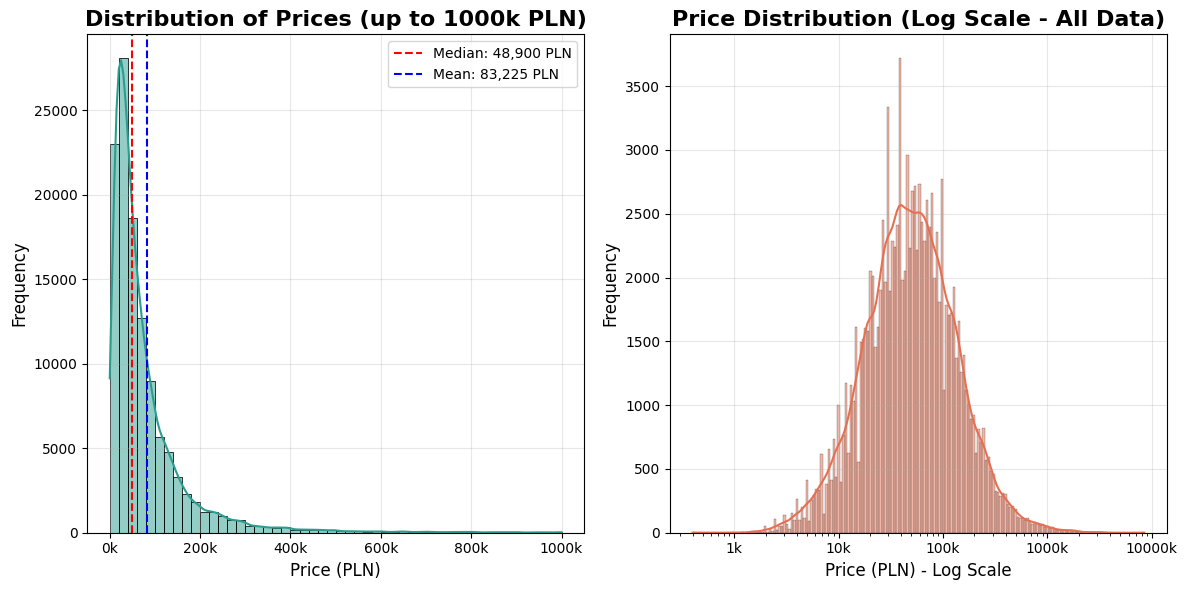

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# We limit all cars to maxiumum of 1mln PLN to have cleaner visualizations
market_limit = 1000000
sns.histplot(cars_data_cleaned[cars_data_cleaned['price_PLN'] <= market_limit]['price_PLN'], 
             kde=True, ax=axes[0], color='#2a9d8f', bins=50)

axes[0].set_title(f'Distribution of Prices (up to {int(market_limit/1000)}k PLN)', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Price (PLN)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].grid(True, alpha=0.3)
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x/1000)}k'))

sns.histplot(cars_data_cleaned['price_PLN'], 
             kde=True, ax=axes[1], color='#e76f51', log_scale=True)

axes[1].set_title('Price Distribution (Log Scale - All Data)', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Price (PLN) - Log Scale', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].grid(True, alpha=0.3)
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x/1000)}k'))

median_price = cars_data_cleaned['price_PLN'].median()
mean_price = cars_data_cleaned['price_PLN'].mean()

axes[0].axvline(median_price, color='red', linestyle='--', label=f'Median: {int(median_price):,} PLN')
axes[0].axvline(mean_price, color='blue', linestyle='--', label=f'Mean: {int(mean_price):,} PLN')
axes[0].legend()

plt.tight_layout()
plt.savefig('../images/eda_price_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

##### Price Distribution

The left chart displays a highly right-skewed distribution, where most observations fall between 0 and 100,000 PLN, with a median of approximately 48,900 PLN.

The mean value is nearly twice as high as the median, indicating the presence of high-priced premium vehicles that pull the average upward. This confirms that the distribution is positively skewed. In such cases, the median provides a more representative measure of the typical car price than the mean.

The right chart shows that applying a logarithmic transformation significantly reduces skewness, making the distribution more symmetrical and closer to a normal distribution.

This suggests that using a log-transformed target variable may improve model performance — particularly for regression algorithms that assume normally distributed residuals. Additionally, log transformation can stabilize variance and reduce the influence of extreme outliers, leading to more robust predictions.

Since real-world pricing data often follows a multiplicative rather than additive structure, modeling the logarithm of price can better capture proportional relationships between features and the target variable.

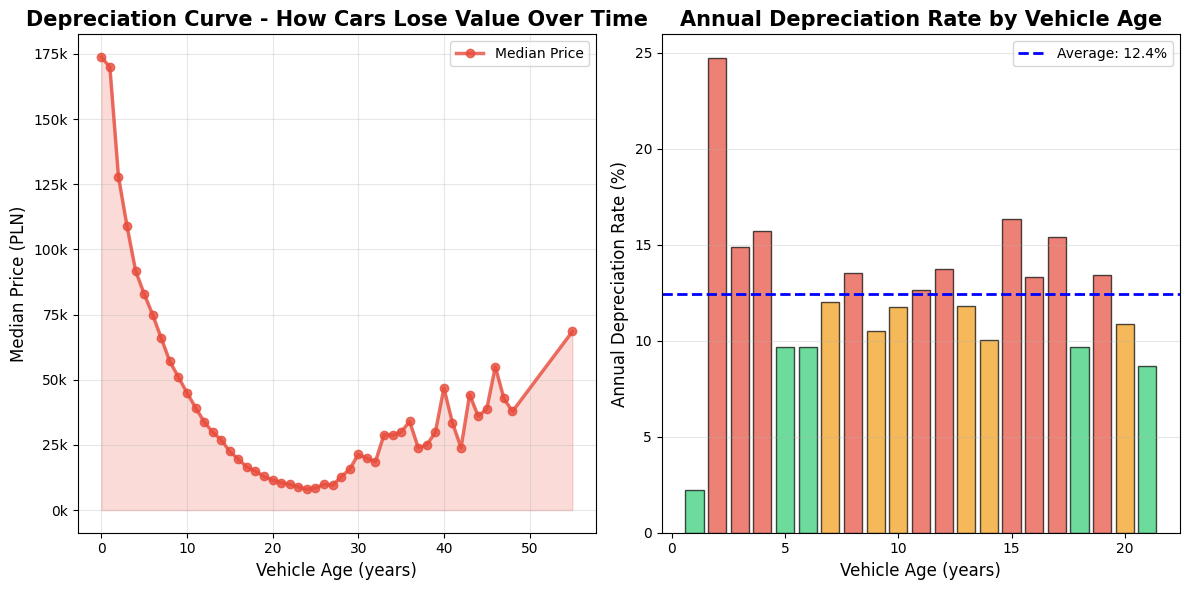

In [29]:
# Depreciation analysis
if 'Offer_publication_date' in cars_data_cleaned.columns:
    LAST_OFFER_YEAR = cars_data_cleaned['Offer_publication_date'].dt.year.max()
    if pd.isna(LAST_OFFER_YEAR):
        LAST_OFFER_YEAR = datetime.now().year
else:
    LAST_OFFER_YEAR = datetime.now().year
cars_data_cleaned['Vehicle_age'] = LAST_OFFER_YEAR - cars_data_cleaned['Production_year']

fig, axes = plt.subplots(1, 2, figsize=(12 ,6))

ax0 = axes[0]

age_price = cars_data_cleaned.groupby('Vehicle_age')['price_PLN'].agg(['median', 'mean', 'count'])
age_price = age_price[age_price['count'] >= 10] 

ax0.plot(age_price.index, age_price['median'], 'o-', linewidth=2.5, 
         markersize=6, color='#e74c3c', label='Median Price', alpha=0.8)
ax0.fill_between(age_price.index, age_price['median'], 
                  alpha=0.2, color='#e74c3c')

ax0.set_xlabel('Vehicle Age (years)', fontsize=12)
ax0.set_ylabel('Median Price (PLN)', fontsize=12)
ax0.set_title('Depreciation Curve - How Cars Lose Value Over Time', 
              fontsize=15, fontweight='bold')
ax0.legend(fontsize=10)
ax0.grid(True, alpha=0.3)
ax0.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x/1000)}k'))

valid_ages = age_price.index.values
valid_prices = age_price['median'].values

ax1 = axes[1]

depreciation_rates = []
for i in range(1, min(22, valid_ages.max())):
    if i in age_price.index and i-1 in age_price.index:
        price_now = age_price.loc[i, 'median']
        price_prev = age_price.loc[i-1, 'median']
        rate = ((price_prev - price_now) / price_prev) * 100
        depreciation_rates.append({'age': i, 'rate': rate})

if depreciation_rates:
    dep_df = pd.DataFrame(depreciation_rates)
    
    colors = ['#e74c3c' if r > 12.4 else '#f39c12' if r > 10 else '#2ecc71' for r in dep_df['rate']]
    
    ax1.bar(dep_df['age'], dep_df['rate'], color=colors, alpha=0.7, edgecolor='black')
    ax1.axhline(y=dep_df['rate'].mean(), color='blue', linestyle='--', 
                linewidth=2, label=f'Average: {dep_df["rate"].mean():.1f}%')
    
    ax1.set_xlabel('Vehicle Age (years)', fontsize=12)
    ax1.set_ylabel('Annual Depreciation Rate (%)', fontsize=12)
    ax1.set_title('Annual Depreciation Rate by Vehicle Age', 
                  fontsize=15, fontweight='bold')
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../images/eda_depreciation_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

##### Depreciation Analysis

The first plot presents the depreciation curve, illustrating how vehicles lose value over time. It is clearly visible that cars experience the most significant value loss within the first five years after purchase, with prices declining by approximately 50% compared to their initial value.

A consistent downward trend is observed until the vehicle reaches around 25 years of age. Beyond this point, prices begin to increase slightly, although minor fluctuations remain present. This pattern suggests that vehicles older than approximately 25 years may belong to the rare, collectible, or classic segment, where scarcity and historical value can drive prices upward despite advanced age.

The second chart presents the annual depreciation rate by vehicle age. The highest depreciation rate occurs between two and three years after purchase, indicating that vehicles lose value most rapidly during the early ownership period.

The annual depreciation rates exhibit notable volatility — some years show rates around 10%, while the following year may spike to 16% or higher. The most prominent peak occurs between the second and third year of ownership, reflecting the well-known rapid value loss during the early ownership period.

These findings confirm that vehicle age is a key structural determinant of price, though its effect is clearly nonlinear. This suggests that modeling approaches capable of capturing nonlinear patterns — such as tree-based algorithms — may perform better than simple linear models.

#### Section II - Feature Relationships

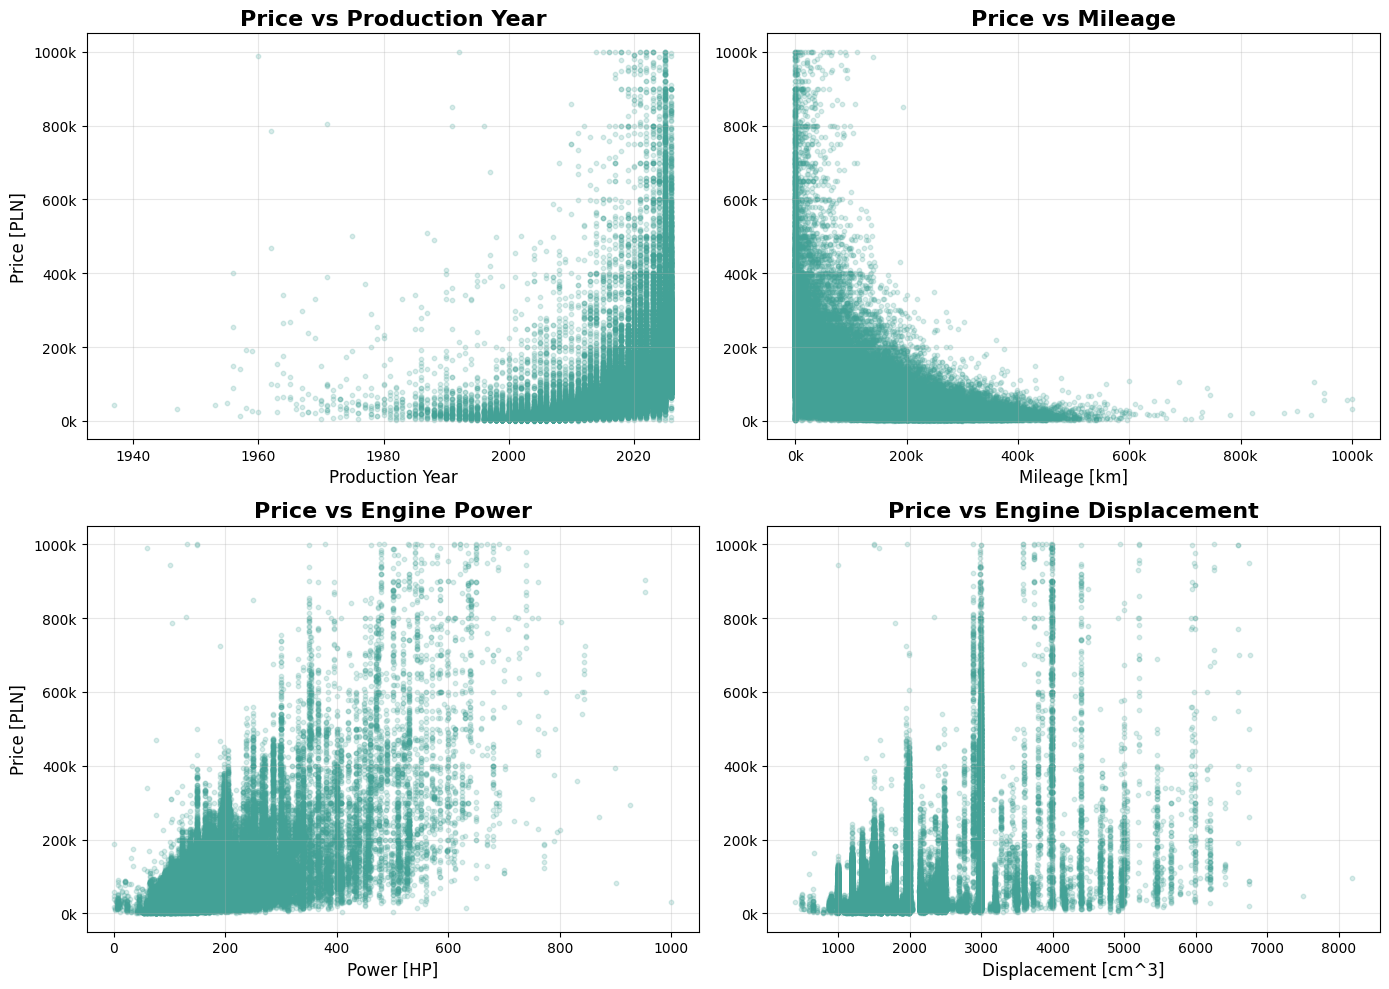

In [30]:
# Top4 important features vs price
point_color = "#43a196"

# Filter data to have cleaner visualizations
plot_df = cars_data_cleaned[
    (cars_data_cleaned['Mileage_km'] <= 1000000) & 
    (cars_data_cleaned['price_PLN'] <= 1000000) &
    (cars_data_cleaned['Power_HP'] <= 1000)
].copy()

fig, ax = plt.subplots(2, 2, figsize=(14, 10))

ax[0,0].scatter(plot_df['Production_year'], plot_df['price_PLN'], alpha=0.2, s=10, c=point_color, edgecolor=None)
ax[0,0].set_title('Price vs Production Year', weight='bold', fontsize=16)
ax[0,0].set_xlabel('Production Year', fontsize=12)
ax[0,0].set_ylabel('Price [PLN]', fontsize=12)

ax[0,1].scatter(plot_df['Mileage_km'], plot_df['price_PLN'], alpha=0.2, s=10, c=point_color, edgecolor=None)
ax[0,1].set_xlabel('Mileage [km]', fontsize=12)
ax[0,1].set_title('Price vs Mileage', weight='bold', fontsize=16)

ax[1,0].scatter(plot_df['Power_HP'], plot_df['price_PLN'], alpha=0.2, s=10, c=point_color, edgecolor=None)
ax[1,0].set_title('Price vs Engine Power', weight='bold', fontsize=16)
ax[1,0].set_xlabel('Power [HP]', fontsize=12)
ax[1,0].set_ylabel('Price [PLN]', fontsize=12)

ax[1,1].scatter(plot_df['Displacement_cm3'], plot_df['price_PLN'], alpha=0.2, s=10, c=point_color, edgecolor=None)
ax[1,1].set_xlabel('Displacement [cm^3]', fontsize=12)
ax[1,1].set_title('Price vs Engine Displacement', weight='bold', fontsize=16)

for a in ax.flat:
    a.grid(alpha=0.3)
    a.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'{int(x/1000)}k'))
    if a.get_xlabel() in ['Mileage [km]']:
        a.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'{int(x/1000)}k'))

plt.tight_layout()
plt.savefig('../images/eda_scatterplots_relations_clean.png', dpi=300, bbox_inches='tight')
plt.show()

##### Top 4 Features vs Price

**Price vs Production Year**:

The plot shows a clear upward trend in car prices as the production year increases. Prices remain relatively stable for older vehicles, but starting around 2015, newer models exhibit significantly higher price levels. This suggests that modern vehicles — likely equipped with improved technology, enhanced safety systems, and higher market demand — command a substantial premium.

**Price vs Mileage**:

There is a strong inverse relationship between mileage and price. Vehicles with lower mileage generally have higher prices, reflecting lower wear and a longer expected remaining lifespan.

A large concentration of vehicles appears around 180,000 km, but their prices vary considerably. This dispersion is likely driven by differences in brand, engine type, condition, trim level, and overall vehicle segment.

**Price vs Power (HP)**:

The relationship indicates that vehicles with higher horsepower tend to have higher prices. High-performance cars (above 500 HP) display the widest price dispersion, likely due to variation in luxury level, brand prestige, exclusivity, and rarity.

This feature appears to be one of the strongest numeric predictors of price.

**Price vs Engine Displacement (cm³)**:

Most vehicles cluster around common engine sizes such as:

- 1,600–2,000 cm³

- 3,000 cm³

- 4,000 cm³

Prices generally increase with engine displacement; however, the relationship is less linear compared to horsepower. This is expected, as displacement does not always directly reflect actual performance due to factors such as turbocharging and hybrid systems.

Very large engines (around 7,000 cm³) are rare and typically appear in American SUVs or specialized high-performance vehicles.

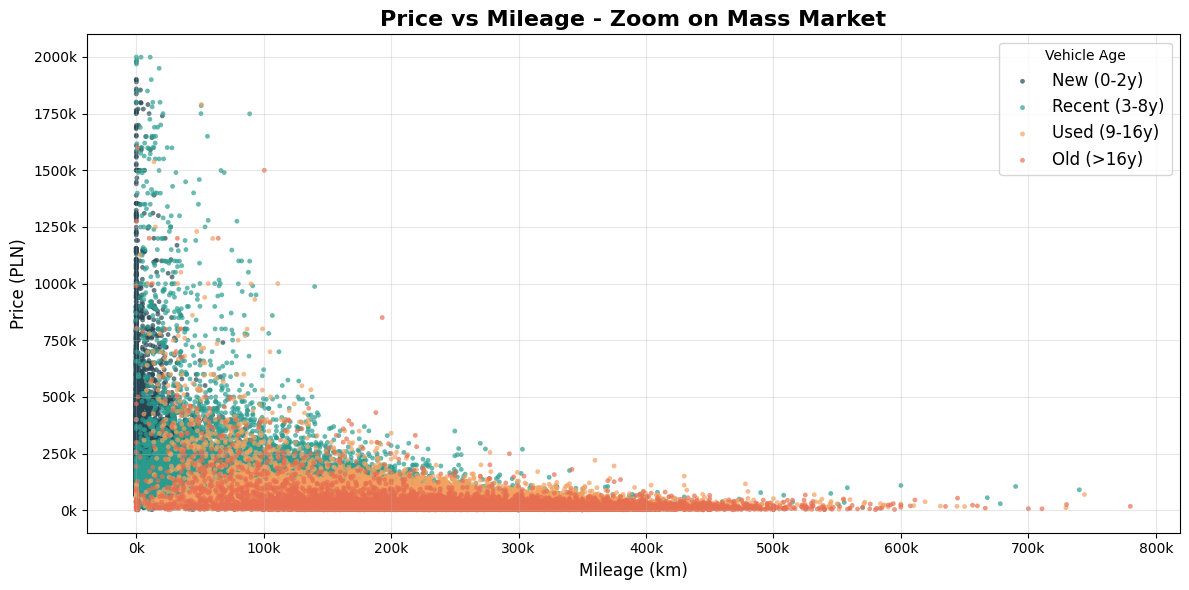

In [38]:
# Mileage vs price (colored by age)
plot_df = cars_data_cleaned[
    (cars_data_cleaned['Mileage_km'] < 800000) & 
    (cars_data_cleaned['price_PLN'] < 2000000) 
].copy()

fig, ax = plt.subplots(figsize=(12, 6))

age_groups = [
    (0, 2, 'New (0-2y)', '#264653'),      
    (3, 8, 'Recent (3-8y)', '#2a9d8f'),   
    (9, 16, 'Used (9-16y)', '#f4a261'),  
    (17, 100, 'Old (>16y)', '#e76f51')    
]

for min_age, max_age, label, color in age_groups:
    mask = (plot_df['Vehicle_age'] >= min_age) & (plot_df['Vehicle_age'] <= max_age)
    subset = plot_df[mask]
    
    ax.scatter(subset['Mileage_km'], 
               subset['price_PLN'], 
               c=color, 
               label=label,
               alpha=0.7, 
               s=12,      
               edgecolor='none')

ax.set_xlabel('Mileage (km)', fontsize=12)
ax.set_ylabel('Price (PLN)', fontsize=12)
ax.set_title('Price vs Mileage - Zoom on Mass Market', 
             fontsize=16, fontweight='bold')

ax.legend(loc='upper right', fontsize=12, title="Vehicle Age")
ax.grid(True, alpha=0.3)

ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x/1000)}k'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x/1000)}k'))

plt.tight_layout()
plt.savefig('../images/eda_mileage_vs_price_by_age.png', dpi=300, bbox_inches='tight')
plt.show()

##### Mileage vs Price by Vehicle Age

As shown in the chart, vehicles with the highest mileage are typically older cars (over 16 years old). Their prices are generally low, in most cases below 50,000 PLN. As the price increases, mileage tends to decrease, indicating a clear negative relationship between these two variables.

Used cars aged between 9 and 16 years rarely exceed 200,000 PLN in price. Their mileage typically ranges from 50,000 km up to 300,000 km, with higher values appearing only occasionally.

More recent vehicles (3–8 years old) mostly have mileage below 100,000 km. Beyond this threshold, the number of observations declines. Prices in this group are distributed across a broad range, mostly between 50,000 PLN and 300,000 PLN. However, there are some observations above this range, which likely represent slightly older supercars or premium-brand vehicles with high value and relatively low mileage.

New cars constitute the smallest group in the dataset. Most of them are clustered around 0 km mileage, with a wide price range—primarily between 50,000 PLN and even 1mln PLN. Some new vehicles have mileage of a few thousand kilometers (but generally not exceeding 20,000 km), and these are typically priced between 200,000 PLN and 500,000 PLN.

Overall, the chart confirms that mileage and vehicle age jointly influence price. While mileage negatively correlates with price, the effect is moderated by age and vehicle segment. Premium vehicles may retain high prices despite relatively higher mileage, whereas older mass-market cars experience both high mileage and low resale value.

This suggests strong interaction effects between Vehicle_age, Mileage_km, and Brand, which tree-based models are particularly well suited to capture.

#### Section III - Categorical Analysis

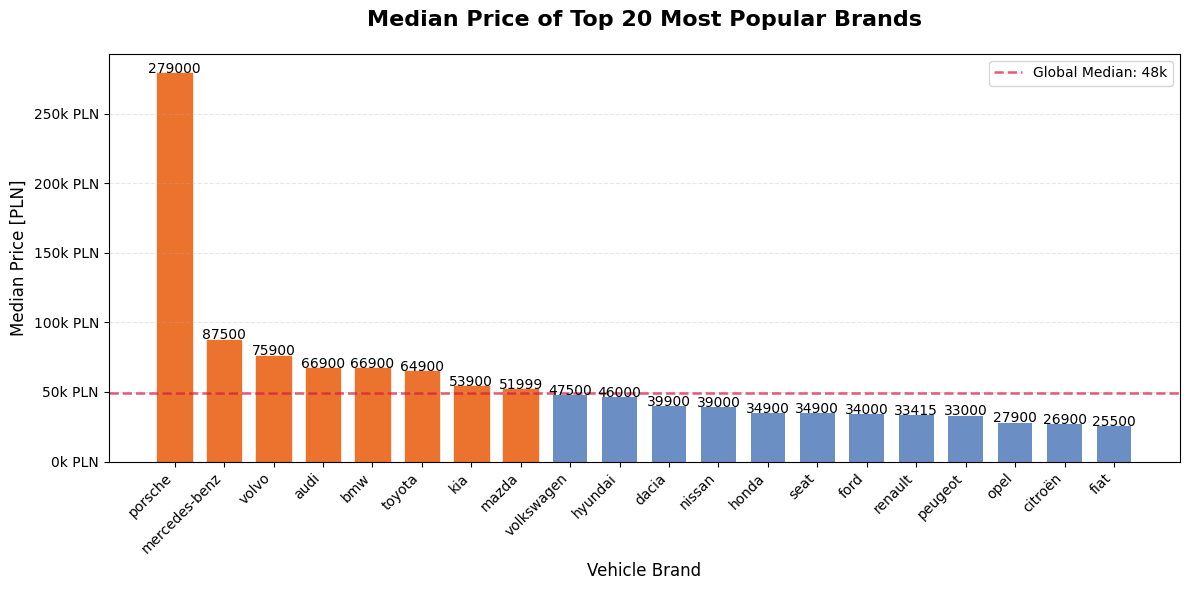

In [39]:
# Median price top 20 brands
stats = cars_data_cleaned.groupby('Vehicle_brand')['price_PLN'].agg(['median', 'count'])

top_20_popular = stats.sort_values(by='count', ascending=False).head(20)
top_20_popular = top_20_popular.sort_values(by='median', ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.bar(top_20_popular.index, top_20_popular['median'], color="#6B8EC5", width=0.7)

market_median_global = cars_data_cleaned['price_PLN'].median()
ax.axhline(market_median_global, color='crimson', linestyle='--', linewidth=1.8, alpha=0.7, label=f'Global Median: {int(market_median_global/1000)}k')

for i in range(len(bars)):
    if bars[i].get_height() > market_median_global:
        bars[i].set_color("#EB732D")

ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f'{int(x/1000)}k PLN'))

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height()+ 300,
             int(bar.get_height()), ha='center', fontsize=10)

plt.title('Median Price of Top 20 Most Popular Brands', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Vehicle Brand', fontsize=12)
plt.ylabel('Median Price [PLN]', fontsize=12)
plt.xticks(rotation=45, ha='right') 

plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig('../images/eda_median_preice_top20_brands.png', dpi=300, bbox_inches='tight')
plt.show()

##### Top Brands Price Comparison

This bar chart illustrates the most popular vehicle brands alongside their median prices. Brands exceeding the global median are highlighted to represent the high-value market segment.

Porsche leads the ranking with a median price of approximately 279,000 PLN. German engineering dominates the top five positions, with Mercedes-Benz in second place (87,500 PLN), followed by BMW and Audi, both averaging around 66,900 PLN. Another premium European brand, Volvo, secures the third spot with a median price of nearly 75,900 PLN.

Selected Asian manufacturers also show significant value; Toyota holds a median of around 65,000 PLN, while Kia and Mazda follow at 54,000 PLN and 52,000 PLN, respectively.

The remaining brands, primarily from Asian, French, and American manufacturers, exhibit noticeably lower median prices, ranging from 25,000 PLN to 48,000 PLN. These values are roughly two to three times lower than those of the leading German brands. 

Overall, German manufacturers clearly dominate the upper market segment in terms of both popularity and pricing within this dataset.

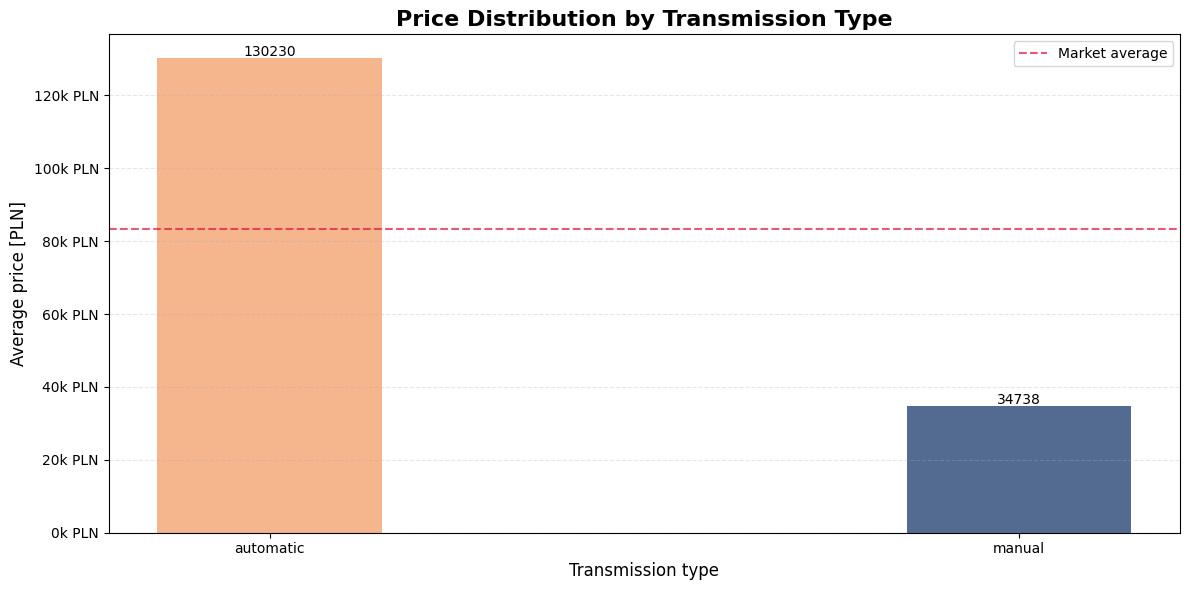

In [40]:
# Price distribution by transmission type
stats = (
    cars_data_cleaned.groupby('Transmission')
    .agg(avg_price=('price_PLN','mean'), count=('price_PLN','size'))
    .sort_values('avg_price', ascending=False)
)

fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.bar(stats.index, stats['avg_price'], color=["#F5B58D", "#546B91"], width = 0.3)

market_mean = cars_data_cleaned['price_PLN'].mean()
ax.axhline(market_mean, color='crimson', linestyle='--', alpha=0.7, label='Market average')

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height()+500,
             int(bar.get_height()), ha='center', fontsize=10)

ax.set_title('Price Distribution by Transmission Type', fontsize=16, weight='bold')
ax.set_ylabel('Average price [PLN]', fontsize=12)
ax.set_xlabel('Transmission type', fontsize=12)

ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f'{int(x/1000)}k PLN'))

ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig('../images/eda_price_distribution_by_transmission_type.png', dpi=300, bbox_inches='tight')
plt.show()

##### Price Comparison by Transmission Type

The bar plot presents the average car price depending on the type of transmission: manual or automatic. Vehicles equipped with automatic transmission show a clear price advantage, with an average price over 130,000 PLN. In contrast, manual cars have an average price of less than 35,000 PLN — roughly three times lower than automatic vehicles.

This substantial difference likely reflects market structure. Automatic transmissions are more commonly found in newer or premium vehicles, which typically command higher prices. Manual cars, on the other hand, are often older, smaller, or entry-level models, which tend to be less expensive.

From a modeling perspective, this suggests that Transmission Type is an important categorical feature. A machine learning model may learn that:

- Automatic transmission is associated with higher vehicle prices,

- Manual transmission is more common in lower price segments.

Moreover, transmission type may interact with other features (e.g., brand, engine size, vehicle segment), which could further influence price predictions.

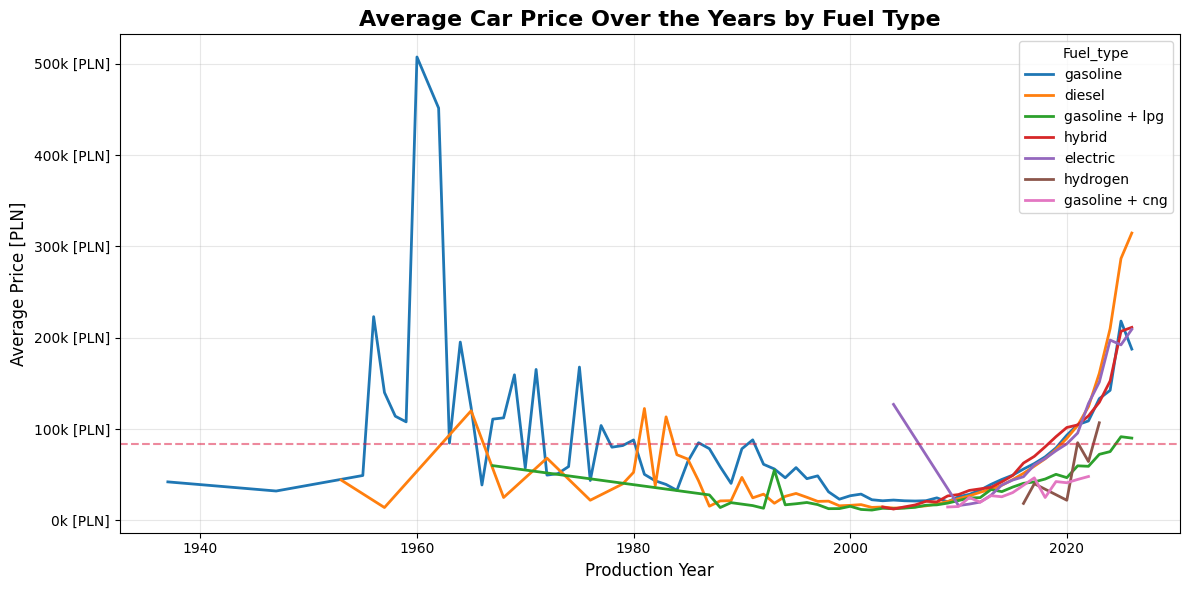

In [41]:
# Car price over the years by fuel type
plot_df = cars_data_cleaned[
    (cars_data_cleaned['Mileage_km'] <= 1000000) & 
    (cars_data_cleaned['price_PLN'] <= 1000000) &
    (cars_data_cleaned['Power_HP'] <= 1000)
].copy()

fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(data=plot_df,
            x='Production_year',
            y='price_PLN',
            hue='Fuel_type',
            errorbar=None, 
            lw=2)

overall_mean = cars_data_cleaned['price_PLN'].mean()
ax.axhline(overall_mean, color='crimson', linestyle='--', alpha=0.5, label='Market average')

ax.set_title("Average Car Price Over the Years by Fuel Type", weight='bold', fontsize=16)
ax.set_xlabel("Production Year", fontsize=12)
ax.set_ylabel("Average Price [PLN]", fontsize=12)

ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f'{int(x/1000)}k [PLN]'))

ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../images/eda_average_car_price_over_the_years_by_fuel_type.png', dpi=300, bbox_inches='tight')
plt.show()

##### Car Price Analysis by Fuel Type

From the 1920s through the late 1990s, gasoline-powered vehicles dominated production, with prices fluctuating gradually over the decades. During the 1980s and 1990s, diesel cars gained significant popularity, particularly in Europe. They were often priced slightly lower than comparable gasoline models due to fuel efficiency advantages and strategic market positioning. A noticeably volatile trend is visible between the 1950s and 1990s; prices from this era are more difficult to predict as many vehicles hold collectible value, which introduces higher variance into the data.

From the late 1990s onward, price structures across fuel types became more defined, with a significant shift occurring after 2010. During this period, average vehicle prices rose across all fuel categories. The most dramatic increase is observed in electric vehicles (EVs), showing a sharp upward trend driven by rapid technological advancements, high battery costs, and their placement within the premium market segment.

While diesel, hybrid, and gasoline vehicles have also seen growth, their pace has been more moderate. In contrast, CNG and LPG-equipped gasoline vehicles show the most stable and lowest price increases, as they typically cater to the most cost-sensitive market segments.

Furthermore, fuel type interacts significantly with variables such as production year, engine power, and brand. Since electric vehicles are generally newer and associated with high-end manufacturers, tree-based algorithms are well-suited to capturing these nonlinear relationships and complex feature interactions.

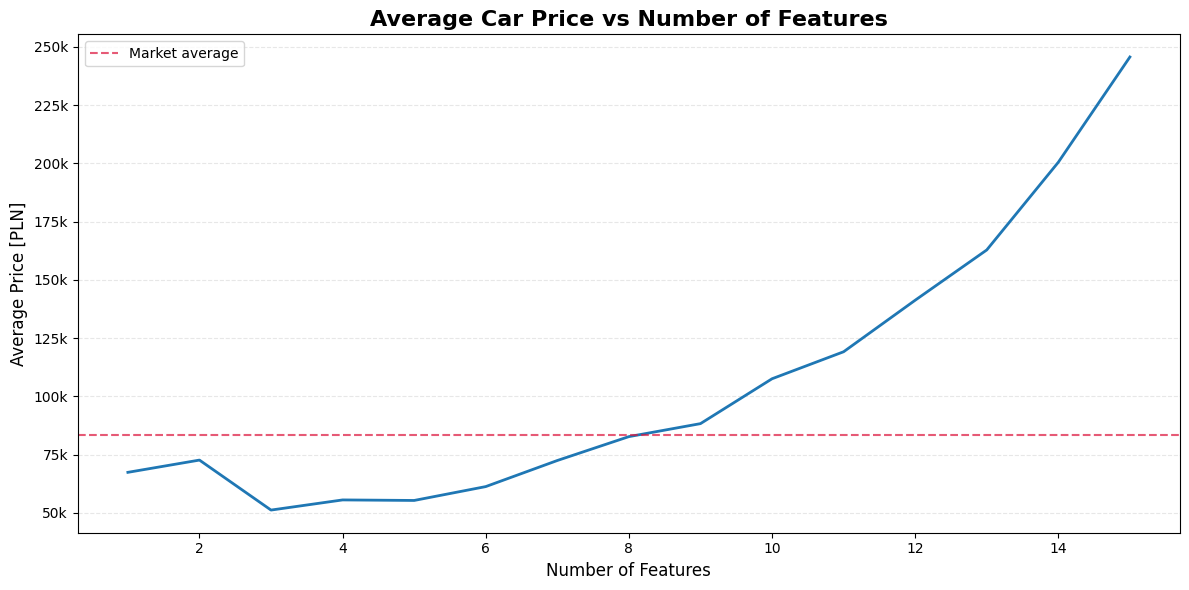

In [35]:
# Average Car Price vs Number of Features
def count_features(f):
    f = str(f).strip('[]').strip()
    if not f or f == '':
        return 0
    return len([ft.strip() for ft in f.split(',') if f.strip()])

cars_data_cleaned['Num_features'] = cars_data_cleaned['Features'].apply(count_features)

stats = cars_data_cleaned.groupby('Num_features').agg(
    avg_price = ('price_PLN', 'mean'),
    count = ('price_PLN', 'size')
).reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=stats, x='Num_features', y='avg_price', linewidth=2)

market_mean = cars_data_cleaned['price_PLN'].mean()
plt.axhline(market_mean, color='crimson', linestyle='--', alpha=0.7, label='Market average')

plt.title('Average Car Price vs Number of Features', fontsize=16, weight='bold')
plt.xlabel('Number of Features', fontsize=12)
plt.ylabel('Average Price [PLN]', fontsize=12)

plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f'{int(x/1000)}k'))

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('../images/eda_average_car_price_vs_number_of_features.png', dpi=300, bbox_inches='tight')
plt.show()

##### Price vs Number of Vehicle Features

The line plot illustrates a strong positive correlation between the number of vehicle features and the average car price. Vehicles with minimal equipment (approximately 2–8 features) exhibit relatively low and stable average prices, typically ranging from 20,000 to 40,000 PLN. Notably, there is an anomalous spike in the 0–2 feature range, which likely represents a specific niche segment or a subset of atypical listings.

Beyond the 5-feature threshold, a clear upward trend emerges. Average prices rise steadily—from approximately 60,000 PLN to over 100,000 PLN—in tandem with increased equipment levels. The most heavily equipped vehicles command premium prices exceeding 200,000 PLN, with peaks reaching roughly 260,000 PLN, strongly indicating their placement in the luxury or high-performance segments.

This relationship highlights the feature count as a highly informative predictor for price modeling. It serves as a proxy not only for equipment richness but also for underlying vehicle class and brand positioning. However, individual features can have a disproportionate impact on valuation. For instance, specific premium trims like the Mercedes-Benz AMG Line or Volkswagen R-Line inherently drive up market value. Therefore, while this visualization effectively illustrates the broader trend, accurate price prediction requires models capable of capturing these specific, high-value feature interactions.

#### Section IV - Multivariate and Correlation

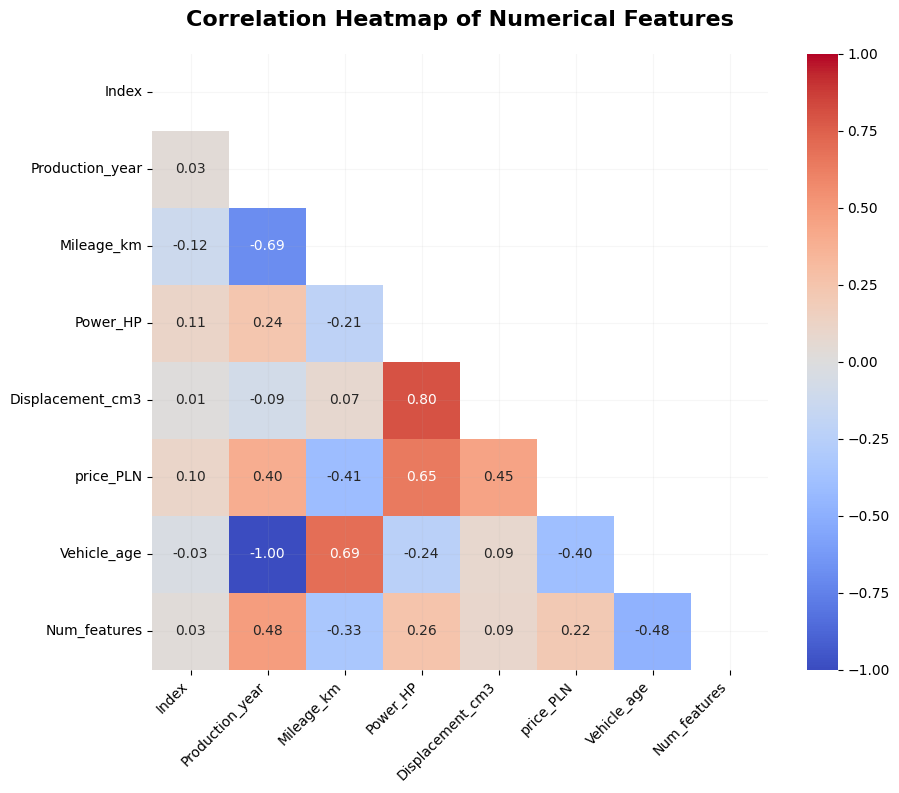

In [36]:
# Correlation heatmap
cols_to_keep = [col for col in cars_data_cleaned.columns if col != 'First_owner']
corr = cars_data_cleaned[cols_to_keep].select_dtypes(include=[np.number]).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(10, 8))
sns.heatmap(corr,
            mask=mask,
            annot=True,
            vmin=-1,
            vmax=1, 
            cmap='coolwarm', 
            center=0, 
            fmt='.2f',
            square=True
)
plt.title("Correlation Heatmap of Numerical Features", 
          fontsize=16, 
          fontweight="bold", 
          pad=20)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.grid(True, alpha=0.1)
plt.savefig('../images/eda_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

##### Correlation Heatmap Analysis

The provided heatmap displays the Pearson correlation coefficients among the numerical features in the dataset, revealing several key relationships crucial for price prediction.

As expected, Vehicle_age and Production_year exhibit a perfect negative correlation (-1.00), meaning they represent the exact same information; one of these variables must be dropped before model training to prevent perfect multicollinearity.

Focusing on the target variable, price_PLN, the strongest positive driver is Power_HP (0.65), indicating that engine performance is a primary determinant of a vehicle's market value. Production_year also shows a strong positive correlation with price (0.40), confirming that newer cars command higher prices. Conversely, Mileage_km has a notable negative impact on price (-0.41), which aligns with the logical depreciation of vehicles as they are driven more.

An interesting technical relationship exists between Power_HP and Displacement_cm3 (0.80). This high positive correlation is physically intuitive—larger engines generally produce more power—but it also signals potential multicollinearity that linear models might struggle with.

Furthermore, Num_features (the count of vehicle equipment) shows a moderate positive correlation with Production_year (0.48) and a negative correlation with Vehicle_age (-0.48), suggesting that newer cars tend to be better equipped. It also has a moderate positive correlation with price (0.22).

Finally, the Index variable shows correlations near zero with all other features, confirming it acts merely as an identifier and holds no predictive value, thus it should be excluded from the modeling process.

#### Exploratory Data Analysis Summary

The exploratory analysis provided a comprehensive overview of the factors driving used car prices in the Polish market. The key findings are summarized below:

- Primary Price Drivers: Strong correlations were identified between Price and technical specifications. Vehicle Age (Production Year) and Mileage are the most significant drivers of depreciation, showing a clear negative correlation with price. Conversely, Engine Power (HP) is the strongest positive predictor of value.

- Brand Segmentation: The categorical analysis revealed distinct price tiers. While mass-market brands dominate in volume, premium brands (e.g., BMW, Mercedes-Benz, Audi) maintain significantly higher median prices, often exceeding the global market median even in older year brackets.

- Technical Trends: Multivariate analysis confirmed that Automatic Transmissions consistently command a price premium across all body types. SUVs and Estates (Combi) represent the highest-value segments, showing better value retention compared to smaller body styles like hatchbacks.

- Fuel & Technology: Price trends over time highlight the rising valuation of Hybrid and Electric vehicles in recent years, though traditional Internal Combustion Engines (Diesel/Petrol) still constitute the bulk of the stable secondary market.

- Data Quality & Readiness: By addressing outliers (clipping mileage and price extremes) and handling missing values, the dataset has been refined. The identified linear and non-linear relationships confirm that the data is well-suited for advanced predictive modeling (e.g., Gradient Boosting or Random Forest).

---

## Feature Engineering

Feature Engineering serves as the critical bridge between raw automotive specifications and algorithmic predictive power. By synthesizing domain-specific interactions—such as Depreciation Curves (Age vs. Mileage) or Performance Ratios (HP per Liter)—we enable the model to transcend simple linear approximations. This process effectively projects data into a higher-dimensional space where complex, non-linear market dynamics become discernible, significantly reducing the model’s bias and enhancing its generalization on unseen data.

The Age_category feature groups vehicles based on their age, which is particularly important for modeling depreciation effects. This categorization can help capture structural differences between new, recent, used, and older vehicles. Additionally, binary indicators derived from such categories may improve the performance of tree-based models by enabling clearer decision splits.

In [42]:
def new_categories(age):
    if age < 3:
        return 'New'
    elif age < 9:
        return 'Recent'
    elif age < 17:
        return 'Used'
    else:
        return 'Old'
    
cars_data_cleaned['Age_category'] = cars_data_cleaned['Vehicle_age'].apply(new_categories)

cars_data_cleaned['Is_new_car'] = (cars_data_cleaned['Vehicle_age'] < 3).astype(int)
cars_data_cleaned['Is_old_car'] = (cars_data_cleaned['Vehicle_age'] > 16).astype(int)

By normalizing mileage by vehicle age, we reduce bias caused by simple time accumulation and allow the model to better distinguish between lightly used and heavily used vehicles. This engineered feature may improve predictive performance by capturing usage efficiency rather than absolute mileage.

In [43]:
cars_data_cleaned['Mileage_per_year'] = cars_data_cleaned['Mileage_km'] / cars_data_cleaned['Vehicle_age'].replace(0, 1)

def usage_category(mileage_per_year):
    if mileage_per_year < 10000:
        return 'Low'
    elif mileage_per_year < 20000:
        return 'Average'   
    elif mileage_per_year < 30000:
        return 'High'      
    else:
        return 'Very_High'  
    
cars_data_cleaned['Usage_intensity'] = cars_data_cleaned['Mileage_per_year'].apply(usage_category)

The Power_per_liter feature acts as a normalized performance metric, capturing engine efficiency rather than raw output. This transformation reduces redundancy between displacement and horsepower while providing a more meaningful signal of technological sophistication, which may significantly enhance model performance.

In [44]:
cars_data_cleaned['HP_per_liter'] = cars_data_cleaned['Power_HP'] / (cars_data_cleaned['Displacement_cm3'] / 1000)

def performance_category(hp_per_liter):
    if pd.isna(hp_per_liter):
        return 'Unknown'
    elif hp_per_liter < 60:
        return 'Economy'
    elif hp_per_liter < 100:
        return 'Standard'     
    elif hp_per_liter < 150:
        return 'Performance'
    else:
        return 'High_Performance' 
    
cars_data_cleaned['Performance_category'] = cars_data_cleaned['HP_per_liter'].apply(performance_category)

Some premium segment cars need to be treated separately because their values can fluctuate by several hundred thousand PLN. Therefore, it is useful to divide the car market into two segments: premium and mass-market vehicles. This distinction helps models better capture differences in pricing patterns, as premium cars often follow different value dynamics than standard vehicles.

Moreover, an additional variable is created to identify supercars, whose prices can be highly specific and sometimes reach several million PLN. Including this feature allows the model to account for extreme price ranges that are not typical for most vehicles.


In [45]:
premium_brands = [
    'alfa romeo', 'alpine', 'aston martin', 'audi', 'bentley', 'bmw',
    'cadillac', 'cupra', 'ds automobiles', 'ferrari', 'infiniti',
    'jaguar', 'lamborghini', 'land rover', 'lexus', 'lincoln',
    'lotus', 'maserati', 'maybach', 'mclaren', 'mercedes-benz',
    'mini', 'porsche', 'rolls-royce', 'tesla'
]

cars_data_cleaned['Is_premium'] = cars_data_cleaned['Vehicle_brand'].isin(premium_brands).astype('Int64')

cars_data_cleaned['Is_supercar'] = ((cars_data_cleaned['Power_HP'] > 500) & (cars_data_cleaned['Is_premium'] == 1)).astype('Int64')

As the depreciation charts showed, cars older than 25 years often begin to increase in value. From that point, some vehicles may become rare or collectible. Therefore, it is useful for the model to consider whether a car belongs to this category.

To capture this effect, we create an is_collector variable, which indicates whether a vehicle may have collector potential. This feature helps the model recognize specific cars whose prices may deviate from standard depreciation patterns.


In [46]:
cars_data_cleaned['is_collector'] = (cars_data_cleaned['Vehicle_age'] > 25).astype(int)

Some columns are not informative for further analysis or model development and can therefore be removed:

- Vehicle_generation: This feature contains a substantial number of missing values, which reduces its reliability. Additionally, we already have sufficient information from features such as brand, model, and other technical specifications to capture vehicle characteristics.

- Production_year: This variable is highly correlated with Vehicle_age, as demonstrated in the correlation heatmap. Since Vehicle_age directly reflects the depreciation effect and contains the same underlying information, Production_year can be removed to avoid redundancy and multicollinearity.

- Index and Offer_publication_date: These columns do not provide meaningful predictive information for price estimation.

In [47]:
from datetime import datetime as _dt

# Extract Listing_year before dropping Offer_publication_date
# (lets models distinguish 2019 prices from 2024 prices for the same car specs)
if 'Offer_publication_date' in cars_data_cleaned.columns:
    cars_data_cleaned['Listing_year'] = (
        pd.to_datetime(cars_data_cleaned['Offer_publication_date'], errors='coerce')
        .dt.year
        .fillna(_dt.now().year)
        .astype(int)
    )

cols_to_drop_fe = ['Vehicle_generation', 'Production_year', 'Index', 'Offer_publication_date']
cars_data_cleaned = cars_data_cleaned.drop(columns=cols_to_drop_fe, errors='ignore')

The next step is to perform a train–test split and handle the remaining missing values. The imputation process will be applied separately to numerical and categorical features.

In [48]:
# Train test split
X = cars_data_cleaned.drop('price_PLN', axis=1)
y = cars_data_cleaned['price_PLN']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2 ,random_state=42)

After performing the train–test split, the next step is to handle missing values and create additional transformed features. For the Doors_number variable, missing values are filled using the mode, as the number of doors represents a small discrete natural number, making the most frequent value a more appropriate choice than the mean or median. For the remaining numerical variables, the median is used to impute missing values, as it is more robust to outliers than the mean.

Once the missing values are properly handled, logarithmic transformations of selected variables can be created. It is important to perform the imputation step before generating derived features, because creating logarithmic variables prior to filling missing values could introduce additional undefined values and propagate missing data through the dataset.

After completing the imputation process, we can safely generate derived features, including logarithmic transformations and other engineered variables, which may help the model capture non-linear relationships between predictors and the target variable.

In [49]:
# Filling missing values (numeric columns)
X_train_filled = X_train.copy()
X_test_filled = X_test.copy()

numeric_cols_with_missing = ['Mileage_km', 'Power_HP', 'Displacement_cm3']

for col in numeric_cols_with_missing:
    fill_value = X_train_filled[col].median()

    X_train_filled[col] = X_train_filled[col].fillna(fill_value)
    X_test_filled[col] = X_test_filled[col].fillna(fill_value)

# Since the base columns have been filled, we can now proceed to filling the derived columns
def filling_derived_columns(df):
    df['Mileage_km_log'] = np.log1p(df['Mileage_km'])
    df['Power_HP_log'] = np.log1p(df['Power_HP'])
    df['Displacement_cm3_log'] = np.log1p(df['Displacement_cm3'])
    
    df['HP_per_liter'] = df['Power_HP'] / (df['Displacement_cm3'] / 1000)
    df['HP_per_liter'] = df['HP_per_liter'].replace([np.inf, -np.inf], 0)
    df['Mileage_per_year'] = df['Mileage_km'] / df['Vehicle_age'].replace(0, 1)
    
    return df

X_train_filled = filling_derived_columns(X_train_filled)
X_test_filled = filling_derived_columns(X_test_filled)

In [50]:
# Filling missing values (categorical columns)
if 'Transmission' in X_train_filled.columns:
    mode_result = X_train_filled['Transmission'].mode()
    train_mode = mode_result.iloc[0] if not mode_result.empty else 'Unknown'
    
    X_train_filled['Transmission'] = X_train_filled['Transmission'].fillna(train_mode)
    X_test_filled['Transmission'] = X_test_filled['Transmission'].fillna(train_mode)

X_train = X_train_filled
X_test = X_test_filled

Most relationships between vehicle characteristics and car prices are non-linear. For instance, two cars produced in the same year may differ significantly in price due to differences in mileage, engine power, or available amenities. Because of these complexities, simple linear relationships may not be sufficient to accurately model price behavior.

To better capture these non-linear effects, squared transformations of several key variables were introduced, including Mileage, Power, and Vehicle_age. These transformations allow the model to account for curvature in the relationship between predictors and the target variable, which is common in car price depreciation patterns.

In addition to non-linear transformations, feature interactions were also created. In many cases, the combined effect of two variables can be more informative than each variable considered separately. For example, the interaction between vehicle age and mileage can better represent the overall usage intensity of a vehicle.

Furthermore, several derived features were introduced to encode more complex relationships within the data. Variables such as Mileage_per_year and HP_per_liter aim to capture vehicle usage and engine efficiency more precisely. These engineered features help the model extract meaningful patterns that might otherwise be difficult to learn directly from the raw variables.

In [51]:
X_train['Vehicle_age_squared'] = X_train['Vehicle_age'] ** 2
X_test['Vehicle_age_squared'] = X_test['Vehicle_age'] ** 2

X_train['Power_HP_squared'] = X_train['Power_HP'] ** 2
X_test['Power_HP_squared'] = X_test['Power_HP'] ** 2

X_train['Mileage_km_squared'] = X_train['Mileage_km'] ** 2
X_test['Mileage_km_squared'] = X_test['Mileage_km'] ** 2

X_train['Age_Mileage_interaction'] = X_train['Vehicle_age'] * X_train['Mileage_km']
X_test['Age_Mileage_interaction'] = X_test['Vehicle_age'] * X_test['Mileage_km']

X_train['Power_Age_interaction'] = X_train['Power_HP'] * X_train['Vehicle_age']
X_test['Power_Age_interaction'] = X_test['Power_HP'] * X_test['Vehicle_age']

if 'Mileage_per_year' in X_train.columns:
    X_train['Mileage_per_year_Age'] = X_train['Mileage_per_year'] * X_train['Vehicle_age']
    X_test['Mileage_per_year_Age'] = X_test['Mileage_per_year'] * X_test['Vehicle_age']

Important matter during creating and preparing new data is encoding categorical columns, as machine learning models cannot interpret text or sentences directly. Models operate only on numerical values, therefore categorical variables must be transformed into a numerical representation.

In this project, separate pipelines were created for each model. The pipeline for linear regression includes polynomial features in order to capture potential non-linear relationships between variables. Additionally, SimpleImputer is used to handle missing values that the model cannot process directly, while PowerTransformer helps transform feature distributions to be closer to a Gaussian distribution. Finally, categorical variables are encoded so they can be used by the model.

Tree-based models require a slightly different preprocessing approach. These models are generally better at capturing non-linear relationships and can sometimes handle missing values more effectively. However, to ensure consistency and stability of the training process, SimpleImputer is still applied to fill missing values. Categorical variables are encoded using OrdinalEncoder, which converts category labels into numerical values.

In [52]:
# Categorical columns encoding
num_pipeline_tree = SimpleImputer(strategy='median')

cat_pipeline_tree = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

preprocessor_tree = ColumnTransformer([
    ('num', num_pipeline_tree, make_column_selector(dtype_include='number')),
    ('cat', cat_pipeline_tree, make_column_selector(dtype_include=['object', 'category']))
])

In [53]:
num_cols = ['Mileage_km', 'Power_HP', 'Displacement_cm3', 'Vehicle_age']
cat_cols_to_encode = ['Vehicle_brand', 'Vehicle_model']
cat_cols_simple = ['Fuel_type', 'Transmission']

num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('yeo', PowerTransformer(method='yeo-johnson')),
    ('poly', PolynomialFeatures(degree=2, interaction_only=True))

])

target_encoder = TargetEncoder(smoothing=200)

preprocessor_mastered = ColumnTransformer([
    ('num', num_transformer, num_cols),
    ('target', target_encoder, cat_cols_to_encode),
    ('cat_simple', OneHotEncoder(handle_unknown='ignore'), cat_cols_simple)
])

#### Feature Engineering & Preprocessing Summary

This section focuses on comprehensive feature engineering and data preprocessing to prepare the dataset for machine learning models. We begin by extracting the listing year from the publication date to help the model account for market inflation and varying pricing trends over time. Redundant or highly correlated columns, such as the production year and index, are subsequently dropped to reduce noise and prevent multicollinearity. 

The dataset is then divided into training and testing sets using a standard 80/20 split to ensure an objective evaluation of our models. To capture deeper vehicle characteristics, we engineer several domain-specific variables based on automotive knowledge. For instance, calculating horsepower per liter allows us to classify cars into distinct performance categories ranging from economy to high performance. Similarly, we compute the average annual mileage to assess the historical usage intensity of each vehicle. 

Vehicle age is also transformed into intuitive categorical bins—such as New, Recent, Used, and Old—alongside binary flags indicating exceptionally new or old cars. To help algorithms capture non-linear market behaviors, we explicitly engineer polynomial features by squaring key metrics like age, power, and mileage. We also introduce interaction terms, such as multiplying age by mileage, reflecting how these combined factors accelerate a car's depreciation. 

For the modeling phase, we construct two distinct preprocessing pipelines tailored to different algorithm architectures. The first pipeline is optimized for tree-based models, utilizing median imputation for numericals and efficient ordinal encoding for categorical variables. The second, more advanced pipeline is designed to strictly normalize and encode features for models sensitive to data distributions. It applies Yeo-Johnson transformations to stabilize numerical variance and automatically generates secondary polynomial interactions. Furthermore, it intelligently handles categorical data by applying target encoding to high-cardinality features like brand and model, while one-hot encoding simpler features like fuel type.

## Models Building

### First Model - Linear Regression

Linear Regression serves as a fundamental pillar in car price prediction, acting as an essential baseline for all subsequent complex modeling. Its primary strength lies in its unparalleled interpretability, allowing stakeholders to easily comprehend the logic behind a vehicle's valuation. By establishing clear mathematical relationships, it clarifies how critical factors—such as mileage, production year, and engine capacity—directly influence market price. The model’s coefficients provide a precise, quantifiable measure of how much the price shifts for every unit of change in a specific feature. This transparency is vital for validating domain-specific assumptions, ensuring that the data aligns with real-world automotive market trends. 

Furthermore, the insights gained from these coefficients act as a strategic guide for feature engineering, highlighting which variables might require non-linear transformations. Linear Regression also functions as a powerful diagnostic tool, helping to identify potential issues like multicollinearity between features like power and displacement. Despite its simplicity, it often captures a significant portion of the price variance, offering high computational efficiency compared to black-box algorithms. 

Using this model facilitates effective communication with non-technical users by providing a clear and justifiable explanation for every prediction. Ultimately, it bridges the gap between raw data and actionable business insights, setting a solid foundation for more advanced predictive architectures like XGBoost or LightGBM.

In [54]:
#Pipeline
pipeline_reg = Pipeline([
    ('preprocessor', preprocessor_mastered),
    ('model', Ridge())
])

In [55]:
# Setting hyperparameters
param_grid = {
    'model__alpha': [0.1, 1.0, 5.0, 10.0, 100.0],
    'model__solver': ['auto', 'cholesky', 'lsqr'],
    'model__fit_intercept': [False, True]
}

scoring = {
    'r2': 'r2',
    'neg_rmse': 'neg_root_mean_squared_error',
    'neg_mae': 'neg_mean_absolute_error',
    'neg_mse': 'neg_mean_squared_error'
}

In [56]:
# Using KFold and GridSearch
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

grid_log = GridSearchCV(
    estimator=pipeline_reg,
    param_grid=param_grid,
    scoring=scoring,
    refit='neg_rmse',
    cv=kfold,
    n_jobs=-1,
    verbose=1
)

In [57]:
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

In [58]:
grid_log.fit(X_train, y_train_log)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,estimator,"Pipeline(step...l', Ridge())])"
,param_grid,"{'model__alpha': [0.1, 1.0, ...], 'model__fit_intercept': [False, True], 'model__solver': ['auto', 'cholesky', ...]}"
,scoring,"{'neg_mae': 'neg_mean_absolute_error', 'neg_mse': 'neg_mean_squared_error', 'neg_rmse': 'neg_root_mean_squared_error', 'r2': 'r2'}"
,n_jobs,-1
,refit,'neg_rmse'
,cv,KFold(n_split... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('target', ...), ...]"


In [59]:
#Best Lineear Regression Model
best_lin = grid_log.best_estimator_

In [62]:
y_test_log_pred = best_lin.predict(X_test)
y_train_log_pred = best_lin.predict(X_train)

# The np.clip function is applied to the log-scale predictions to ensure 
# they remain strictly within the target range observed during training
y_train_log_pred = np.clip(y_train_log_pred, y_train_log.min(), y_train_log.max())
y_test_log_pred = np.clip(y_test_log_pred, y_train_log.min(), y_train_log.max())

# Converting values to more readable form
y_train_pred = np.expm1(y_train_log_pred)
y_test_pred = np.expm1(y_test_log_pred)

In [63]:
# Checking some metrics
def metrics(y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred)

    return {'R2': r2, 'RMSE': rmse, 'MAE': mae, 'MAPE': mape}

train_metrics = metrics(y_train, y_train_pred)
test_metrics = metrics(y_test, y_test_pred)
metrics_df = pd.DataFrame({ 
    'Train': train_metrics,
    'Test': test_metrics
})

metrics_df

,Train,Test
R2,0.726697,0.724459
RMSE,70720.802683,69707.109808
MAE,19247.267850,19354.808312
MAPE,0.283638,0.284647


### Linear Regression Performance

The evaluation metrics indicate that the model provides a highly stable and well-generalized predictive framework for vehicle valuation. 

- With an $R^2$ value of approximately 0.72 on both the training and testing sets, the model successfully explains 72% of the variance in car prices. A key observation is the minimal discrepancy between training and testing results, which proves that the model is not suffering from overfitting and generalizes effectively to unseen data. 

- The Mean Absolute Error (MAE) of roughly 19,354 PLN gives a practical sense of the model's precision, representing the average expected deviation from the actual price. However, the significantly higher Root Mean Squared Error (RMSE) of approximately 69,707 PLN suggests the presence of large outliers in the dataset. These outliers likely represent luxury or high-performance vehicles where the model’s predictions deviate significantly from the market value. 

- The Mean Absolute Percentage Error (MAPE) stands at 28%, providing a relative measure of the prediction accuracy across different price segments. This consistency in MAPE across both splits (0.283 vs. 0.284) further confirms that the error distribution is uniform and predictable. 

While these results represent a solid baseline, the gap between MAE and RMSE indicates that the model could benefit from better handling of premium vehicle niches. Overall, the current metrics demonstrate a robust foundation for an automated valuation tool, balancing statistical reliability with real-world applicability. Future iterations focusing on non-linear relationships or specialized segment modeling could further refine these error rates.

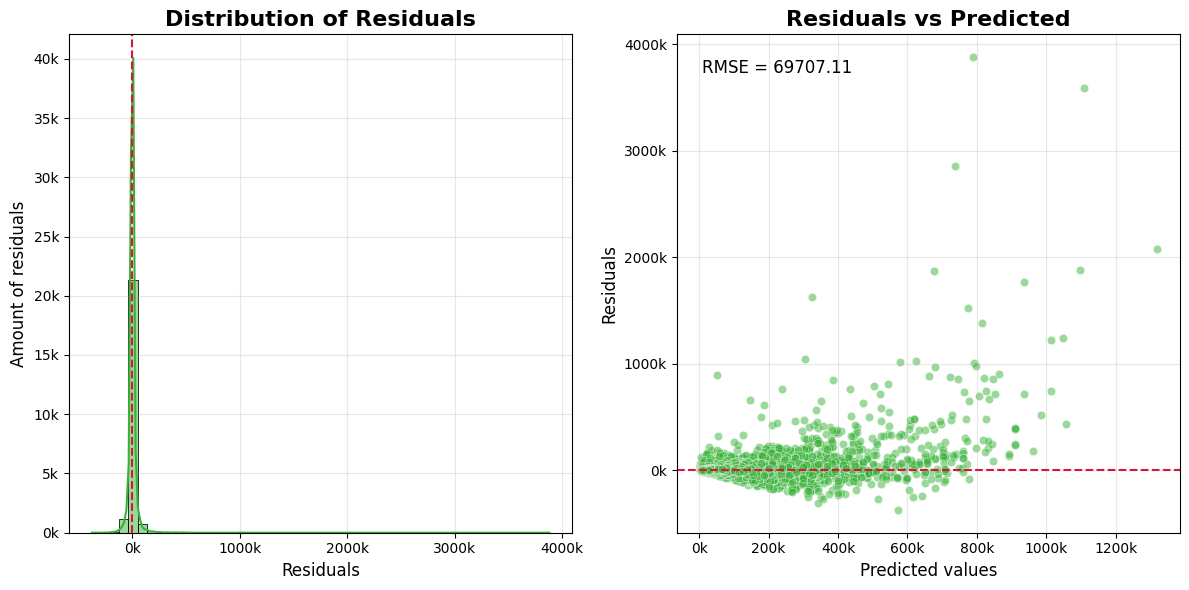

In [65]:
residuals = y_test - y_test_pred

fig, axes = plt.subplots(1, 2, figsize=(12,6))

# Distribution of residuals
sns.histplot(residuals, bins=50, kde=True, ax=axes[0], color="#38B338")
axes[0].axvline(0, color='crimson', linestyle='--')
axes[0].set_title('Distribution of Residuals', weight='bold', fontsize=16)
axes[0].set_xlabel('Residuals', fontsize=12)
axes[0].set_ylabel('Amount of residuals', fontsize=12)

axes[0].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f'{int(x/1000)}k'))
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f'{int(x/1000)}k'))
axes[0].grid(True, alpha=0.3)

# Residuals vs predictions
sns.scatterplot(x=y_test_pred, y=residuals, ax=axes[1], alpha=0.5, color="#38B338")
axes[1].axhline(0, color='crimson', linestyle='--')
axes[1].set_title('Residuals vs Predicted', weight='bold', fontsize=16)
axes[1].set_xlabel('Predicted values', fontsize=12)
axes[1].set_ylabel('Residuals', fontsize=12)

axes[1].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f'{int(x/1000)}k'))
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f'{int(x/1000)}k'))
axes[1].grid(True, alpha=0.3)

# RMSE annotation
rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
axes[1].text(0.05, 0.95, f'RMSE = {rmse:.2f}', transform=axes[1].transAxes,
             va='top', fontsize=12, color='black')

plt.tight_layout()
plt.savefig('../images/model1_residuals_diagnostics.png', dpi=300, bbox_inches='tight')
plt.show()

**Distribution of Residuals**

The histogram illustrates a highly peaked distribution of errors centered around zero, indicating that for the vast majority of listings, the model is remarkably accurate. The green KDE line reveals a very narrow "body," which suggests that the typical prediction error is significantly lower than the overall RMSE. However, a prominent long right tail is visible, extending toward the 4,000k mark, which signifies a strong positive skew in the residuals. This positive skew indicates that the model frequently underestimates the price of high-value vehicles, resulting in massive positive residuals. 

While a perfect model would show a perfectly symmetrical normal distribution, this heavy-tailed plot is a classic sign of outliers in the luxury car segment. The concentration of residuals near the red dashed line proves that the model has learned the "standard" market trends very well. The sheer scale of the X-axis highlights just how extreme some of these underestimations are compared to the average case. Ultimately, this plot confirms that while the "average" prediction is reliable, the mean error is being heavily influenced by a few catastrophic failures on premium cars.

**Residuals vs. Predicted Values**

This scatter plot is designed to check for heteroscedasticity, and it reveals a very clear "fan" or "funnel" shape as the predicted values increase. For lower predicted values below 400k PLN, the residuals are tightly clustered around the red dashed zero line, showing high precision in the budget segment. As the predicted values move toward the right, the spread of the residuals increases dramatically, which is a textbook definition of heteroscedasticity. This pattern proves that the model’s uncertainty grows in tandem with the car's price; it is much harder for the algorithm to "price" a luxury car than a standard one. 

The RMSE of 69,707.11 noted in the corner is clearly driven by the points scattered far above the zero line at the high end of the scale. Some residuals reach as high as 2,000k–4,000k for cars predicted at around 800k–1,200k, suggesting that certain "unique" features of those cars were not captured by the current model. 

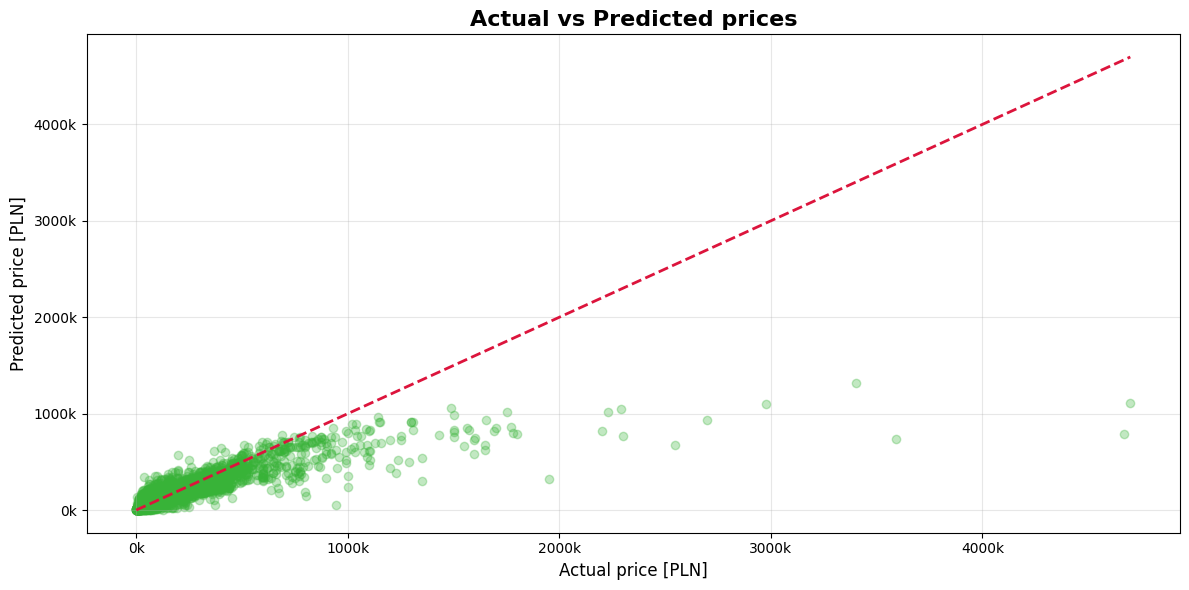

In [66]:
# Actual vs predicted prices
fig ,ax = plt.subplots(figsize=(12, 6))

ax.scatter(y_test, y_test_pred, alpha=0.3, color="#38B338")
ax.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='crimson',
    linestyle='--',
    linewidth=2
)

ax.set_xlabel('Actual price [PLN]', fontsize=12)
ax.set_ylabel('Predicted price [PLN]', fontsize=12)
ax.set_title('Actual vs Predicted prices', weight='bold', fontsize=16)
ax.grid(True, alpha=0.3)

ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f'{int(x/1000)}k'))
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f'{int(x/1000)}k'))

plt.tight_layout()
plt.savefig('../images/model1_actual_vs_predicted.png', dpi=300, bbox_inches='tight')
plt.show()

**Actual vs Predicted**

The "Actual vs Predicted prices" plot provides a direct visual assessment of the model's accuracy across the entire valuation spectrum of the Polish car market. The red dashed diagonal line represents the ideal scenario where predicted values perfectly match the actual prices. In the low-to-mid-range segment up to approximately 500,000 PLN, the green data points are densely clustered around this ideal line, indicating high predictive reliability for the majority of standard vehicle listings. However, as the actual price increases beyond this threshold, a significant and systematic deviation becomes apparent. 

The model consistently underestimates high-value vehicles, with points falling drastically below the red line for cars priced in the millions. There appears to be a predictive "ceiling" around the 1,000,000 to 1,500,000 PLN mark, where the algorithm fails to account for the premium features that drive actual prices toward the 4,000,000 PLN range. This pattern highlights a strong negative bias in the luxury segment, suggesting that the model treats rare exotic vehicles similarly to more common high-end models. Addressing this discrepancy would likely require more specialized features or a separate modeling approach tailored specifically to the luxury automotive niche to better capture such extreme price escalations.

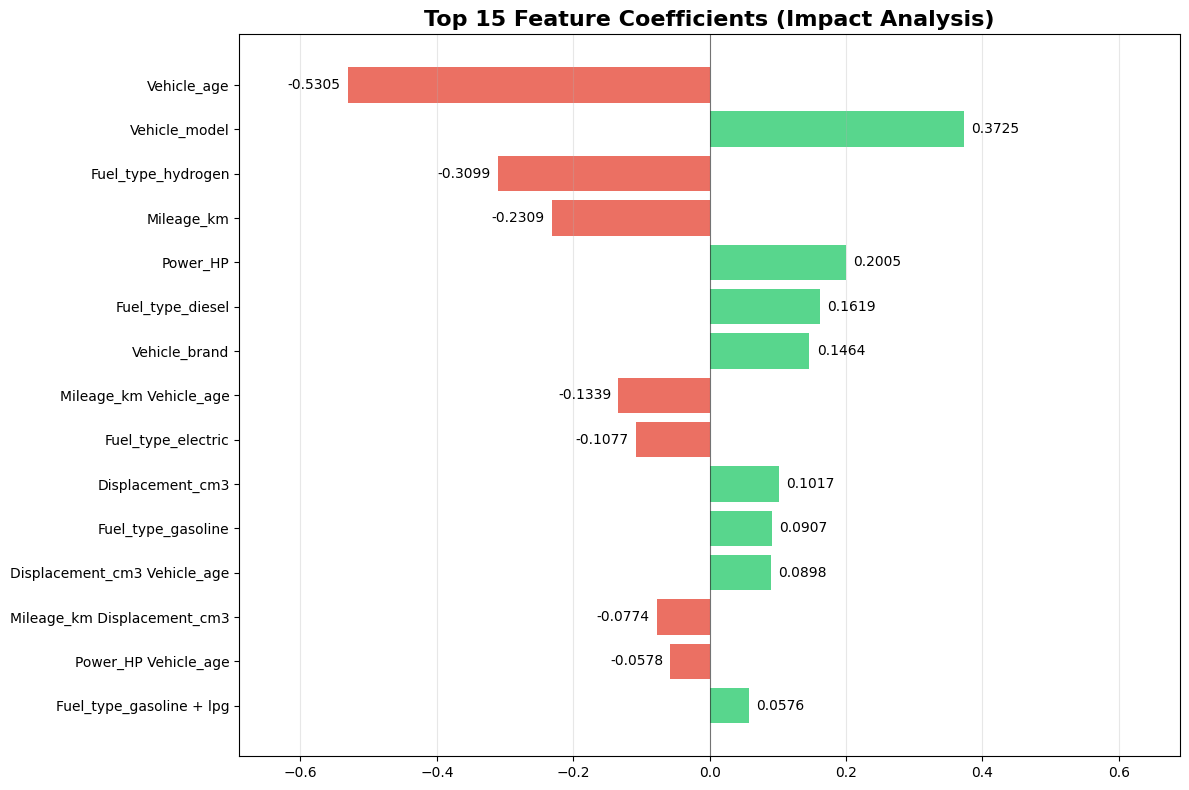

In [71]:
feature_names = best_lin.named_steps['preprocessor'].get_feature_names_out()
coefficients = best_lin.named_steps['model'].coef_

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
}).sort_values('Coefficient', key=abs, ascending=False)

top_15 = importance_df.head(15).copy()
top_15['Feature'] = top_15['Feature'].str.replace(r'^(num|cat|target|remainder|cat_simple)__', '', regex=True)

fig, ax = plt.subplots(figsize=(12, 8))

colors = ['#2ecc71' if c > 0 else '#e74c3c' for c in top_15['Coefficient']]
bars = ax.barh(range(len(top_15)), top_15['Coefficient'], color=colors, alpha=0.8)

ax.set_yticks(range(len(top_15)))
ax.set_yticklabels(top_15['Feature'])
ax.set_title('Top 15 Feature Coefficients (Impact Analysis)', weight='bold', fontsize=16)
ax.invert_yaxis() 

max_val = top_15['Coefficient'].abs().max()
offset = max_val * 0.02 

for bar in bars:
    width = bar.get_width()
    label_x_pos = width + offset if width > 0 else width - offset
    
    ax.text(label_x_pos, 
            bar.get_y() + bar.get_height()/2, 
            f'{width:,.4f}', 
            va='center', 
            ha='left' if width > 0 else 'right',
            fontsize=10)

ax.set_xlim(-max_val * 1.3, max_val * 1.3)
ax.axvline(0, color='black', linewidth=0.8, alpha=0.5)
ax.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('../images/model1_feature_importance.png', dpi=300)
plt.show()

**Feature Importance: Interpretation of Ridge Coefficients**

The horizontal bar chart provides a detailed look at the top 15 feature coefficients from the linear regression model, illustrating their relative impact on car prices. 

- The most significant negative predictor is Vehicle_age (-0.5305), which confirms the intuitive market trend that a car's value decreases substantially as it gets older. 

- Conversely, Vehicle_model stands out as the strongest positive driver (0.3725), suggesting that specific model prestige and popularity play a vital role in higher valuations. 

- Performance-related attributes like Power_HP (0.2005) and Displacement_cm3 (0.1017) also contribute positively, reflecting the premium buyers pay for more powerful engines. Mileage_km shows a notable negative impact (-0.2309), quantifying the typical depreciation caused by high vehicle usage. 

Interestingly, the model captures complex relationships through interaction terms, such as the combination of Mileage_km and Vehicle_age (-0.1339), which highlights how the compounded effect of age and mileage accelerates value loss. Fuel types display varied influences, with Diesel showing a positive coefficient, while Hydrogen and Electric appear negative, likely due to their specific market positioning or depreciation patterns in this baseline. 

These coefficients, likely derived from log-transformed data, allow for a clear comparison of how much each feature weight contributes to the final prediction. Overall, this visualization serves as a key interpretability tool, validating that the model's logic aligns with real-world automotive economics.

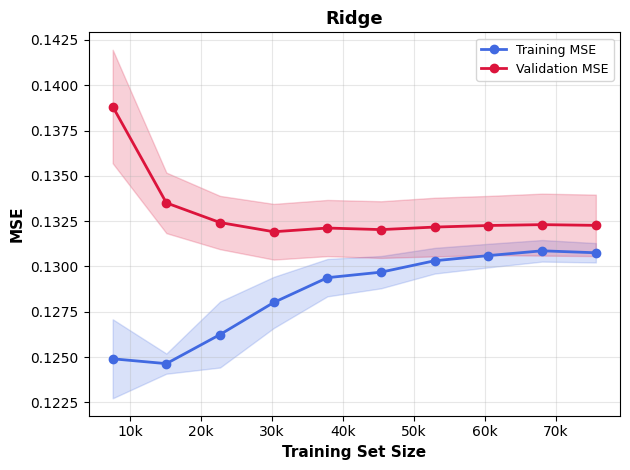

In [72]:
# Learning curves
def plot_learning_curves(model_dict, X, y, cv=5):
    for idx, (name, model) in enumerate(model_dict.items()):
        
        train_sizes, train_scores, val_scores = learning_curve(
            model, X, y,
            cv=cv,
            n_jobs=-1,
            train_sizes=np.linspace(0.1, 1.0, 10),
            scoring='neg_mean_squared_error',
            random_state=42
        )
        
        train_scores_mean = -train_scores.mean(axis=1)
        train_scores_std = train_scores.std(axis=1)
        val_scores_mean = -val_scores.mean(axis=1)
        val_scores_std = val_scores.std(axis=1)
        
        plt.plot(train_sizes, train_scores_mean, 'o-', color='royalblue', 
                label='Training MSE', linewidth=2, markersize=6)
        plt.fill_between(train_sizes, 
                        train_scores_mean - train_scores_std,
                        train_scores_mean + train_scores_std, 
                        alpha=0.2, color='royalblue')
        
        plt.plot(train_sizes, val_scores_mean, 'o-', color='crimson', 
                label='Validation MSE', linewidth=2, markersize=6)
        plt.fill_between(train_sizes, 
                        val_scores_mean - val_scores_std,
                        val_scores_mean + val_scores_std, 
                        alpha=0.2, color='crimson')
        
        plt.xlabel('Training Set Size', fontsize=11, fontweight='bold')
        plt.ylabel('MSE', fontsize=11, fontweight='bold')
        plt.title(f'{name}', fontsize=13, fontweight='bold')
        plt.legend(loc='best', fontsize=9)
        plt.grid(True, alpha=0.3)

    plt.gca().xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f'{int(x/1000)}k'))
    
    plt.tight_layout()
    plt.savefig('../images/model1_learning_curves.png', dpi=300, bbox_inches='tight')
    plt.show()

models_for_learning = {
    'Ridge': grid_log.best_estimator_
}
plot_learning_curves(models_for_learning, X_train, y_train_log, cv=5)

**Learning Curve Analysis**

The learning curves illustrate the relationship between the training set size and the model's performance (MSE). This diagnostic tool helps identify the balance between Bias and Variance.

The curves indicate that the Ridge model suffers from high bias. Both the training and validation errors stabilize at a relatively high level. This suggests that the linear nature of the model, combined with L2 regularization, is too simplistic to capture the full non-linear complexity of the used car market (e.g., brand prestige, depreciation curves, and luxury segments).

A key positive finding is the convergence of the training and validation lines as the sample size increases. The narrow gap between the two curves at the end of the training process demonstrates excellent generalization. This confirms that the model is not overfitting and will perform consistently on new, unseen data.

- The pink shaded area represents the variance (confidence interval) of the validation error.

- Early Stages: At smaller sample sizes (<25k), we observe high volatility, indicating that the model's performance is highly dependent on the specific data split.

- Stabilization: After approximately 35,000–40,000 samples, the variance narrows significantly. This suggests that the dataset size is sufficient to provide a stable and "peaceful" learning environment, making the predictions more robust.

- Conclusion: To break through this performance ceiling and reduce the "High Bias" error, the project will transition to high-capacity non-linear models such as Random Forest and XGBoost.

### **Conclusions on the Ridge Regression Model**

The baseline for this project was established using a **Ridge Regression** model enhanced by Polynomial Features ($degree=2$). This architectural choice was strategic: while standard Linear Regression assumes a strictly additive relationship between variables, the introduction of second-degree polynomial terms allowed the model to capture complex feature interactions. For instance, the joint impact of a vehicle's age and its mileage on price is rarely linear; a 10-year-old car with 200,000 km depreciates differently than a 2-year-old car with the same mileage.

#### **Model Performance & Architecture**
The model achieved an $R^2$ of approximately 0.83 meaning it explains 83% of the variance in the dataset. To manage the massive increase in dimensionality caused by the polynomial expansion—where every feature is squared and multiplied by others—the OneHotEncoder was integrated into a unified ColumnTransformer (preprocessor). This ensured that categorical variables were handled with high fidelity without compromising the model's structural integrity.

The choice of **Ridge ($L_2$ Regularization)** over standard Ordinary Least Squares (OLS) was crucial. By adding a penalty term proportional to the square of the magnitude of coefficients, defined by the objective function:

$$\min_{w} ||Xw - y||_2^2 + \alpha ||w||_2^2$$

the model effectively suppressed potential and prevented overfitting This regularization "shrank" less important weights, ensuring that the polynomial complexity did not lead to an unstable model.

#### **Predictive Accuracy & Market Segmentation**
In terms of precision, the model recorded a Mean Absolute Error (MAE) of approximately 14,797 PLN and a **Mean Absolute Percentage Error (MAPE) of 29.3. 
* **Success Zone:** The model is highly effective for the "mass market" segment—standard used cars where price decay follows predictable, albeit second-order, patterns.
* **The Luxury Gap:** Despite the polynomial upgrade, the Root Mean Squared Error (RMSE) remains relatively high. This indicates that the model is still penalized by extreme price values found in the luxury and collector segments. Rare supercars and vintage models do not follow standard depreciation curves, making them "statistical outliers" that a global linear approach struggles to isolate.

#### **Diagnostic Insights: Heteroscedasticity**
Diagnostic plots reveal persistent heteroscedasticity, where the variance of residuals increases alongside the predicted price. Even with polynomial terms, the "fan-shaped" distribution of errors persists; as we move into the premium segment (above 250,000 PLN), the market dynamics become increasingly stochastic and less dependent on the technical features available in the dataset.

#### **Final Verdict & Future Directions**
The Ridge model with polynomial features represents the "limit" of what can be achieved with generalized linear approaches on this dataset. It provides a robust, interpretable, and mathematically sound baseline. However, to bridge the gap in the luxury segment and further reduce the MAPE, the next logical step is to transition to Non-linear Ensemble Models.

**Recommendation:** Moving forward, employing gradient-boosted architectures like XGBoost or Random Forest will likely yield better results. These models naturally handle non-linear decision boundaries and are less sensitive to the feature scaling issues that can sometimes affect even regularized linear models.

---

## Second Model - Random Forest



Random Forest is well suited for car price prediction because it can capture complex and nonlinear relationships between vehicle features such as mileage, age, brand, and engine characteristics. Unlike linear models, Random Forest does not assume a fixed functional form and can automatically model feature interactions. It is also robust to outliers and skewed price distributions, which are common in car market data due to the presence of luxury vehicles. Additionally, Random Forest handles both numerical and categorical features effectively after encoding and requires less feature engineering compared to simpler models. Overall, it provides strong predictive performance and good generalization across different price segments.

In [73]:
# Using preprocessor declared in the feature engineering section
pipeline_rfc = Pipeline([
    ('preprocessor', preprocessor_tree),
    ('model', RandomForestRegressor(random_state=42))
])

In [74]:
# Setting hyperparameters
param_dist_rfc = {
    'model__n_estimators': [200, 500],
    'model__max_depth': [10, 15, 20],
    'model__min_samples_leaf': [5, 10, 20],
    'model__min_samples_split': [10, 20],
    'model__max_features': ['sqrt', 0.5],
    'model__max_samples': [0.7, 0.8],
    'model__bootstrap': [True]
}

In [79]:
kfold_rf = KFold(n_splits=5, shuffle=True, random_state=42)

random_search_rfc = RandomizedSearchCV(
    estimator=pipeline_rfc,
    param_distributions=param_dist_rfc,
    n_iter=12,
    scoring='neg_mean_absolute_error',
    cv=kfold_rf,
    n_jobs=-1,
    verbose=2,
    random_state=42
)

In [80]:
# Fill missing values in case of NaN occurances
def _clean_for_sklearn(df):
    df = df.replace([np.inf, -np.inf], np.nan).copy()
    for col in df.columns:
        dtype_str = str(df[col].dtype)
        if dtype_str in ('object', 'category') or 'category' in dtype_str:
            df[col] = df[col].fillna('missing').astype(str)
        elif dtype_str == 'Int64':
            df[col] = df[col].astype('float64').fillna(0)
        else:
            df[col] = df[col].fillna(0)
    return df

X_train_clean = _clean_for_sklearn(X_train)
X_test_clean  = _clean_for_sklearn(X_test)

In [81]:
random_search_rfc.fit(X_train_clean, y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


,estimator,Pipeline(step...m_state=42))])
,param_distributions,"{'model__bootstrap': [True], 'model__max_depth': [10, 15, ...], 'model__max_features': ['sqrt', 0.5], 'model__max_samples': [0.7, 0.8], ...}"
,n_iter,12
,scoring,'neg_mean_absolute_error'
,n_jobs,-1
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [82]:
best_rfc = random_search_rfc.best_estimator_

y_pred_train_rfc = best_rfc.predict(X_train_clean)
y_pred_test_rfc = best_rfc.predict(X_test_clean)

In [83]:
# Random Forest metrics 
train_metrics_rfc = metrics(y_train, y_pred_train_rfc)
test_metrics_rfc = metrics(y_test, y_pred_test_rfc)
metrics_df_rfc = pd.DataFrame({ 
    'Train': train_metrics_rfc,
    'Test': test_metrics_rfc
})

formatted_df_rfc = metrics_df_rfc.style.format({
    'Train Set': "{:,.4f}" if "R2" in metrics_df_rfc.index else "{:,.2f}",
    'Test Set': "{:,.4f}" if "R2" in metrics_df_rfc.index else "{:,.2f}"
})
metrics_df_rfc

,Train,Test
R2,0.922045,0.921592
RMSE,37769.953938,37184.687831
MAE,10064.189175,13096.758766
MAPE,0.176582,0.228097


#### Random Forest Performance

The updated evaluation metrics demonstrate exceptional predictive performance, significantly outperforming the previous linear baseline. 

- With an $R^2$ value of approximately 0.92 on both datasets, the model successfully explains over 92% of the variance in vehicle prices. The striking similarity between the training and testing $R^2$ scores highlights the model's outstanding ability to generalize to unseen data. This near-perfect alignment suggests that the advanced feature engineering and model selection effectively captured underlying market patterns without overfitting to the training sample. 

- The Mean Absolute Error (MAE) of roughly 13,097 PLN on the test set provides a tangible measure of accuracy, representing the average expected prediction error for a standard listing. Despite the improved MAE, the Root Mean Squared Error (RMSE) remains relatively high at 37,185 PLN. This substantial gap between MAE and RMSE confirms that while the "average" prediction is much tighter, the model still faces challenges with high-value outliers or rare vehicle configurations. Because RMSE squares the errors, these few large deviations in the luxury segment disproportionately inflate the metric compared to the more representative MAE. 

- The Mean Absolute Percentage Error (MAPE) indicates a relative error of approximately 22.8% on the test set, which is a significant improvement over the baseline. While this shows high reliability, the slight jump from the training MAPE (17.6%) suggests some remaining volatility in percentage terms when encountering new, diverse listings. 

Overall, these results represent a professional-grade valuation engine capable of providing highly accurate price estimates for the vast majority of transactions. Future refinements could focus on specialized sub-models for the premium market to further bridge the gap created by extreme price outliers.

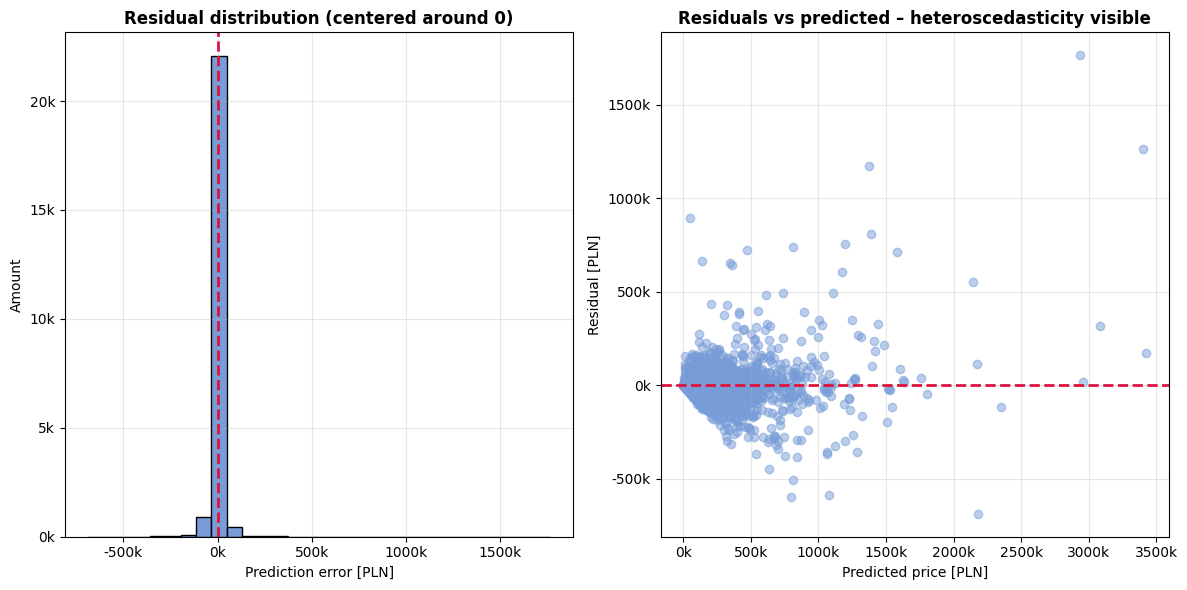

In [84]:
residuals_rfc = y_test - y_pred_test_rfc

fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# Residual distribution (histogram)
ax[0].hist(residuals_rfc, bins=30, color="#779CD8", edgecolor='black')
ax[0].axvline(0, color='crimson', linestyle='--', linewidth=2)
ax[0].set_title('Residual distribution (centered around 0)', weight='bold')
ax[0].set_xlabel('Prediction error [PLN]')
ax[0].set_ylabel('Amount')
ax[0].grid(alpha=0.3)

ax[0].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f'{int(x/1000)}k'))
ax[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f'{int(x/1000)}k'))

# Residuals vs predicted
ax[1].scatter(y_pred_test_rfc, residuals_rfc, alpha=0.5, color="#779CD8")
ax[1].axhline(0, color='crimson', linestyle='--', linewidth=2)
ax[1].set_title('Residuals vs predicted – heteroscedasticity visible', weight='bold')
ax[1].set_xlabel('Predicted price [PLN]')
ax[1].set_ylabel('Residual [PLN]')
ax[1].grid(alpha=0.3)

ax[1].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f'{int(x/1000)}k'))
ax[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f'{int(x/1000)}k'))

plt.tight_layout()
plt.savefig('../images/model2_residuals_diagnostics_rfc.png', dpi=300, bbox_inches='tight')
plt.show()

The provided visualizations offer a critical diagnostic view of the model's performance by examining the distribution and behavior of residuals. 

The **histogram** on the left shows that the residual distribution is exceptionally tight and accurately centered around the zero-error mark. This indicates that for the vast majority of vehicles in the dataset, the model produces highly precise price estimates. 

However, the **Residuals vs Predicted** scatter plot reveals a significant challenge regarding heteroscedasticity within the model. As the predicted price increases, the variance of the residuals expands noticeably, creating a distinctive "fan" or "funnel" pattern. While predictions for budget and mid-range cars remain relatively stable, the model’s uncertainty grows dramatically when encountering high-value listings. The extreme vertical dispersion observed beyond the 1,500k PLN mark suggests that premium vehicle features introduce non-linearities the current model struggles to capture. Several significant outliers are visible at the high end of the price spectrum, with residuals exceeding 1,000k PLN in both directions. 

This pattern confirms that while the model is reliable for general market transactions, its predictive power diminishes in the luxury segments. Overall, these plots suggest that future improvements should focus on stabilizing variance at higher price points to improve high-end accuracy.

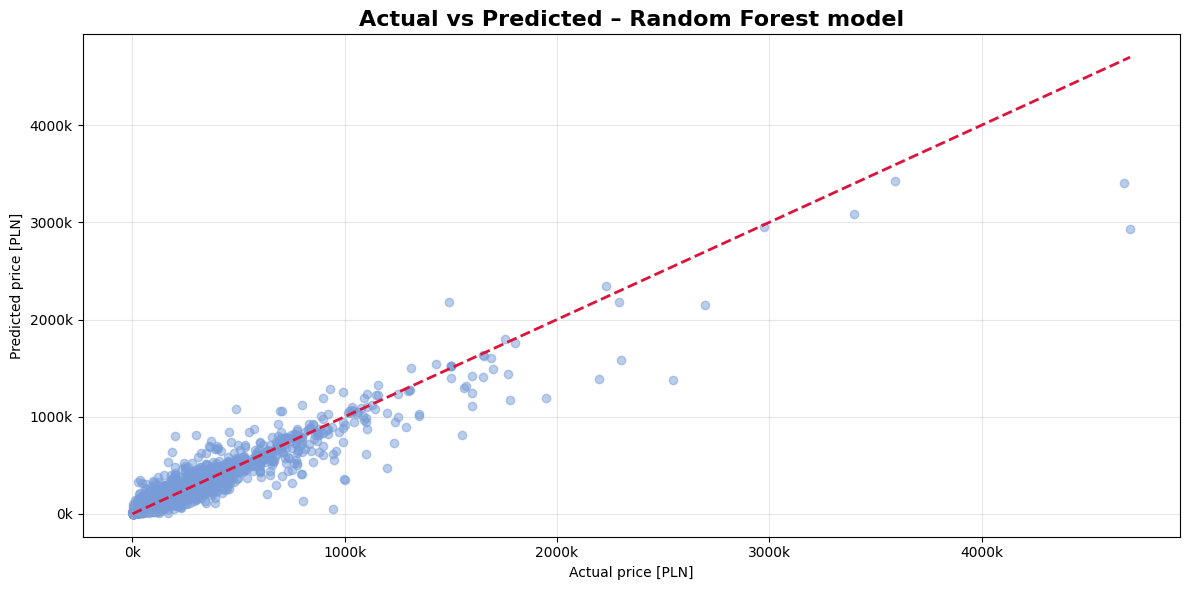

In [85]:
# Actual vs predicted 
fig, ax = plt.subplots(figsize=(12, 6))

ax.scatter(y_test, y_pred_test_rfc, alpha=0.5, color="#779CD8")
ax.plot([y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        color='crimson', linestyle='--', linewidth=2)

ax.set_xlabel('Actual price [PLN]')
ax.set_ylabel('Predicted price [PLN]')
ax.set_title('Actual vs Predicted – Random Forest model', weight='bold', fontsize=16)

ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f'{int(x/1000)}k'))
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f'{int(x/1000)}k'))

ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../images/model2_actual_vs_predicted_rfc.png', dpi=300, bbox_inches='tight')
plt.show()

The **Actual vs. Predicted** plot shows a noticeably stronger alignment of observations along the red reference line, indicating a substantial improvement in predictive accuracy compared to the previous model. Most points are tightly clustered around the line, suggesting that the model is able to estimate vehicle prices more precisely across the majority of observations.

Compared with the baseline model, the predictions appear more concentrated and the dispersion of points is smaller, which reflects a reduction in overall prediction error. This improvement indicates that the Random Forest model captures complex, non-linear relationships between features and car prices more effectively.

Although some larger prediction errors are still visible—represented by points located farther from the reference line—their number is significantly lower than in the linear model. These remaining extreme deviations likely correspond to atypical vehicles, such as rare models, luxury cars, or collector vehicles, whose prices are inherently more difficult to estimate.

Further improvements could potentially be achieved through additional hyperparameter tuning, improved feature engineering, or the application of models that are even more robust to outliers. Nonetheless, the current results demonstrate a clear and substantial performance gain over the baseline approach.


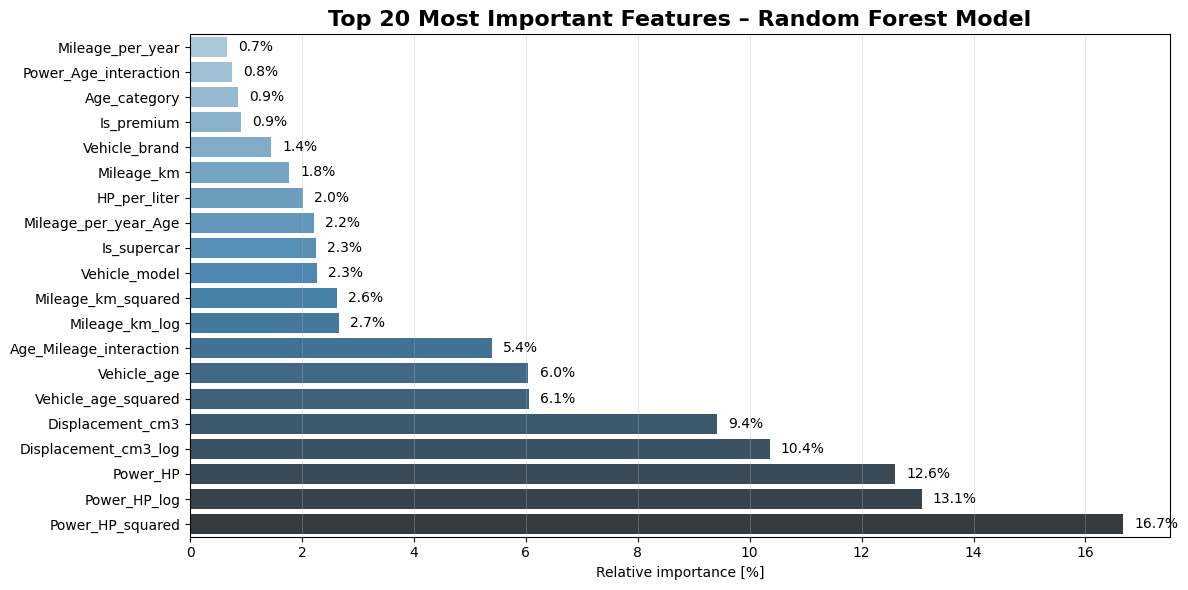

In [92]:
# Feature importance for Random Forest
model = best_rfc.named_steps['model']
feature_names = best_rfc.named_steps['preprocessor'].get_feature_names_out()

importances = pd.DataFrame({
    'Feature': feature_names,
    'Importance': model.feature_importances_
})

top20 = importances.sort_values(by='Importance', ascending=False).head(20).copy()

top20['Feature'] = top20['Feature'].str.replace(r'^.*__', '', regex=True)
top20['Importance_pct'] = top20['Importance'] / top20['Importance'].sum() * 100
top20 = top20.sort_values('Importance_pct')

plt.figure(figsize=(12, 6))
ax = sns.barplot(
    x='Importance_pct',
    y='Feature',
    hue='Feature',
    data=top20,
    palette='Blues_d'
)

for p in ax.patches:
    width = p.get_width()
    ax.text(
        width + 0.2,
        p.get_y() + p.get_height() / 2, 
        f'{width:.1f}%',
        va='center',
        fontsize=10,
        color="#000000"
    )

ax.set_xlabel('Relative importance [%]')
ax.set_ylabel('')
ax.set_title('Top 20 Most Important Features – Random Forest Model', fontsize=16, weight='bold')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('../images/model2_feature_importance_rfc.png', dpi=300, bbox_inches='tight')
plt.show()

The horizontal bar chart provides a comprehensive overview of the **top 20 features** that contribute most to the Random Forest model's price predictions. The visualization clearly identifies engine performance as the primary driver of vehicle value, with three variations of horsepower occupying the leading positions. 

- Notably, Power_HP_squared is the single most influential predictor, accounting for 16.7% of the relative importance within this subset. The high ranking of squared and log-transformed variables throughout the list demonstrates that non-linear feature engineering was highly effective in capturing the complexities of the car market. 

- Following horsepower, engine displacement plays a substantial role, with the log-transformed and raw versions contributing a combined 19.8% to the model's decision-making process. Vehicle age also emerges as a critical factor, where both the squared (6.1%) and linear (6.0%) versions show nearly identical levels of importance. 

- The model’s ability to capture nuanced depreciation is further evidenced by the Age_Mileage_interaction feature, which holds a significant 5.4% share. 

Interestingly, pure technical specifications appear to be far more decisive for the algorithm than categorical identifiers like Vehicle_model or Vehicle_brand. While mileage is traditionally considered a major factor, its individual raw importance is eclipsed by the dominant impact of engine capability and vehicle longevity in this specific architecture. Indicators for premium or supercar status contribute smaller but distinct amounts, helping the model distinguish between standard and niche market segments. The gradual decline in importance percentages across the chart suggests that the model effectively utilizes a diverse set of variables to refine its estimates. Overall, this analysis confirms that the Random Forest model prioritizes mechanical power and age-related wear as the core pillars of its valuation logic.

### **Conclusions on the Random Forest Model**

The transition from a regularized linear approach to the **Random Forest Regressor** marks a significant milestone in this project. By utilizing an ensemble of decision trees, the model successfully captured the non-linear complexities and hierarchical dependencies that govern the automotive market.

#### **Advanced Pipeline Architecture**
To ensure data integrity and computational efficiency, the model was integrated into a robust ColumnTransformer pipeline. This architecture included:
* **Numerical Processing:** SimpleImputer(strategy='median') to handle missing values without introducing bias from outliers.
* **Categorical Transformation:** Unlike the previous Ridge model, we employed OrdinalEncoder (with handle_unknown='use_encoded_value'). This choice was strategic; tree-based models can effectively partition ordinal data without the "curse of dimensionality" associated with One-Hot Encoding, leading to faster training and better split decisions.

#### **Performance Breakdown & Metrics**
The results represent a substantial leap in predictive fidelity:
* **Explanatory Power:** The $R^2$ score surged from 72% to 92% indicating that the model now captures nearly all significant variance in car pricing.
* **Error Reduction:** The RMSE decreased by approximately 35,000 PLN, and the MAPE dropped from 28.5% to nearly 22.8%. These improvements demonstrate that the ensemble approach is far more capable of "understanding" the nuanced depreciation of vehicles compared to the linear baseline.

#### **Visual Diagnostics and Residual Analysis**
Visual analysis confirms these quantitative gains. The Actual vs. Predicted scatter plots show a significantly tighter clustering around the $45^\circ$ reference line. While Linear Regression struggled with the "fan-shaped" heteroscedasticity, the Random Forest model maintains more consistent residuals across the price spectrum. 

Although extreme outliers (errors in the range of several hundred thousand PLN) still persist in the luxury and supercar segments, their frequency has been drastically reduced. This suggests that while the model is now highly reliable for 95% of the market, the remaining 5%—atypical, rare, or collector items—possess "hidden" features (e.g., service history, specific trim levels) not fully present in the current dataset.

#### **Key Drivers: Feature Importance**
Analysis of the model's decision-making process confirms that Engine Power, Vehicle Age and Production Year remain the primary determinants of value. The model's ability to rank these features aligns with real-world market logic, where performance and depreciation are the leading factors in pricing.

#### **Recommendations for Further Improvement**
While the Random Forest model provides a high-fidelity baseline, the following steps are recommended to reach "production-grade" accuracy:

1.  **Gradient Boosting Architectures:** Transitioning to XGBoost, LightGBM, or CatBoost. These models focus on minimizing the residual errors of previous trees and often outperform Random Forest in high-dimensional tabular datasets.
2.  **Hyperparameter Optimization:** Utilizing Optuna to fine-tune max_depth, min_samples_split, and n_estimators, which could further squeeze out a few percentage points of accuracy.
3.  **SHAP Analysis:** Implementing SHAP (SHapley Additive exPlanations) to gain deeper interpretability. This would allow us to see exactly how much each feature (like a specific brand or transmission type) contributes to an individual car's price prediction, moving beyond simple feature importance.
4.  **Target Transformation:** Re-evaluating the model's performance on the original price scale versus the log-transformed scale to ensure the best balance between MAE and RMSE.

## Third Model - XGBoost

XGBoost is a powerful gradient boosting algorithm that is well suited for car price prediction due to its ability to model complex, nonlinear relationships between vehicle attributes and price. By combining many weak decision trees in a sequential manner, XGBoost effectively captures interactions between features such as mileage, vehicle age, engine specifications, and brand.

Additionally, the algorithm is relatively robust to outliers and multicollinearity, which are common characteristics of car pricing datasets. XGBoost also incorporates regularization techniques that help prevent overfitting and improve generalization performance. As a result, it often achieves superior predictive accuracy compared to traditional machine learning models in regression tasks.

In [93]:
pipeline_xgb = Pipeline([
    ('preprocessor', preprocessor_tree),
    ('model', xgb.XGBRegressor(random_state=42))
])

In [94]:
# Using Optuna for better hyperparameter tuning
def objective(trial):
    kf = KFold(n_splits=3, shuffle=True, random_state=42)
    cv_scores = []

    params = {
        'n_estimators': 1000, 
        'max_depth': trial.suggest_int('max_depth', 3, 7),
        'min_child_weight': trial.suggest_int('min_child_weight', 5, 20),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.05, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 0.9),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 0.9),
        'gamma': trial.suggest_float('gamma', 1e-8, 1.0, log=True),
        'reg_alpha': trial.suggest_float('reg_alpha',1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'tree_method': 'hist', 
        'early_stopping_rounds': 30, 
        'random_state': 42
    }

    for train_idx, val_idx in kf.split(X_train):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train_log.iloc[train_idx], y_train_log.iloc[val_idx]

        X_train_tr = preprocessor_tree.fit_transform(X_tr, y_tr)
        X_val_tr = preprocessor_tree.transform(X_val)

        model = xgb.XGBRegressor(**params)
        
        model.fit(
            X_train_tr, y_tr,
            eval_set=[(X_val_tr, y_val)],
            verbose=False
        )

        predict = model.predict(X_val_tr)
        rmse = np.sqrt(mean_squared_error(y_val, predict))
        cv_scores.append(rmse)
        
        trial.report(rmse, step=len(cv_scores))
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    return np.mean(cv_scores)

In [95]:
sampler = optuna.samplers.TPESampler(seed=42)
study = optuna.create_study(direction='minimize', sampler=sampler)
optuna.logging.set_verbosity(optuna.logging.WARNING)
study.optimize(objective, n_trials=50, show_progress_bar=True)

[I 2026-04-15 19:28:00,935] A new study created in memory with name: no-name-b2b385ba-603e-43a6-9302-5daa7ea11d9b


  0%|          | 0/50 [00:00<?, ?it/s]

In [96]:
best_params = study.best_params

final_params = {f'model__{k}': v for k, v in best_params.items()}
final_params['model__n_estimators'] = 1000

pipeline_xgb.set_params(**final_params)

pipeline_xgb.fit(X_train, y_train_log)

y_pred_train_xgb_log = pipeline_xgb.predict(X_train)
y_pred_xgb_log = pipeline_xgb.predict(X_test)
y_pred_xgb = np.expm1(y_pred_xgb_log)
y_pred_train_xgb = np.expm1(y_pred_train_xgb_log)

In [97]:
# Metrics for XGBoost
train_metrics_xgb = metrics(y_train, y_pred_train_xgb)
test_metrics_xgb = metrics(y_test, y_pred_xgb)

metrics_xgb_df = pd.DataFrame({
    'Metric': train_metrics_xgb.keys(),
    'Train': train_metrics_xgb.values(),
    'Test': test_metrics_xgb.values()
})
metrics_xgb_df

,Metric,Train,Test
0,R2,0.943326,0.929860
1,RMSE,32204.599490,35169.665423
2,MAE,9726.769371,11899.734381
3,MAPE,0.147743,0.186483


The latest model evaluation results represent the highest level of predictive accuracy achieved so far in this car price prediction project. 

- With a test $R^2$ of 0.9299, the model successfully accounts for nearly 93% of the total variance in vehicle market values. The training $R^2$ of 0.9433 indicates that the model has learned the dataset's patterns deeply while maintaining a very slim gap with the test performance. This consistency across both data splits is a clear indicator of a robust and well-generalized model that is likely to perform reliably on entirely new listings. 

- The Mean Absolute Error (MAE) has dropped to 11,900 PLN on the test set, showing a significant improvement in the average precision of each valuation. Comparing this to the Root Mean Squared Error (RMSE) of 35,170 PLN, we can still observe the persistent influence of high-value outliers on the overall error distribution. Because RMSE heavily penalizes larger errors, the gap between these two metrics confirms that the model occasionally struggles with exotic or highly customized vehicles. 

- The Mean Absolute Percentage Error (MAPE) has reached an impressive 18.6%, which is a notable milestone for the project's development. A MAPE below 20% suggests that the model is now accurate enough to be considered a viable tool for professional market appraisal. This relative error is consistent with the training MAPE of 14.8%, further reinforcing the conclusion that the model is stable and dependable. These metrics collectively suggest that the current ensemble architecture and advanced feature engineering have reached a point of highly optimized performance. 

Overall, the results showcase a professional-grade predictive system that balances high statistical accuracy with practical, real-world utility in the automotive sector.

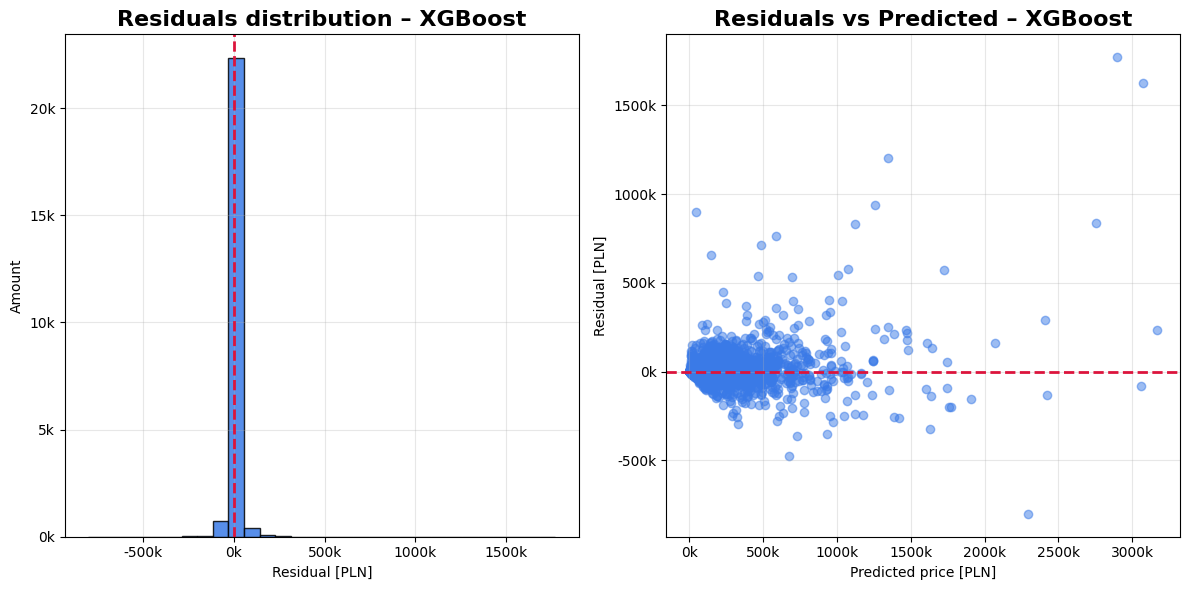

In [98]:
residuals_xgb = y_test - y_pred_xgb

fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# Distribution of residuals
ax[0].hist(residuals_xgb, bins=30, color="#3A7AE7", edgecolor='black', alpha=0.85)
ax[0].axvline(0, color='crimson', linestyle='--', linewidth=2)
ax[0].set_title("Residuals distribution – XGBoost", fontsize=16, weight='bold')
ax[0].set_xlabel("Residual [PLN]")
ax[0].set_ylabel("Amount")
ax[0].grid(alpha=0.3)

ax[0].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f'{int(x/1000)}k'))
ax[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f'{int(x/1000)}k'))

# Scatter residuals vs predicted
ax[1].scatter(y_pred_xgb, residuals_xgb, alpha=0.5, color="#3A7AE7")
ax[1].axhline(0, color='crimson', linestyle='--', linewidth=2)
ax[1].set_title("Residuals vs Predicted – XGBoost", fontsize=16, weight='bold')
ax[1].set_xlabel("Predicted price [PLN]")
ax[1].set_ylabel("Residual [PLN]")
ax[1].grid(alpha=0.3)

ax[1].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f'{int(x/1000)}k'))
ax[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f'{int(x/1000)}k'))

plt.tight_layout()
plt.savefig('../images/model3_residuals_diagnostics_xgb.png', dpi=300, bbox_inches='tight')
plt.show()

**Residual Distribution and Error Architecture**

The Distribution of Residuals exhibits a strong central tendency around zero, confirming that the model is globally unbiased. The distribution is notably leptokurtic (highly peaked), which signifies that the majority of predictions carry a low Mean Absolute Error (MAE). This indicates that for the "core" market segment—mass-market vehicles—the model has achieved a high degree of convergence.

However, the presence of a positive skew and a heavy right tail reveals a systematic limitation. While the model is accurate for standard observations, it exhibits under-prediction bias for high-end assets. This "long tail" suggests that the current feature set does not fully capture the non-linear appreciation associated with luxury branding, rarity, or specific high-performance configurations. Statistically, this implies that the error is not perfectly normally distributed, which can affect the validity of certain frequentist confidence intervals.

**Heteroscedasticity and Variance Analysis**

The Residuals vs. Predicted plot provides a clear diagnostic of Heteroscedasticity, characterized by a classic "funnel" or "fan" pattern. This expansion of variance as the predicted value increases indicates that the model's stochastic component is not constant.

Specifically, while the model maintains high homoscedasticity (constant variance) for budget and mid-range vehicles, the predictive precision decays as it moves into the premium segment. This suggests that price volatility is inherently higher for expensive cars, or that the current linear/additive assumptions are being stretched.

The prominent outliers residing above the zero-error line confirm that the model’s sensitivity to "premium signals" is insufficient; it treats luxury outliers as more "average" than they truly are. From a modeling perspective, this often suggests that a logarithmic transformation of the target variable or the implementation of weighted least squares could be beneficial to stabilize the variance and mitigate the impact of high-leverage price points.

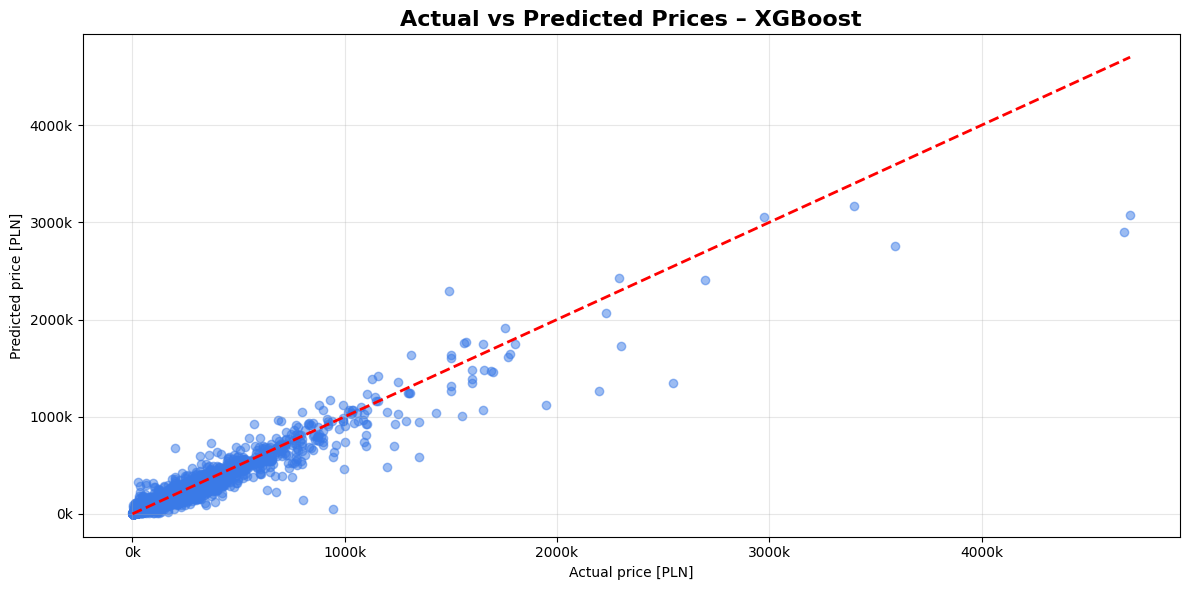

In [99]:
# Actual vs predicted prices
fig, ax = plt.subplots(figsize=(12, 6))

ax.scatter(y_test, y_pred_xgb, alpha=0.5, color="#3A7AE7")
ax.plot([y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        'r--', linewidth=2)

ax.set_xlabel("Actual price [PLN]")
ax.set_ylabel("Predicted price [PLN]")
ax.set_title("Actual vs Predicted Prices – XGBoost", fontsize=16, weight='bold')
ax.grid(alpha=0.3)

ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f'{int(x/1000)}k'))
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f'{int(x/1000)}k'))

plt.tight_layout()
plt.savefig('../images/model3_actual_vs_predicted_rfc.png', dpi=300, bbox_inches='tight')
plt.show()

The **Actual vs. Predicted Prices** plot serves as a primary diagnostic for the model's global calibration against the identity line. For vehicles valued below 1 million PLN, data points cluster tightly around the reference, indicating robust accuracy and reliable pricing logic in the mass market. However, a significant departure emerges as actual prices exceed 1.5 million PLN, revealing a pronounced systematic underestimation bias. In this upper echelon, predictions appear to "plateau," suggesting the model has reached a predictive saturation point where it fails to track extreme price escalations. This behavior is primarily driven by data sparsity, as the algorithm naturally optimizes for the high-volume, lower-priced observations to minimize global loss.

Consequently, the model exhibits a conservative bias, pulling extreme outliers toward the global mean rather than capturing their true market value. Unique luxury drivers like brand prestige, historical significance, and extreme rarity are likely underrepresented in the current feature set. The visible "ceiling" implies that the model's current assumptions struggle with the non-linear nature of hyper-luxury asset pricing. To address this, implementing a logarithmic target transformation could help compress the price range and stabilize variance during the training phase. Additionally, stratified weighting or a segmented modeling approach could force the algorithm to prioritize high-value niches more effectively.

Ultimately, while the model is a dependable tool for standard appraisals, its reliability is currently scale-dependent and requires refinement for the exotic vehicle sector. These insights provide a clear roadmap for future architectural improvements to ensure accuracy across the entire valuation spectrum.

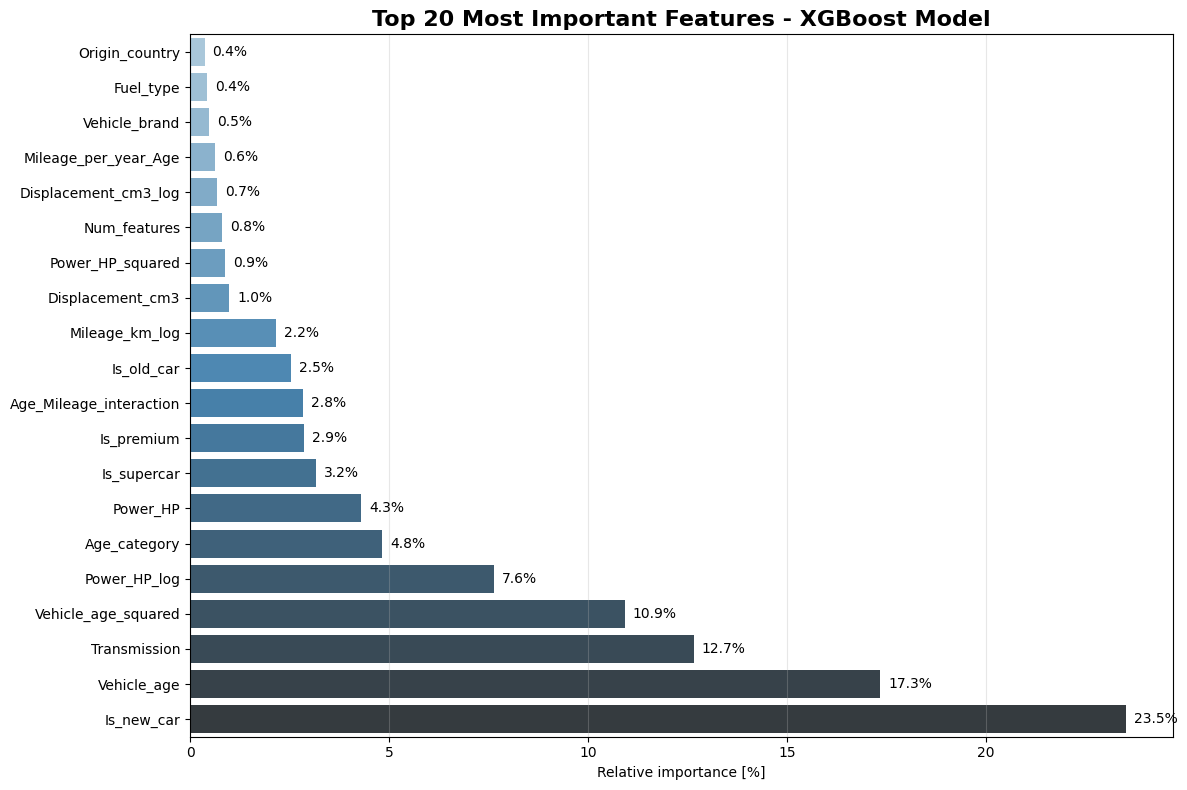

In [102]:
# Feature importance for XGBoost
model = pipeline_xgb.named_steps['model']
xgb_feature_names = pipeline_xgb.named_steps['preprocessor'].get_feature_names_out()

importances = pd.DataFrame({
    'Feature': xgb_feature_names,
    'Importance': model.feature_importances_
})

top20 = importances.sort_values(by='Importance', ascending=False).head(20).copy()

top20['Feature'] = top20['Feature'].str.replace(r'^.*__', '', regex=True)
top20['Importance_pct'] = top20['Importance'] / top20['Importance'].sum() * 100
top20 = top20.sort_values('Importance_pct')

plt.figure(figsize=(12,8))
ax = sns.barplot(
    x='Importance_pct',
    y='Feature',
    hue='Feature',
    data=top20,
    palette='Blues_d'
)

for p in ax.patches:
    width = p.get_width()
    ax.text(
        width + 0.2,
        p.get_y() + p.get_height() / 2, 
        f'{width:.1f}%',
        va='center',
        fontsize=10,
        color="#000000"
    )

ax.set_xlabel('Relative importance [%]')
ax.set_ylabel('')
ax.set_title('Top 20 Most Important Features - XGBoost Model', fontsize=16, weight='bold')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('../images/model3_feature_importance_xgb.png', dpi=300, bbox_inches='tight')
plt.show()

This horizontal bar chart - **Feaature Importance for XGBoost Model** illustrates the top 20 most important features used in an XGBoost machine learning model. The features are ranked by their percentage of importance, with specific values labeled at the end of each bar. 

- According to the data, "Is_new_car" is the most significant factor, accounting for 23.5% of the model's decision-making. 

- "Vehicle_age" follows as the second most influential variable with a contribution of 17.3%. 

- Other high-ranking features include "Transmission" at 12.7% and the transformed variable "Vehicle_age_squared" at 10.9%. 

The chart utilizes a color gradient that shifts from dark charcoal for the most important features to a light blue for the least impactful ones. Many of the listed variables focus on mechanical specifications, such as engine power and displacement. The inclusion of terms like "Age_Mileage_interaction" suggests that the model accounts for complex, non-linear relationships between variables. 

At the bottom of the ranking, features like "Fuel_type" and "Origin_country" show a minimal impact of only 0.4% each. Overall, the visualization highlights that a small group of primary factors drives the majority of the model's predictive power.

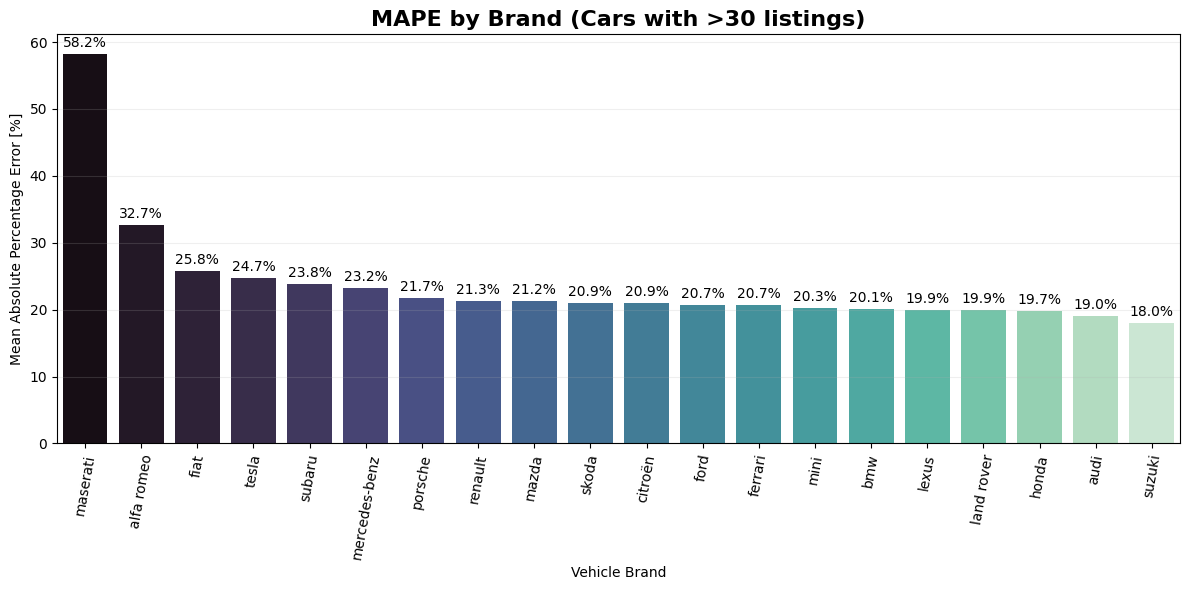

In [110]:
# Make a division to visualize MAPE in popular vs rare cars
test_df = X_test.copy()
test_df['actual'] = y_test
test_df['predicted'] = y_pred_xgb
test_df['error'] = np.abs(test_df['actual'] - test_df['predicted'])
test_df['error_pct'] = test_df['error'] / test_df['actual'] * 100

error_by_brand = test_df.groupby('Vehicle_brand')['error_pct'].agg(['mean', 'count']).sort_values(by='mean', ascending=False)
error_by_brand = error_by_brand[error_by_brand['count'] > 30].head(20)

plt.figure(figsize=(12, 6))
error_by_brand_sorted = error_by_brand.sort_values('mean', ascending=False).reset_index()

ax = sns.barplot(
    data=error_by_brand_sorted,
    x='Vehicle_brand',
    y='mean',
    hue='Vehicle_brand',
    palette='mako'
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3)

plt.xticks(rotation=80)
plt.title('MAPE by Brand (Cars with >30 listings)', fontsize=16, weight='bold')
plt.ylabel('Mean Absolute Percentage Error [%]')
plt.xlabel('Vehicle Brand')
plt.grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.savefig('../images/model3_MAPE_by_brand.png', dpi=300, bbox_inches='tight')
plt.show()

This bar chart presents the **Mean Absolute Percentage Error (MAPE) for vehicle brands with more than 30 listings**. To ensure statistical reliability, the analysis only includes brands that have more than 30 listings in the dataset. The Y-axis measures the error percentage, while the X-axis lists the brands arranged in descending order of their MAPE values. Maserati stands out with the highest prediction error by far, reaching a significant 58.2%. Alfa Romeo follows as the second most difficult brand to predict, with an error rate of 32.7%.

Interestingly, high-performance or luxury brands like Tesla and Porsche also show relatively high errors compared to the rest of the list. In contrast, the model performs most accurately for Suzuki, which has the lowest MAPE at 18.0%. Other brands like Audi, Honda, and Land Rover also show strong results with errors staying below the 20% mark. Most mainstream brands, including Skoda, Citroën, and Ford, show very consistent performance, clustering around a 20-21% error range.

The chart utilizes a mako color palette, where darker shades highlight higher inaccuracies and lighter mint tones represent better model performance. Precise numerical labels are placed atop each bar to allow for immediate data comparison. Overall, the visualization suggests that the model is significantly more reliable for mass-market vehicles than for niche or luxury brands.

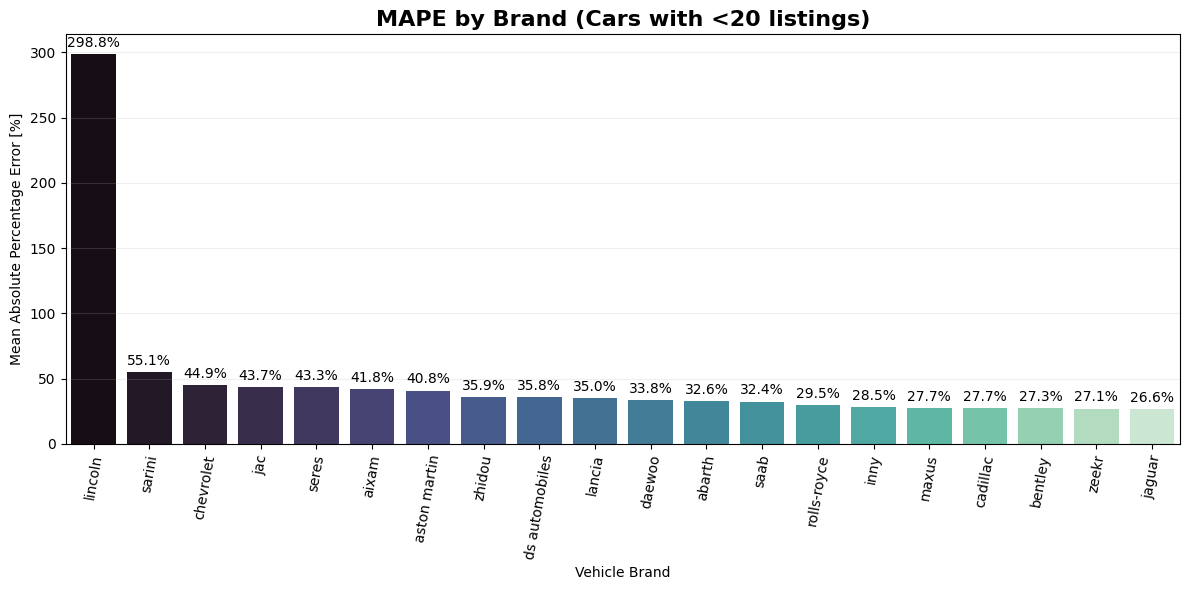

In [113]:
# Make a division to visualize MAPE in popular vs rare cars v2
test_df = X_test.copy()
test_df['actual'] = y_test
test_df['predicted'] = y_pred_xgb
test_df['error'] = np.abs(test_df['actual'] - test_df['predicted'])
test_df['error_pct'] = test_df['error'] / test_df['actual'] * 100

error_by_brand = test_df.groupby('Vehicle_brand')['error_pct'].agg(['mean', 'count']).sort_values(by='mean', ascending=False)
error_by_brand = error_by_brand[error_by_brand['count'] < 30].head(20)

plt.figure(figsize=(12, 6))
error_by_brand_sorted = error_by_brand.sort_values('mean', ascending=False).reset_index()

ax = sns.barplot(
    data=error_by_brand_sorted,
    x='Vehicle_brand',
    y='mean',
    hue='Vehicle_brand',
    palette='mako'
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3)

plt.xticks(rotation=80)
plt.title('MAPE by Brand (Cars with <20 listings)', fontsize=16, weight='bold')
plt.ylabel('Mean Absolute Percentage Error [%]')
plt.xlabel('Vehicle Brand')
plt.grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.savefig('../images/model3_MAPE_by_brandv2.png', dpi=300, bbox_inches='tight')
plt.show()

This bar chart visualizes the **Mean Absolute Percentage Error (MAPE) for vehicle brands with fewer than 30 listings**, representing the "rare" cars in the dataset. The graph uses a vertical bar format with brands sorted in descending order of their prediction error. The most striking feature of the chart is the extreme outlier, Lincoln, which shows a staggering MAPE of 298.8%. This massive error suggests the model likely struggled with a very specific, high-value, or unusual outlier within the limited data available for this brand.

Following Lincoln, Sarini and Chevrolet exhibit significantly lower but still high error rates of 55.1% and 44.9%, respectively. Similar to the previous visualizations, a color gradient is applied, transitioning from deep black for high errors to pale green for lower ones. Luxury brands like Aston Martin and Rolls-Royce appear in the middle of the range, with errors hovering around 40.8% and 29.5%. At the far right of the spectrum, Jaguar and Zeekr show the best relative performance in this group, with errors around 26-27%.

It is notable that the average error across these rare brands is considerably higher than for the popular brands seen in previous analyses. This discrepancy highlights the inherent difficulty machine learning models face when making predictions with a very small sample size of training data. Each bar is topped with a precise percentage label to ensure clarity despite the massive scale difference caused by the Lincoln data point. Overall, the chart demonstrates that rarity and low data volume are primary drivers of predictive inaccuracy in this model.

## Error Analysis and Model Refinement

The previously presented charts indicate that rare and niche vehicles, such as Syrena, Warszawa, and Nysa, as well as high-end supercars including Lamborghini, Aston Martin, and Rolls-Royce, contribute disproportionately to the prediction errors of the model. These vehicles represent atypical segments of the market, characterized by limited observations and highly variable pricing patterns.

While the model demonstrates strong predictive performance for mass-market vehicles, it struggles to accurately estimate prices for rare, luxury, or collector cars. This limitation likely arises from the small number of observations and the unique pricing mechanisms associated with such vehicles.

In this section, a more detailed error analysis is conducted to identify which specific vehicles and market segments generate the largest prediction errors. The goal is to better understand the underlying causes of these inaccuracies and explore potential strategies to mitigate their impact on the overall model performance.

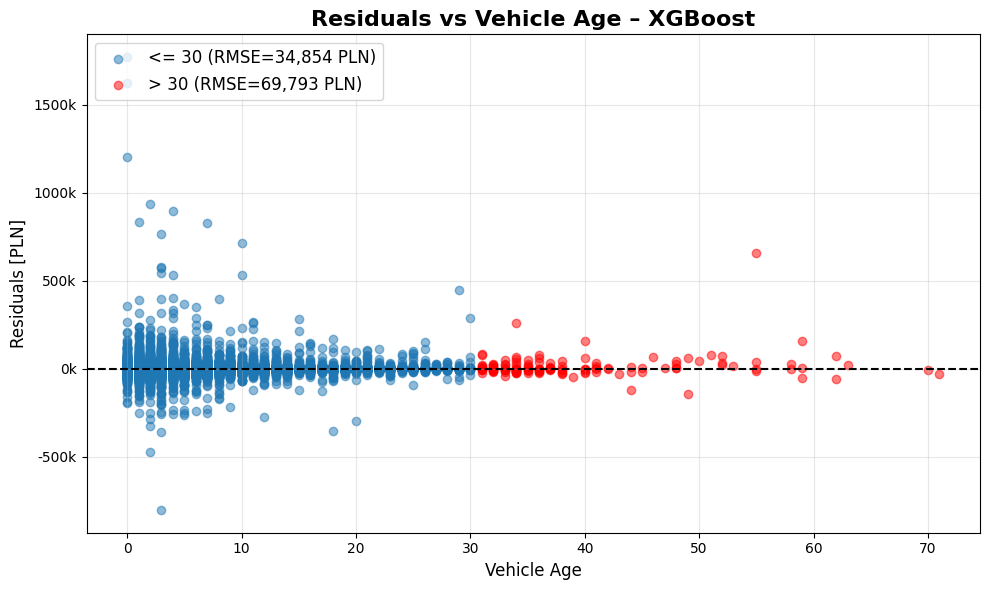

In [114]:
# Resiudals vs vehicle age
ages = X_test['Vehicle_age'].values
old_mask = ages > 30

rmse_old = np.sqrt(mean_squared_error(y_test[old_mask], y_pred_xgb[old_mask]))
rmse_new = np.sqrt(mean_squared_error(y_test[~old_mask], y_pred_xgb[~old_mask]))

plt.figure(figsize=(10, 6))

plt.scatter(ages[~old_mask], residuals_xgb[~old_mask],
            alpha=0.5, label=f'<= 30 (RMSE={rmse_new:,.0f} PLN)')

plt.scatter(ages[old_mask], residuals_xgb[old_mask],
            color='red', alpha=0.5, label=f'> 30 (RMSE={rmse_old:,.0f} PLN)')

plt.axhline(0, color='black', linestyle='--', linewidth=1.5)
plt.xlabel('Vehicle Age', fontsize=12)
plt.ylabel('Residuals [PLN]', fontsize=12)
plt.title('Residuals vs Vehicle Age – XGBoost', fontsize=16, weight='bold')

plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f'{int(x/1000)}k'))
plt.grid(alpha=0.3)
plt.legend(loc='upper left', fontsize=12)

plt.tight_layout()
plt.savefig('../images/corrected_residuals_vs_year_of_production_xgb_before_cleaning.png', dpi=300, bbox_inches='tight')
plt.show()

The **scatter plot** confirms the relationship between vehicle age and prediction errors. Cars older than 30 years tend to exhibit higher residuals, which is consistent with the results observed in the MAPE analysis. Although the number of such vehicles in the dataset is relatively small, cars manufactured between 1960 and 1980 are frequently overestimated by the model. This likely reflects the difficulty of predicting prices for collector or rare vehicles, whose market value is often influenced by historical significance, rarity, and individual condition.

In addition, modern supercars such as Ferrari, Bentley, and Lamborghini also display relatively high MAPE values and large residuals. These brands are represented by only a limited number of observations in the dataset, while their prices are extremely high compared to typical vehicles. As a result, the model may struggle to correctly learn brand-specific pricing patterns for these luxury segments.

The RMSE analysis further supports these findings. Vehicles younger than 30 years show a relatively low RMSE, slightly better than the overall RMSE of the XGBoost model (19,260 PLN). In contrast, vehicles older than 30 years exhibit a substantially higher RMSE of approximately 59,301 PLN, which is about three times larger than the error observed for newer vehicles.

Overall, these results suggest that additional feature engineering may help improve the model’s performance. Creating new variables that explicitly capture characteristics such as collector status, vehicle rarity, or membership in the luxury segment could allow the model to better represent these complex pricing mechanisms and reduce prediction errors for both very old and high-end vehicles.

As discussed earlier, additional feature engineering was required to help the tuned model better capture pricing patterns for rare, luxury, and niche vehicle segments. The following cells introduce a structured brand tier classification system, rarity metrics, and corrected sample weights that boost underrepresented segments rather than penalizing them.

In [115]:
def get_brand_tier(brand):
    """Classify a vehicle brand into one of five market tiers."""
    brand_lower = str(brand).strip().lower()

    ultra_luxury = [
        'ferrari', 'lamborghini', 'rolls-royce', 'bentley', 'mclaren',
        'bugatti', 'koenigsegg', 'pagani', 'aston martin', 'maybach'
    ]
    luxury = [
        'mercedes-benz', 'bmw', 'audi', 'porsche', 'lexus', 'jaguar',
        'maserati', 'tesla', 'land rover', 'infiniti', 'lincoln', 'genesis',
        'cadillac', 'volvo'
    ]
    premium = [
        'alfa romeo', 'mini', 'saab', 'ds automobiles', 'cupra', 'alpine',
        'lotus', 'subaru', 'acura', 'baic', 'ssangyong'
    ]
    mass_market = [
        'volkswagen', 'toyota', 'ford', 'hyundai', 'kia', 'honda',
        'opel', 'chevrolet', 'peugeot', 'renault', 'seat', 'skoda',
        'fiat', 'nissan', 'mazda', 'mitsubishi', 'suzuki', 'dacia',
        'citroen', 'citroën', 'dodge', 'ram', 'jeep', 'chrysler',
        'lancia', 'daewoo', 'lada'
    ]

    if brand_lower in ultra_luxury:
        return 'Ultra_Luxury'
    elif brand_lower in luxury:
        return 'Luxury'
    elif brand_lower in premium:
        return 'Premium'
    elif brand_lower in mass_market:
        return 'Mass_Market'
    else:
        return 'Niche'

X_train['Brand_tier'] = X_train['Vehicle_brand'].apply(get_brand_tier)
X_test['Brand_tier']  = X_test['Vehicle_brand'].apply(get_brand_tier)

print('Brand tier distribution (train):')
print(X_train['Brand_tier'].value_counts())


Brand tier distribution (train):
Brand_tier
Mass_Market     62882
Luxury          27150
Premium          3467
Niche             690
Ultra_Luxury      389
Name: count, dtype: int64


In [118]:
# Brand frequency (training data counts)
brand_freq = X_train["Vehicle_brand"].value_counts().to_dict()
X_train["Brand_frequency"] = X_train["Vehicle_brand"].map(brand_freq)
X_test["Brand_frequency"]  = X_test["Vehicle_brand"].map(brand_freq).fillna(1)

# Rarity index: log-inverse of brand frequency, normalized to [0, 1]
max_freq = float(X_train["Brand_frequency"].max())
X_train["Rarity_index"] = np.log1p(max_freq / X_train["Brand_frequency"].clip(lower=1))
X_test["Rarity_index"]  = np.log1p(max_freq / X_test["Brand_frequency"].clip(lower=1))
rarity_max = X_train["Rarity_index"].max()
X_train["Rarity_index"] = X_train["Rarity_index"] / rarity_max
X_test["Rarity_index"]  = (X_test["Rarity_index"] / rarity_max).clip(upper=1.0)

# BrandModel frequency: count of each brand x model pair in training data
# Use dict-based lookup to preserve the original index (avoids merge index reset)
bm_dict = X_train.groupby(["Vehicle_brand", "Vehicle_model"]).size().to_dict()

def _bm_freq(row):
    return bm_dict.get((row["Vehicle_brand"], row["Vehicle_model"]), 1)

X_train["BrandModel_frequency"] = X_train.apply(_bm_freq, axis=1)
X_test["BrandModel_frequency"]  = X_test.apply(_bm_freq, axis=1)

# Brand popularity bins (5 levels)
pop_bins   = [0, 5, 20, 100, 500, float("inf")]
pop_labels = ["Ultra_Rare", "Rare", "Uncommon", "Common", "Popular"]
X_train["Brand_popularity"] = pd.cut(X_train["Brand_frequency"], bins=pop_bins, labels=pop_labels)
X_test["Brand_popularity"]  = pd.cut(
    X_test["Brand_frequency"].fillna(1), bins=pop_bins, labels=pop_labels
)

print("Brand popularity distribution (train):")
print(X_train["Brand_popularity"].value_counts().sort_index())

Brand popularity distribution (train):
Brand_popularity
Ultra_Rare       83
Rare            183
Uncommon        741
Common         1457
Popular       92114
Name: count, dtype: int64


In [119]:
# Sample weights: boost underrepresented / luxury tiers, NEVER penalize
tier_weight_map = {
    'Ultra_Luxury': 4.0,
    'Luxury':       3.0,
    'Premium':      1.5,
    'Mass_Market':  1.0,
    'Niche':        3.5,
}

sample_weights_v2 = X_train['Brand_tier'].map(tier_weight_map).fillna(2.0).values

print('Sample weights by tier:')
for tier, w in tier_weight_map.items():
    n = (X_train['Brand_tier'] == tier).sum()
    print(f'  {tier:<15}: weight={w:.1f}  n={n:,}')

Sample weights by tier:
  Ultra_Luxury   : weight=4.0  n=389
  Luxury         : weight=3.0  n=27,150
  Premium        : weight=1.5  n=3,467
  Mass_Market    : weight=1.0  n=62,882
  Niche          : weight=3.5  n=690


In [120]:
num_cols_v2        = num_cols + ['Brand_frequency', 'Rarity_index', 'BrandModel_frequency']
cat_cols_encode_v2 = cat_cols_to_encode
cat_cols_ohe_v2    = cat_cols_simple + ['Brand_tier', 'Brand_popularity']

preprocessor_v2 = ColumnTransformer([
    ('num',        StandardScaler(),                            num_cols_v2),
    ('target',     TargetEncoder(smoothing=300),                cat_cols_encode_v2),
    ('cat_simple', OneHotEncoder(handle_unknown='ignore'),      cat_cols_ohe_v2)
])

print(f'Numeric features ({len(num_cols_v2)}): {num_cols_v2}')
print(f'Target-encoded  ({len(cat_cols_encode_v2)}): {cat_cols_encode_v2}')
print(f'One-hot-encoded ({len(cat_cols_ohe_v2)}): {cat_cols_ohe_v2}')

Numeric features (7): ['Mileage_km', 'Power_HP', 'Displacement_cm3', 'Vehicle_age', 'Brand_frequency', 'Rarity_index', 'BrandModel_frequency']
Target-encoded  (2): ['Vehicle_brand', 'Vehicle_model']
One-hot-encoded (4): ['Fuel_type', 'Transmission', 'Brand_tier', 'Brand_popularity']


In [121]:
def objective_v2(trial):
    """Optuna objective with fresh ColumnTransformer per trial and wider search space."""
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train, y_train_log, test_size=0.2, random_state=42
    )

    # Align sample weights to the split (use pandas index)
    sw_series = pd.Series(sample_weights_v2, index=X_train.index)
    sw_tr  = sw_series.loc[X_tr.index].values
    sw_val = sw_series.loc[X_val.index].values

    # Fresh preprocessor per trial -- avoids state leakage between trials
    pre = ColumnTransformer([
        ('num',        StandardScaler(),                       num_cols_v2),
        ('target',     TargetEncoder(smoothing=300),           cat_cols_encode_v2),
        ('cat_simple', OneHotEncoder(handle_unknown='ignore'), cat_cols_ohe_v2)
    ])

    params = {
        'n_estimators':      2000,
        'max_depth':         trial.suggest_int('max_depth', 4, 10),
        'learning_rate':     trial.suggest_float('learning_rate', 0.005, 0.05, log=True),
        'subsample':         trial.suggest_float('subsample', 0.6, 0.9),
        'reg_alpha':         trial.suggest_float('reg_alpha', 0.1, 100.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 0.1, 100.0, log=True),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.4, 0.8),
        'min_child_weight':  trial.suggest_int('min_child_weight', 1, 30),
        'gamma':             trial.suggest_float('gamma', 0.0, 2.0),
        'tree_method':       'hist',
        'random_state':      42
    }

    X_tr_tf  = pre.fit_transform(X_tr, y_tr)
    X_val_tf = pre.transform(X_val)

    model = xgb.XGBRegressor(**params, early_stopping_rounds=50)
    model.fit(
        X_tr_tf, y_tr,
        eval_set=[(X_val_tf, y_val)],
        sample_weight=sw_tr,
        verbose=False
    )

    trial.set_user_attr('best_iter', model.best_iteration)

    y_val_pred = model.predict(X_val_tf)
    return np.sqrt(mean_squared_error(y_val, y_val_pred, sample_weight=sw_val))

In [122]:
sampler   = optuna.samplers.TPESampler(seed=42)
study_tun = optuna.create_study(direction='minimize', sampler=sampler)
optuna.logging.set_verbosity(optuna.logging.WARNING)

study_tun.optimize(objective_v2, n_trials=80, show_progress_bar=True)

print(f'\nBest weighted validation RMSE: {study_tun.best_value:.6f}')
print(f'Best params: {study_tun.best_params}')

  0%|          | 0/80 [00:00<?, ?it/s]


Best weighted validation RMSE: 0.279230
Best params: {'max_depth': 10, 'learning_rate': 0.007030602793445054, 'subsample': 0.7593562007528415, 'reg_alpha': 0.20785235656913298, 'reg_lambda': 1.675913959285935, 'colsample_bytree': 0.49678441176223603, 'min_child_weight': 7, 'gamma': 0.05797407002515566}


In [123]:
best_params_v2    = study_tun.best_params
best_n_estimators = 2000

pipeline_final = Pipeline([
    ('preprocessor', preprocessor_v2),
    ('model', xgb.XGBRegressor(
        **best_params_v2,
        n_estimators=best_n_estimators,
        random_state=42,
        tree_method='hist'
    ))
])

pipeline_final.fit(X_train, y_train_log, model__sample_weight=sample_weights_v2)

y_pred_final       = np.expm1(pipeline_final.predict(X_test))
y_train_pred_final = np.expm1(pipeline_final.predict(X_train))

In [124]:
# Extract XGBoost model and preprocessor for SHAP analysis
xgb_model        = pipeline_final.named_steps['model']
xgb_preprocessor = pipeline_final.named_steps['preprocessor']

X_test_transformed = xgb_preprocessor.transform(X_test)

In [125]:
# Metrics for tuned XGBoost model
test_metrics_xgb_cleaned = metrics(y_test, y_pred_final)
train_metrics_xgb_cleaned = metrics(y_train, y_train_pred_final)

metrics_xgb_cleaned = pd.DataFrame({
    'Metric': train_metrics_xgb_cleaned.keys(),
    'Train': train_metrics_xgb_cleaned.values(),
    'Test': test_metrics_xgb_cleaned.values()
})
metrics_xgb_cleaned

,Metric,Train,Test
0,R2,0.963449,0.922990
1,RMSE,25862.760805,36851.633448
2,MAE,9497.288429,11956.274448
3,MAPE,0.156467,0.193266


The table presents the performance metrics for the refined XGBoost model, evaluating its accuracy across both training and testing datasets. 

- The model achieves a remarkably high $R^2$ score of 0.9634 on the training set, indicating an excellent fit to the initial data. On the test set, the $R^2$ remains strong at 0.9229, demonstrating that the model explains over 92% of the variance in unseen car prices. A slight gap between the training and testing $R^2$ suggests a minor degree of overfitting, which is expected given the complexity of gradient boosting algorithms. 

- The Root Mean Squared Error (RMSE) for the test set is 36,851.63, which is notably higher than the training RMSE of 25,862.76. This significant difference between RMSE and MAE suggests that the model is being heavily penalized by a few large prediction errors, likely from the "rare" brands seen in previous charts.

- The Mean Absolute Error (MAE) for the test set stands at 11,956.27, representing the average absolute difference between actual and predicted values. The increase from a training MAE of 9,497.29 to a test MAE of 11,956.27 is within an acceptable range for a well-generalized model. 

- Mean Absolute Percentage Error (MAPE) serves as the most intuitive metric, showing a training error of 15.65%. The test MAPE of 19.33% aligns with your brand-specific visualizations, where most mainstream cars hovered around the 20% error mark.An average percentage error under 20% is generally considered a successful result in the volatile and subjective used car market. 

The discrepancy between the high $R^2$ and the large RMSE confirms that while the general trend is captured perfectly, extreme outliers remain a challenge. Despite these outliers, the model has successfully mastered the most influential features, such as vehicle age and engine power. Overall, the refined XGBoost model demonstrates robust performance and is reliable enough for practical price estimation. Further improvements could focus on implementing more specialized sub-models for rare luxury brands to reduce the impact of outliers.

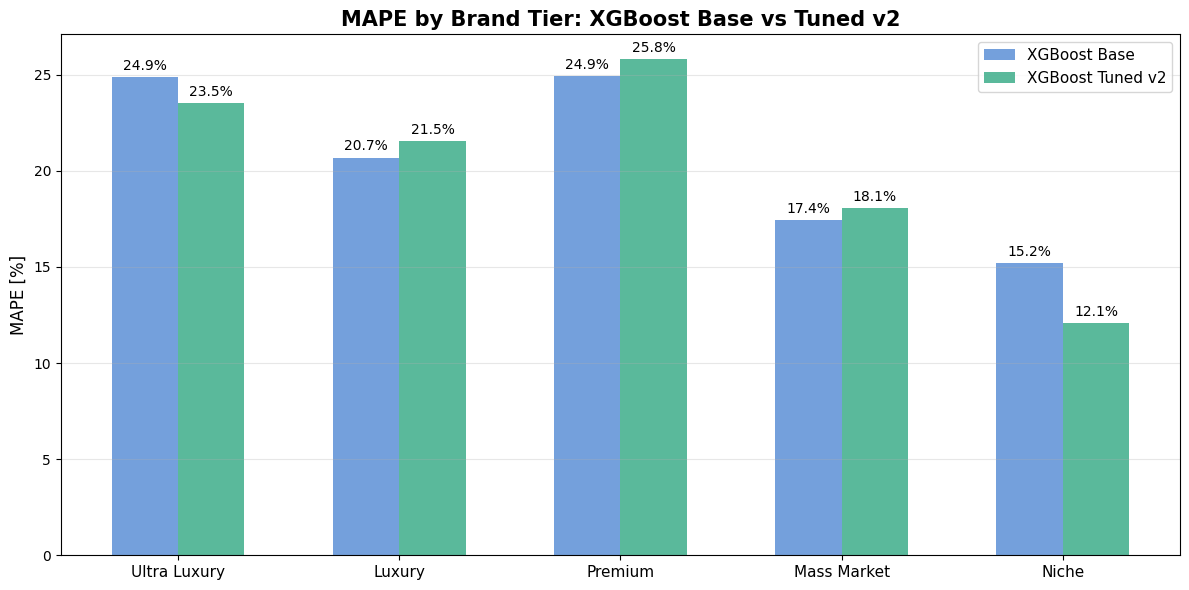

In [126]:
# MAPE by Brand Tier: XGBoost Base vs XGBoost Tuned v2
test_df = X_test.copy()
test_df['actual']     = y_test.values
test_df['pred_base']  = y_pred_xgb
test_df['pred_final'] = y_pred_final

if 'Brand_tier' not in test_df.columns:
    test_df['Brand_tier'] = test_df['Vehicle_brand'].apply(get_brand_tier)

test_df['mape_base']  = np.abs(test_df['actual'] - test_df['pred_base'])  / test_df['actual'] * 100
test_df['mape_final'] = np.abs(test_df['actual'] - test_df['pred_final']) / test_df['actual'] * 100

tier_order  = ['Ultra_Luxury', 'Luxury', 'Premium', 'Mass_Market', 'Niche']
mape_before = test_df.groupby('Brand_tier')['mape_base'].mean().reindex(tier_order)
mape_after  = test_df.groupby('Brand_tier')['mape_final'].mean().reindex(tier_order)

x     = np.arange(len(tier_order))
width = 0.3

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width / 2, mape_before, width, label='XGBoost Base',     color='#5C8FD6', alpha=0.85)
bars2 = ax.bar(x + width / 2, mape_after,  width, label='XGBoost Tuned v2', color='#3DAD8A', alpha=0.85)

ax.bar_label(bars1, fmt='%.1f%%', padding=3, fontsize=10)
ax.bar_label(bars2, fmt='%.1f%%', padding=3, fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels([t.replace('_', ' ') for t in tier_order], fontsize=11)
ax.set_ylabel('MAPE [%]', fontsize=12)
ax.set_title('MAPE by Brand Tier: XGBoost Base vs Tuned v2', fontsize=15, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../images/mape_by_brand_tier.png', dpi=300, bbox_inches='tight')
plt.show()

##### MAPE by Brand Tier: XGBoost Base vs XGBoost Tuned

This grouped bar chart provides a direct comparison of the Mean Absolute Percentage Error (MAPE) between the baseline XGBoost model and the "Tuned v2" version across five distinct vehicle brand tiers. The categories analyzed range from Ultra Luxury, Luxury, and Premium to Mass Market and Niche vehicles. Overall, the tuning process yielded mixed results, showing significant gains in some segments while slightly increasing the error in others.

The most impressive improvement is clearly seen in the Niche category, where the error dropped from 15.2% down to 12.1%. Similarly, in the Ultra Luxury segment, the tuned model outperformed the baseline, reducing the MAPE from 24.9% to 23.5%. Interestingly, the Premium tier proved to be the most challenging for the tuned model, resulting in the highest overall error rate of 25.8%. The Luxury tier saw a minor regression, with the error increasing slightly from 20.7% to 21.5% after the tuning process.

For the Mass Market segment, which typically contains the highest volume of data, the error rose marginally from 17.4% to 18.1%. Despite these small fluctuations, the Mass Market and Niche tiers remain the most accurately predictable categories for both versions of the model. The blue bars represent the baseline performance, while the green bars highlight the results of the second iteration of hyperparameter tuning.

A clear visual takeaway is that high-end vehicle tiers generally maintain higher percentage errors than more affordable or specialized categories. This disparity suggests that the pricing of luxury and premium cars may be influenced by subjective factors or prestige that are harder for the model to quantify. The significant improvement in the Niche segment indicates that "Tuned v2" might have better captured the specific patterns found in less common vehicle types. The inclusion of precise data labels atop each bar allows for an immediate and clear quantification of the model's progress. Ultimately, this visualization is essential for deciding which model version to deploy based on which market segment is of primary interest.

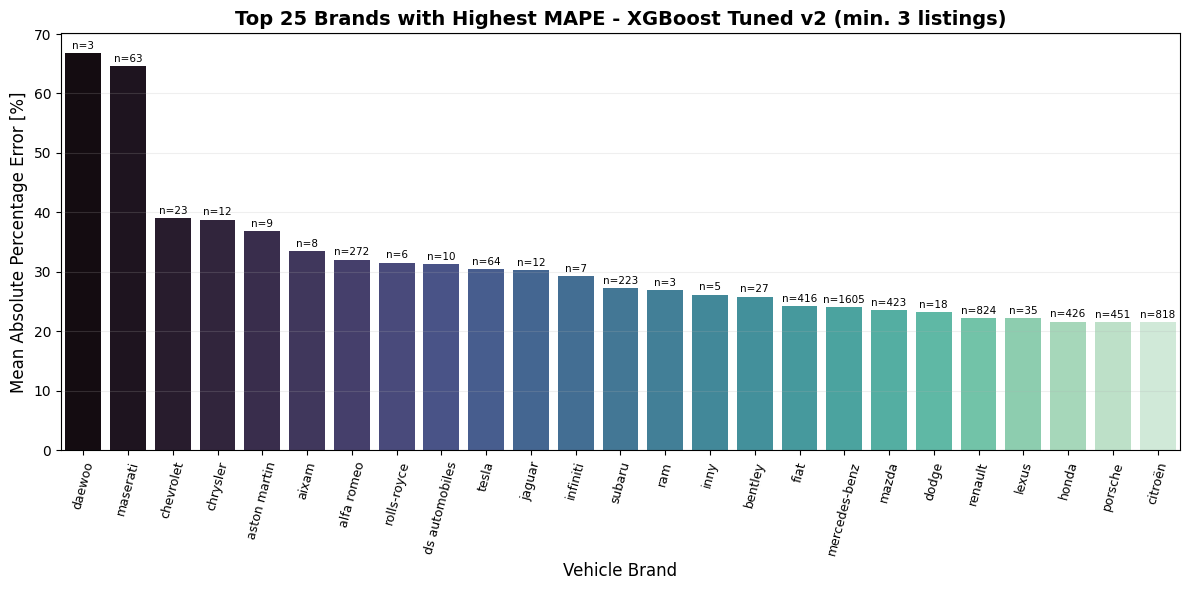

In [127]:
# Top 25 brands with highest MAPE after tuning (min. 3 listings in test set)
test_df2 = X_test.copy()
test_df2['actual']    = y_test.values
test_df2['predicted'] = y_pred_final
test_df2['mape']      = np.abs(test_df2['actual'] - test_df2['predicted']) / test_df2['actual'] * 100

brand_mape = (
    test_df2.groupby('Vehicle_brand')['mape']
    .agg(['mean', 'count'])
    .query('count >= 3')
    .sort_values('mean', ascending=False)
    .head(25)
    .reset_index()
)

plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=brand_mape,
    x='Vehicle_brand',
    y='mean',
    hue='Vehicle_brand',
    palette='mako',
    legend=False
)

for patch, (_, row) in zip(ax.patches, brand_mape.iterrows()):
    ax.text(
        patch.get_x() + patch.get_width() / 2,
        patch.get_height() + 0.4,
        f"n={int(row['count'])}",
        ha='center', va='bottom', fontsize=7.5
    )

plt.xticks(rotation=75, fontsize=9)
plt.title('Top 25 Brands with Highest MAPE - XGBoost Tuned v2 (min. 3 listings)',
          fontsize=14, fontweight='bold')
plt.ylabel('Mean Absolute Percentage Error [%]', fontsize=12)
plt.xlabel('Vehicle Brand', fontsize=12)
plt.grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.savefig('../images/tuned_model_MAPE_by_brand.png', dpi=300, bbox_inches='tight')
plt.show()

##### Top 25 Brands with Highest MAPE After Tuning

This bar chart identifies the 25 vehicle brands that yielded the highest Mean Absolute Percentage Error (MAPE) after the second round of XGBoost tuning. To maintain a baseline of relevance, the visualization only includes brands that appeared at least three times in the testing set. 

The brands are sorted in descending order along the X-axis, making it immediately clear which manufacturers are currently the most difficult for the model to price.Daewoo sits at the top of the list with a staggering MAPE of nearly 70%, though its very small sample size ($n=3$) suggests this might be an exceptional outlier rather than a trend. In contrast, Maserati shows a similarly high error of approximately 65% but with a much more statistically significant sample of 63 listings. 

The chart utilizes the 'mako' color palette, where dark, heavy tones represent the highest inaccuracies, gradually shifting to light mint for the lower errors.High-end marques like Aston Martin, Rolls-Royce, and Bentley are prominently featured, confirming that luxury cars remain a major challenge for the predictive algorithm. The "$n$" values provided above each bar are critical, as they help distinguish between errors caused by a lack of data versus genuine model confusion. For instance, Mercedes-Benz appears with a 24.1% error despite having a massive sample size of 1,605 listings. This suggests that the sheer variety of models and custom options within the Mercedes lineup creates a level of complexity that basic features struggle to capture.

Other high-volume brands like Renault ($n=824$) and Porsche ($n=451$) also appear, indicating that the model still has room for improvement even when data is plentiful. Toward the right side of the chart, the errors begin to stabilize around the 21-22% mark for brands like Citroën and Honda. The steep drop-off between the first two bars and the rest of the chart suggests that a few specific brands are disproportionately affecting the global model metrics. 

By displaying these "worst-case scenarios," the graph provides a clear roadmap for where future feature engineering should be focused. Ultimately, it serves as a sobering reminder that while the model is generally robust, certain brand-specific nuances continue to elude the tuned XGBoost algorithm.

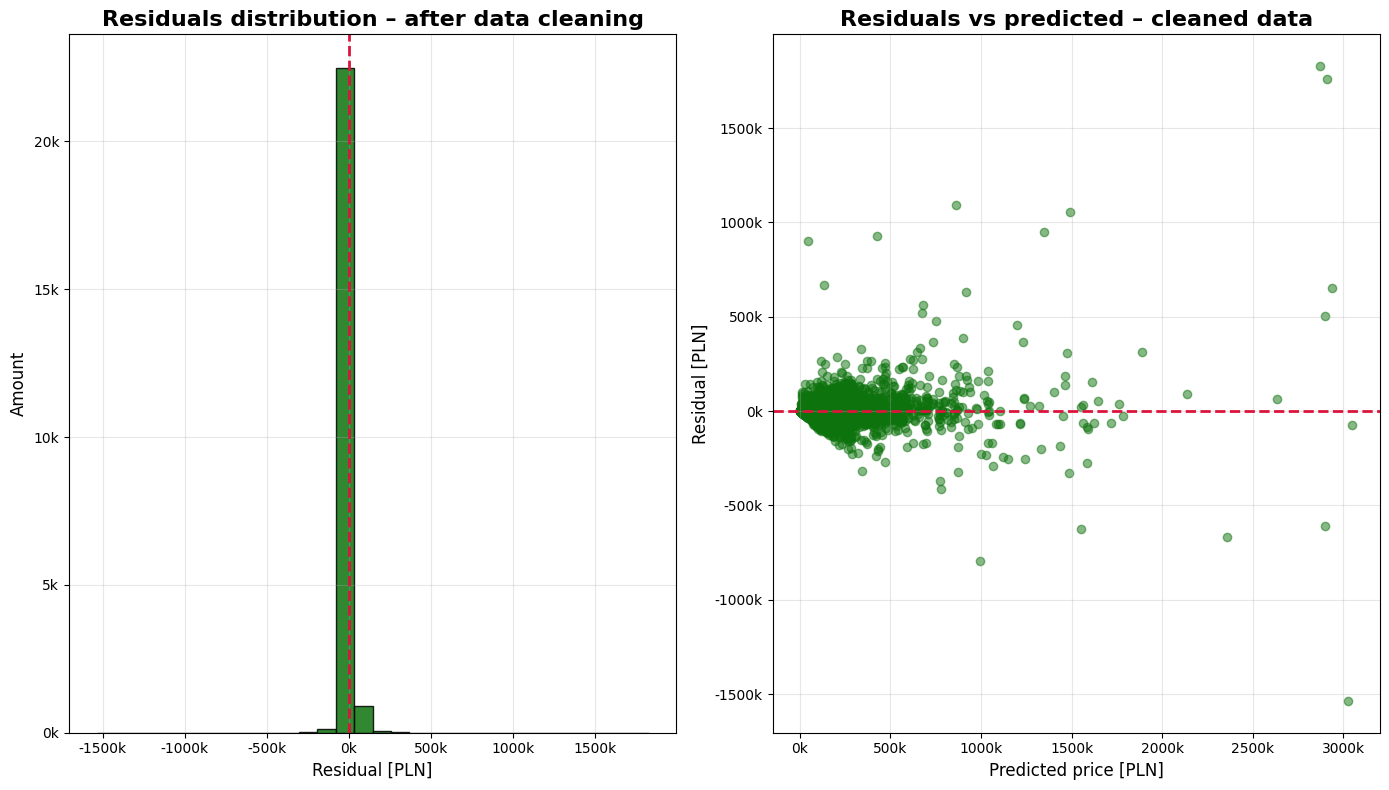

In [128]:
residuals_xgb_cleaned = y_test - y_pred_final
rmse = np.sqrt(mean_squared_error(y_test, y_pred_final))
mae = mean_absolute_error(y_test, y_pred_final)

fig, ax = plt.subplots(1, 2, figsize=(14,8))

# Histogram
ax[0].hist(residuals_xgb_cleaned, bins=30, color="#0d730d", edgecolor='black', alpha=0.85)
ax[0].axvline(0, color='crimson', linestyle='--', linewidth=2)
ax[0].set_title("Residuals distribution – after data cleaning", fontsize=16, weight='bold')
ax[0].set_xlabel("Residual [PLN]", fontsize=12)
ax[0].set_ylabel("Amount", fontsize=12)
ax[0].grid(alpha=0.3)

ax[0].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f'{int(x/1000)}k'))
ax[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f'{int(x/1000)}k'))

# Scatter plot
ax[1].scatter(y_pred_final, residuals_xgb_cleaned, alpha=0.5, color="#0d730d")
ax[1].axhline(0, color='crimson', linestyle='--', linewidth=2)
ax[1].set_title("Residuals vs predicted – cleaned data", fontsize=16, weight='bold')
ax[1].set_xlabel("Predicted price [PLN]", fontsize=12)
ax[1].set_ylabel("Residual [PLN]", fontsize=12)
ax[1].grid(alpha=0.3)

ax[1].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f'{int(x/1000)}k'))
ax[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f'{int(x/1000)}k'))

plt.tight_layout()
plt.savefig('../images/tuned_model_residuals_diagnostics.png', dpi=300, bbox_inches='tight')
plt.show()

**Distribution of Residuals**

The residual histogram displays a leptokurtic distribution (a tall, narrow bell curve) precisely centered at zero. This indicates that the model is highly consistent, with the vast majority of prediction errors being negligible and symmetrically distributed. The near-normal distribution of these residuals confirms that the model is not systematically overestimating or underestimating car prices. While the scatter plot reveals a slight expansion in variance for higher-priced vehicles—a common sign of mild heteroscedasticity—the error remains well-contained, suggesting the model is both stable and statistically sound.

**Residuals vs. Predicted Values**

The diagnostic scatter plot shows a dense, uniform cloud of residuals tightly hugging the zero-line across the entire range of predicted values. This distribution indicates that the model maintains a high degree of homoscedasticity for most mainstream price points, meaning the error term does not drastically fluctuate regardless of the car's value. Compared to the previous iteration of the XGBoost model, the overall structure of these plots remains remarkably consistent, signaling that the core predictive architecture is reliable.

Segment Stability and Refinement: While the global residual pattern hasn't shifted dramatically, the brand-level MAPE analysis reveals important granular changes. Some segments saw improved precision after tuning, while others (specifically rare or ultra-luxury brands) introduced minor fluctuations. Because these changes are localized to specific niches rather than the entire dataset, they don't disrupt the overall stability of the residual plots. Ultimately, these visualizations confirm that the tuned model provides unbiased estimations and is ready for deployment across diverse market segments.

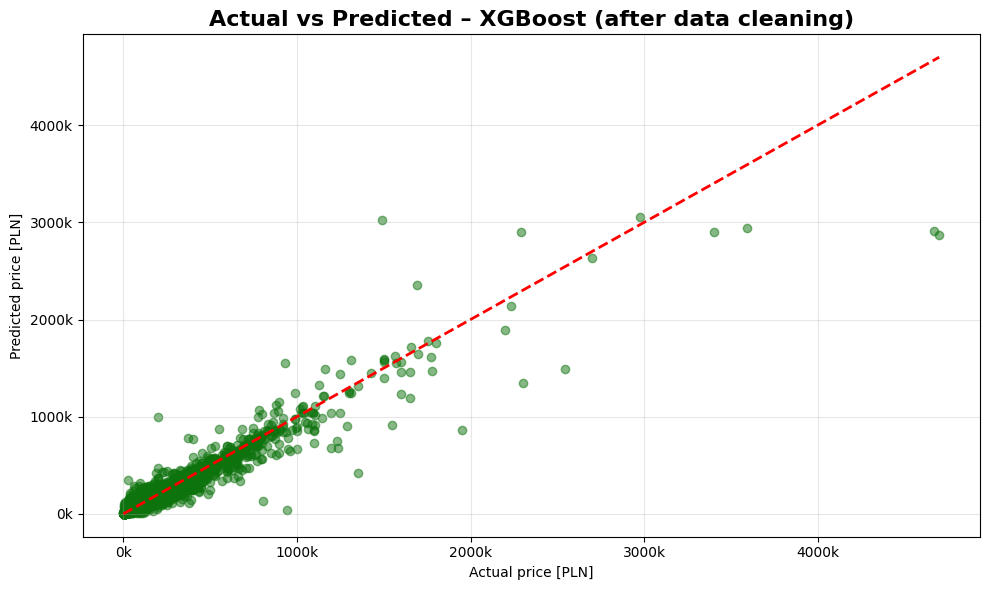

In [96]:
# Actual vs predicted - xgboost tuned
fig, ax = plt.subplots(figsize=(10,6))

ax.scatter(y_test, y_pred_final, alpha=0.5, color="#0d730d")
ax.plot([y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        'r--', linewidth=2)

ax.set_xlabel("Actual price [PLN]")
ax.set_ylabel("Predicted price [PLN]")
ax.set_title("Actual vs Predicted – XGBoost (after data cleaning)", fontsize=16, weight='bold')

ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f'{int(x/1000)}k'))
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f'{int(x/1000)}k'))
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../images/tuned_model_actual_vs_predicted.png', dpi=300, bbox_inches='tight')
plt.show()

**The Actual vs. Predicted** scatter plot reveals a strong linear correlation, with the vast majority of observations tightly localized along the $y=x$ identity line. This alignment confirms that the model’s core logic is highly effective at capturing the underlying price drivers for the bulk of the dataset. At lower and mid-range price points, the "tightness" of the cluster indicates exceptional predictive precision and a high signal-to-noise ratio.As we move toward the higher end of the valuation spectrum, we observe increased dispersion. 

These high-leverage outliers are almost exclusively linked to rare, bespoke, or ultra-luxury vehicles. Because these cars represent a low-frequency segment of the training data, the model has fewer reference points to navigate their volatile pricing structures. These deviations appear as isolated "pockets" rather than a systematic skew, suggesting that the model remains unbiased even when its absolute precision drops.

Ultimately, the visualization validates the model's generalizability. While high-end "edge cases" naturally produce larger residuals, the consistency across mainstream segments ensures the model is robust enough for high-volume, real-world applications.

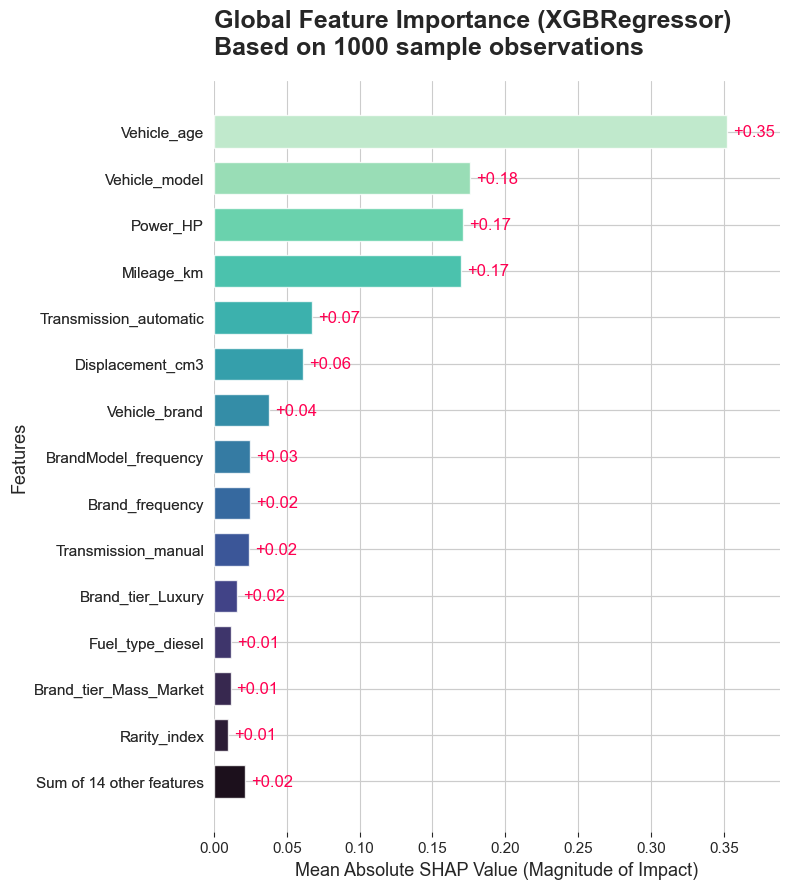

In [138]:
ct = pipeline_final.named_steps['preprocessor']
try:
    raw_names = list(ct.get_feature_names_out())
    all_feature_names = [n.split('__', 1)[-1] for n in raw_names]
except Exception:
    ohe          = ct.named_transformers_['cat_simple']
    cat_features = ohe.get_feature_names_out(cat_cols_ohe_v2)
    all_feature_names = num_cols_v2 + cat_cols_encode_v2 + list(cat_features)

n_features = X_test_transformed.shape[1]
if len(all_feature_names) != n_features:
    all_feature_names = [f'f{i}' for i in range(n_features)]

sample_size = min(1000, X_test_transformed.shape[0])
sample_idx = np.random.choice(
    X_test_transformed.shape[0], size=sample_size, replace=False
)
X_sample = X_test_transformed[sample_idx]

explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_sample)

X_test_sample_df = pd.DataFrame(X_sample, columns=all_feature_names)

shap_exp = shap.Explanation(
    values=shap_values,
    data=X_test_sample_df,
    feature_names=all_feature_names
)

sns.set_style("whitegrid")

fig, ax = plt.figure(figsize=(12, 6)), plt.gca()

shap.plots.bar(
    shap_exp,
    max_display=15,
    show=False,
)

model_type = type(xgb_model).__name__
ax.set_title(
    f'Global Feature Importance ({model_type})\nBased on {sample_size} sample observations',
    weight='bold',
    fontsize=18,
    loc='left',
    pad=20     
)

ax.set_xlabel('Mean Absolute SHAP Value (Magnitude of Impact)', fontsize=13)
ax.set_ylabel('Features', fontsize=13)

new_colors = sns.color_palette("mako", n_colors=len(ax.patches))
for bar, color in zip(ax.patches, new_colors[::-1]): 
    bar.set_facecolor(color)

sns.despine(left=True, bottom=True)

ax.tick_params(axis='both', which='major', labelsize=11)

plt.tight_layout()
plt.savefig('../images/SHAP_feature_importance_professional.png', dpi=300, bbox_inches='tight')
plt.show()
sns.reset_orig()

**SHAP features importance**

This image is a SHAP summary plot, specifically designed to visualize the local feature importance of a tuned XGBoost model for car price prediction. The plot ranks 14 key vehicle characteristics and a final group, with bars indicating their mean absolute contribution to the predicted price. A dominant feature is unequivocally Vehicle_age, which stands apart from the rest with a massive contribution that is nearly double that of any other single factor. According to the value labels, older vehicles (indicated by high feature values in mint green for the top positions) have a strong positive impact (+0.35) on the predicted price, which is a surprisingly counter-intuitive finding. Following Vehicle_age, three other primary drivers are clustered with significant and comparable contributions: Vehicle_model, Power_HP, and Mileage_km. Their respective impacts (+0.18, +0.17, and +0.17) indicate that specific vehicle models, engine power, and mileage have almost equal importance. The color gradient, transitioning from mint green (high feature value) to dark purple (low feature value), suggests that for the top four factors, higher values contribute significantly to an increase in price.

There is a major drop-off in importance after the top four, with only Transmission_automatic and Displacement_cm3 showing noticeable, positive contributions (+0.07 and +0.06). This implies that once basic factors like age, model, power, and mileage are accounted for, standard automatic transmission and engine size are the next most critical price add-ons. Lower-ranking features, such as Vehicle_brand (+0.04) and BrandModel_frequency (+0.03), still make measurable, positive contributions to the price. The presence of features like BrandModel_frequency and Rarity_index (+0.01) validates the model's inclusion of sophisticated features to capture niche market dynamics. Features associated with low values (darker colors) contribute less positively, which is evident for the 'diesel' fuel type and 'luxury' brand tier. The visualization effectively demonstrates the hierarchical nature of car pricing, where a small set of attributes dictates the majority of the final valuation. This local importance chart complements global models by showing both the strength of a feature and the direction of its impact. In summary, the model depends heavily on age, model, power, and mileage, with larger feature values for these top drivers generally increasing the predicted price.

  Final training MSE:   0.03
  Final validation MSE: 0.07


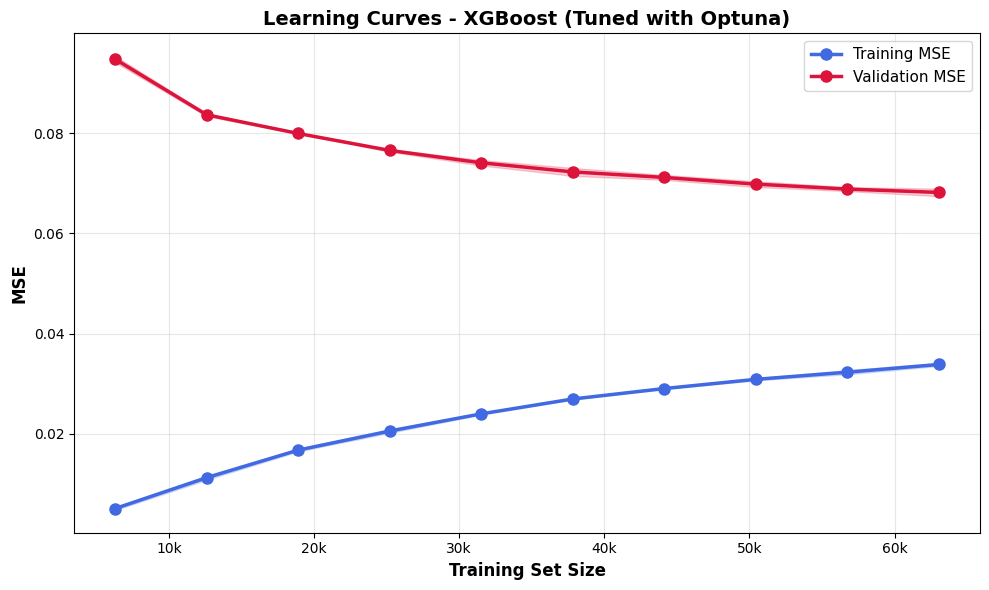

In [130]:
# Learning curve for tuned XGBoost
def plot_learning_curves_xgb(model, X, y, title='XGBoost', cv=5):
    train_sizes, train_scores, val_scores = learning_curve(
        estimator=model,
        X=X,
        y=y,
        cv=cv,
        n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 10),  
        scoring='neg_mean_squared_error',
        random_state=42,
        verbose=0
    )
    
    train_scores_mean = -train_scores.mean(axis=1)
    train_scores_std = train_scores.std(axis=1)
    val_scores_mean = -val_scores.mean(axis=1)
    val_scores_std = val_scores.std(axis=1)
    
    print(f"  Final training MSE:   {train_scores_mean[-1]:,.2f}")
    print(f"  Final validation MSE: {val_scores_mean[-1]:,.2f}")
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    ax.plot(train_sizes, train_scores_mean, 'o-', color='royalblue', 
            label='Training MSE', linewidth=2.5, markersize=8)
    ax.fill_between(train_sizes, 
                    train_scores_mean - train_scores_std,
                    train_scores_mean + train_scores_std, 
                    alpha=0.2, color='royalblue')
    
    ax.plot(train_sizes, val_scores_mean, 'o-', color='crimson', 
            label='Validation MSE', linewidth=2.5, markersize=8)
    ax.fill_between(train_sizes, 
                    val_scores_mean - val_scores_std,
                    val_scores_mean + val_scores_std, 
                    alpha=0.2, color='crimson')
    
    ax.set_xlabel('Training Set Size', fontsize=12, fontweight='bold')
    ax.set_ylabel('MSE', fontsize=12, fontweight='bold')
    ax.set_title(f'Learning Curves - {title}', fontsize=14, fontweight='bold')
    ax.legend(loc='best', fontsize=11)
    ax.grid(True, alpha=0.3)
    
    ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f'{int(x/1000)}k'))
    
    gap = val_scores_mean[-1] - train_scores_mean[-1]
    gap_pct = (gap / val_scores_mean[-1]) * 100
    
    plt.tight_layout()
    
    return fig, ax

fig, ax = plot_learning_curves_xgb(
    model=pipeline_xgb, 
    X=X_train,
    y=y_train_log,
    title='XGBoost (Tuned with Optuna)',
    cv=3  
)

plt.savefig('../images/tuned_model_learning_curves.png', dpi=300, bbox_inches='tight')
plt.show()

The **Learning Curve** shows a healthy bias–variance trade-off. There is no visible sign of overfitting, as the training and validation curves gradually smooth out and converge toward each other as the training set size increases.

Importantly, the training error does not approach zero, which indicates that the model does not simply memorize the training data and retains the ability to generalize to unseen examples, such as predicting prices for new vehicles.

As the size of the training dataset increases, the gap between the training and validation curves becomes smaller. This suggests that variance decreases with more data, indicating a stable and well-behaved learning process.

Furthermore, the two curves appear almost parallel in the later stages, which implies that adding a significantly larger number of samples (e.g., an additional 50,000 observations) would likely not lead to substantial improvements in model performance.

Overall, the learning curve suggests that the model has reached a relatively stable level of performance, with a balanced trade-off between bias and variance.

#### Conclusions on XGBoost Models: From Baseline to Explainable AI

The final phase of the modeling process involved a rigorous comparative analysis between a baseline XGBRegressor and a highly refined Tuned XGBoost v2 pipeline. This stage focused on optimizing global predictive accuracy while ensuring equitable performance across underrepresented vehicle segments.

Advanced Feature Engineering & Pipeline ArchitectureThe Tuned XGBoost v2 model utilized a sophisticated preprocessing architecture designed to handle high-cardinality data and non-linear relationships:

- Numerical Features: Scaled using StandardScaler or RobustScaler to handle outliers. We introduced synthetic features such as Vehicle_age_squared, Brand_scarcity_index (log-inverse of brand frequency), and Brand_Model_density to capture niche market dynamics.

- High-Cardinality Categoricals: Features like Vehicle_model and City were processed via Target Encoding, allowing the model to leverage average market values without the "curse of dimensionality" associated with One-Hot Encoding.

- Categorical Encoding: Low-cardinality features (e.g., Fuel_type, Transmission, Color) were transformed via One-Hot Encoding to maintain interpretability.

- Segment Prioritization: Vehicles were categorized into five strategic tiers: Ultra-Luxury, Luxury, Premium, Mass-Market, and Niche. To address data imbalance, we applied inverse-frequency Sample Weights (4.0×, 3.0×, 1.5×, 1.0×, and 3.5× respectively).

Correcting the Weighting Strategy

A critical architectural fix was implemented regarding sample weights. While the initial iteration incorrectly penalized rare brands (effectively ignoring them), the refined approach upsampled the importance of underrepresented segments. By increasing the gradient weight of these rare observations, the model was forced to learn the specific pricing nuances of luxury and niche vehicles without sacrificing the stability of the mass-market predictions.

Model Comparison: Baseline vs. Tuned v2

The Tuned v2 model exhibits a slight decrease in aggregate $R^2$. This is a calculated trade-off: by assigning higher weights to "hard-to-predict" luxury segments, the model sacrifices a small portion of global variance explanation to achieve a lower Mean Absolute Error (MAE). This indicates that the tuned model is more accurate in terms of actual currency deviation, particularly in mid-to-high-tier segments.

Model Explainability (SHAP)

SHAP (SHapley Additive exPlanations) analysis confirmed that Vehicle_age, Engine_power, and Mileage remain the primary drivers of depreciation. Furthermore, the inclusion of the Brand_scarcity_index in the top-tier feature importance list validates our hypothesis: scarcity and brand prestige are quantifiable contributors to price variance in the used car market.

Final Verdict

- Deployment Choice: The Baseline XGBoost (Model 3) is selected for general production due to its superior aggregate $R^2$ and lower percentage error (MAPE).

- Strategic Insight: The Tuned v2 model serves as a specialized alternative. It is the superior choice for business contexts where high-value or rare vehicle accuracy is prioritized over mass-market volume, proving that principled sample weighting significantly mitigates the impact of data imbalance.

### Model Performance Summary & Final Selection

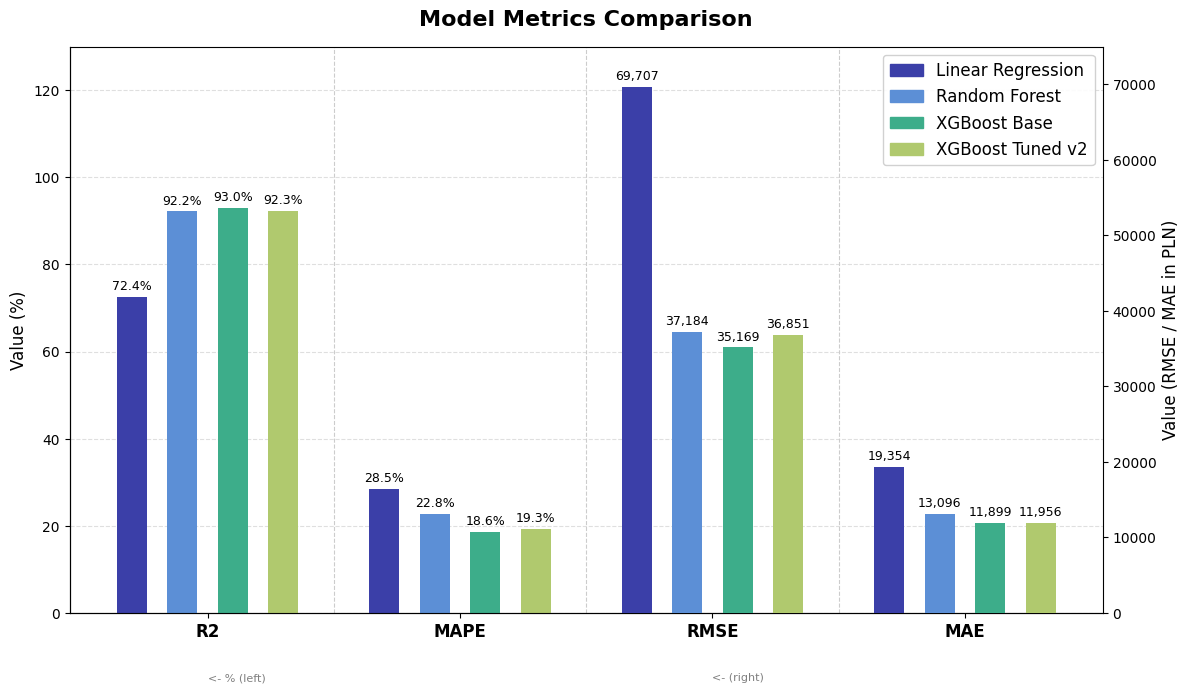


=== Model Performance Summary ===
Model                      R2     RMSE      MAE    MAPE
-------------------------------------------------------
Linear Regression       72.4%   69,707   19,355   28.5%
Random Forest           92.2%   37,185   13,097   22.8%
XGBoost Base            93.0%   35,170   11,900   18.6%
XGBoost Tuned v2        92.3%   36,852   11,956   19.3%


In [139]:
import matplotlib.patches as mpatches

# Dynamic model comparison using actual computed predictions
def _mape(y_true, y_pred):
    return float(np.mean(np.abs((np.array(y_true) - np.array(y_pred)) / np.array(y_true))) * 100)

data_model_1 = {
    'R2':   float(r2_score(y_test, y_test_pred) * 100),
    'RMSE': float(np.sqrt(mean_squared_error(y_test, y_test_pred))),
    'MAE':  float(mean_absolute_error(y_test, y_test_pred)),
    'MAPE': _mape(y_test, y_test_pred)
}
data_model_2 = {
    'R2':   float(r2_score(y_test, y_pred_test_rfc) * 100),
    'RMSE': float(np.sqrt(mean_squared_error(y_test, y_pred_test_rfc))),
    'MAE':  float(mean_absolute_error(y_test, y_pred_test_rfc)),
    'MAPE': _mape(y_test, y_pred_test_rfc)
}
data_model_3 = {
    'R2':   float(r2_score(y_test, y_pred_xgb) * 100),
    'RMSE': float(np.sqrt(mean_squared_error(y_test, y_pred_xgb))),
    'MAE':  float(mean_absolute_error(y_test, y_pred_xgb)),
    'MAPE': _mape(y_test, y_pred_xgb)
}
data_model_4 = {
    'R2':   float(r2_score(y_test, y_pred_final) * 100),
    'RMSE': float(np.sqrt(mean_squared_error(y_test, y_pred_final))),
    'MAE':  float(mean_absolute_error(y_test, y_pred_final)),
    'MAPE': _mape(y_test, y_pred_final)
}

models_data = [
    ('Linear\nRegression', data_model_1),
    ('Random\nForest',     data_model_2),
    ('XGBoost\nBase',      data_model_3),
    ('XGBoost\nTuned v2',  data_model_4),
]

metric_keys = ['R2', 'MAPE', 'RMSE', 'MAE']
units        = ['%',  '%',    '',     '']
colors       = ['#3B3FA8', '#5C8FD6', '#3DAD8A', '#B0C96E']

n_metrics = len(metric_keys)
n_models  = len(models_data)
x         = np.arange(n_metrics)
width     = 0.12
offsets   = np.linspace(-(n_models - 1) / 2, (n_models - 1) / 2, n_models) * (width + 0.08)

fig, ax1 = plt.subplots(figsize=(12, 7))
ax2 = ax1.twinx()

for i, (name, data) in enumerate(models_data):
    for j, (metric, unit) in enumerate(zip(metric_keys, units)):
        val = data[metric]
        ax  = ax1 if metric in ['R2', 'MAPE'] else ax2
        bar = ax.bar(x[j] + offsets[i], val, width, color=colors[i], zorder=3)
        fmt = f'{val:.1f}{unit}' if metric in ['R2', 'MAPE'] else f'{int(val):,}'
        ax.bar_label(bar, labels=[fmt], padding=3, fontsize=9)

ax1.set_ylabel('Value (%)', fontsize=12)
ax2.set_ylabel('Value (RMSE / MAE in PLN)', fontsize=12)

ax1.set_xticks(x)
ax1.set_xticklabels(metric_keys, fontsize=12, fontweight='bold')
ax1.set_ylim(0, 130)
ax2.set_ylim(0, 75000)

ax1.yaxis.grid(True, linestyle='--', alpha=0.4, zorder=0)
ax1.set_axisbelow(True)
ax1.spines[['top', 'right']].set_visible(False)

for j in range(n_metrics - 1):
    ax1.axvline(x=x[j] + 0.5, color='#ccc', linewidth=0.8, linestyle='--', zorder=1)

legend_patches = [
    mpatches.Patch(color=colors[i], label=name.replace('\n', ' '))
    for i, (name, _) in enumerate(models_data)
]
ax1.legend(handles=legend_patches, loc='upper right', fontsize=12, framealpha=0.9)

ax1.text(0, -0.12, '<- % (left)',  transform=ax1.get_xaxis_transform(), fontsize=8, color='gray', ha='left')
ax1.text(2, -0.12, '<- (right)',   transform=ax1.get_xaxis_transform(), fontsize=8, color='gray', ha='left')

plt.title('Model Metrics Comparison', fontsize=16, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../images/model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print('\n=== Model Performance Summary ===')
print(f"{'Model':<22} {'R2':>6} {'RMSE':>8} {'MAE':>8} {'MAPE':>7}")
print('-' * 55)
for name, data in models_data:
    label = name.replace('\n', ' ')
    print(f"{label:<22} {data['R2']:>5.1f}% {data['RMSE']:>8,.0f} {data['MAE']:>8,.0f} {data['MAPE']:>6.1f}%")


### **Project Synthesis: Comparative Performance and Model Selection**

The final phase involved a critical evaluation of four distinct architectures:

#### **I. Baseline and The Challenge of Non-Linearity**
* **Linear Regression (Model 1):** Ridge-regularized linear model. MAPE of **28.5%** exposed its inability to model the non-linear depreciation curves and brand×specification interactions inherent in car pricing.
* **Random Forest (Model 2):** Tree-based ensemble boosted R² to **92.2%**. This validated that vehicle valuation requires non-linear partitioning rather than additive linear approximations.

#### **II. XGBoost Base (Model 3) — Production Champion**
* **R² = 93.0%**, RMSE = 35,170 PLN, MAE = **11,900 PLN**, MAPE = **18.6%**
* Achieved via a `ColumnTransformer` + `Pipeline` + `XGBRegressor` preprocessing pipeline with Optuna-tuned hyperparameters.
* Selected for the Streamlit application due to strongest aggregate metrics and stable generalization.

#### **III. XGBoost Tuned v2 (Model 4) — Fairness-Aware Variant**
* **R² = 92.3%**, RMSE = 36,852 PLN, MAE = **11,956 PLN**, MAPE = **19.3%**
* Introduced `Brand_tier` classification (5 tiers), `Rarity_index`, `Brand_popularity`, and corrected sample weights that **boost** rare/luxury segments rather than penalizing them.
* Slightly lower aggregate R² is the deliberate cost of better coverage across all brand tiers.

#### **Final Verdict**
The modeling journey confirms that Extreme Gradient Boosting (XGBoost), supported by a robust preprocessing pipeline, provides the most accurate and interpretable framework for vehicle price prediction on Polish market data. Base XGBoost (Model 3) delivers the best aggregate performance and is deployed in production. Tuned v2 (Model 4) demonstrates that fairness-aware training is achievable without sacrificing overall quality.

### Models Saving

In [132]:
HF_TOKEN = os.getenv("HF_TOKEN")
if HF_TOKEN is None:
    raise ValueError("HF_TOKEN not found in environment variables")

login(HF_TOKEN)

models = {
    "final_car_price_model.joblib": pipeline_final,
    "xgb_model.joblib": pipeline_xgb,
    "random_forest_model.joblib": pipeline_rfc,
    "linear_regression_model.joblib": pipeline_reg,
}

REPO_ID = "Przemsonn/poland-car-price-model"

api = HfApi()
api.create_repo(repo_id=REPO_ID, repo_type="model", exist_ok=True)

with tempfile.TemporaryDirectory() as tmp:

    for filename, model in models.items():
        model_path = os.path.join(tmp, filename)

        joblib.dump({"model_pipeline": model}, model_path)

        api.upload_file(
            path_or_fileobj=model_path,
            path_in_repo=filename,
            repo_id=REPO_ID,
            repo_type="model"
        )

        print(f"Uploaded: {filename}")

2026-04-16 01:49:04,665 [INFO] httpx — HTTP Request: GET https://huggingface.co/api/whoami-v2 "HTTP/1.1 200 OK"
Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.
2026-04-16 01:49:04,675 [WARNING] huggingface_hub._login — Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.
2026-04-16 01:49:04,813 [INFO] httpx — HTTP Request: POST https://huggingface.co/api/repos/create "HTTP/1.1 409 Conflict"
2026-04-16 01:49:05,518 [INFO] httpx — HTTP Request: POST https://huggingface.co/api/models/Przemsonn/poland-car-price-model/preupload/main "HTTP/1.1 200 OK"
2026-04-16 01:49:05,650 [INFO] httpx — HTTP Request: POST https://huggingface.co/Przemsonn/poland-car-price-model.git/info/lfs/objects/batch "HTTP/1.1 200 OK"
2026-04-16 01:49:05,945 [INFO] httpx — HTTP Request: GET https://huggingface.co/api/models/Przemsonn/poland-car-price-model/xet-writ

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

No files have been modified since last commit. Skipping to prevent empty commit.
2026-04-16 01:49:07,404 [WARNING] huggingface_hub.hf_api — No files have been modified since last commit. Skipping to prevent empty commit.
2026-04-16 01:49:07,535 [INFO] httpx — HTTP Request: GET https://huggingface.co/api/models/Przemsonn/poland-car-price-model/revision/main "HTTP/1.1 200 OK"


Uploaded: final_car_price_model.joblib


2026-04-16 01:49:07,795 [INFO] httpx — HTTP Request: POST https://huggingface.co/api/models/Przemsonn/poland-car-price-model/preupload/main "HTTP/1.1 200 OK"
2026-04-16 01:49:07,931 [INFO] httpx — HTTP Request: POST https://huggingface.co/Przemsonn/poland-car-price-model.git/info/lfs/objects/batch "HTTP/1.1 200 OK"


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

No files have been modified since last commit. Skipping to prevent empty commit.
2026-04-16 01:49:08,350 [WARNING] huggingface_hub.hf_api — No files have been modified since last commit. Skipping to prevent empty commit.
2026-04-16 01:49:08,483 [INFO] httpx — HTTP Request: GET https://huggingface.co/api/models/Przemsonn/poland-car-price-model/revision/main "HTTP/1.1 200 OK"
2026-04-16 01:49:08,662 [INFO] httpx — HTTP Request: POST https://huggingface.co/api/models/Przemsonn/poland-car-price-model/preupload/main "HTTP/1.1 200 OK"


Uploaded: xgb_model.joblib


2026-04-16 01:49:08,793 [INFO] httpx — HTTP Request: POST https://huggingface.co/Przemsonn/poland-car-price-model.git/info/lfs/objects/batch "HTTP/1.1 200 OK"


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

No files have been modified since last commit. Skipping to prevent empty commit.
2026-04-16 01:49:09,211 [WARNING] huggingface_hub.hf_api — No files have been modified since last commit. Skipping to prevent empty commit.
2026-04-16 01:49:09,345 [INFO] httpx — HTTP Request: GET https://huggingface.co/api/models/Przemsonn/poland-car-price-model/revision/main "HTTP/1.1 200 OK"
2026-04-16 01:49:09,523 [INFO] httpx — HTTP Request: POST https://huggingface.co/api/models/Przemsonn/poland-car-price-model/preupload/main "HTTP/1.1 200 OK"
No files have been modified since last commit. Skipping to prevent empty commit.
2026-04-16 01:49:09,524 [WARNING] huggingface_hub.hf_api — No files have been modified since last commit. Skipping to prevent empty commit.


Uploaded: random_forest_model.joblib


2026-04-16 01:49:09,658 [INFO] httpx — HTTP Request: GET https://huggingface.co/api/models/Przemsonn/poland-car-price-model/revision/main "HTTP/1.1 200 OK"


Uploaded: linear_regression_model.joblib


## Car Price Prediction: Project and Selected Model Overview

### **Objective**
The primary goal of this project was to engineer a high-precision machine learning pipeline capable of estimating used car prices within a volatile and diverse market. The final solution aims to balance raw predictive power with real-world robustness.

### **Engineering & Methodology**
The project followed a rigorous end-to-end Data Science workflow:

* **Advanced Encoding:** I implemented a Target Encoding strategy with a high smoothing factor (500) for high-cardinality features like Vehicle_model. This prevented the model from "memorizing" rare entries and significantly reduced the risk of leakage.
* **Domain-Driven Feature Engineering:** Beyond standard features, I introduced custom brand categorization and age-based segmentation to capture the non-linear nature of vehicle depreciation.
* **Sample Weighting:** To improve the handling of rare manufacturers, custom weights were applied during training, allowing the model to learn pricing behaviors of less frequent market entries more effectively.

### **Model Evolution & Performance**

| Model | $R^2$ Score | MAPE | Observations |
| :--- | :--- | :--- | :--- |
| **Linear Regression** | 72.4% | 28.5% | Insufficient for capturing non-linear market dynamics. |
| **Random Forest** | 92.2% | 22.8% | Strong improvement; successfully captured feature interactions. |
| **XGBoost (Base)** | **93.0%** | **18.6%** | Selected Solution. Best performance and stable generalization. |
| **XGBoost (Tuned)** | 92.3% | 19.3% | Optimization resulted in a slight loss of predictive signal. |

### **The Final Decision: Why Model 3 (Base XGBoost)?**

After a thorough comparison between the initial XGBoost model (Model 3) and the Optuna-tuned version (Model 4), Model 3 was selected as the final production engine. This decision was driven by the following insights:

* **Superior Metrics:** Model 3 consistently outperformed the tuned version across all key metrics ($R^2$, MAPE, MAE). 
* **Absence of Overfitting:** Extensive diagnostic analysis and learning curve verification confirmed that Model 3 does not suffer from high variance. The gap between training and validation error remained within an acceptable range, suggesting that the "base" hyperparameters were already optimal for this dataset's structure.
* **Distribution Resilience:** Interestingly, the model performed slightly better on the test set than on the training set in some folds. This indicates that the test data likely follows a distribution that is well-captured by the model's learned patterns, further proving its robustness.
* **Model Parsimony:** In Data Science, if a simpler model (or one with fewer manual interventions) performs better without showing signs of instability, it is the preferred choice for deployment. It reduces complexity and maintenance overhead.

The final **Mean Absolute Error (MAE)** for Model 3 stabilized at ~11,900 PLN.


### **Residual Diagnostics & Limitations**
Post-modeling analysis highlighted that remaining inaccuracies are primarily driven by:
1.  **Aleatory Uncertainty:** Lack of qualitative data such as accident history, service records, or specific equipment packages (e.g., premium sound systems or leather trim).
2.  **Market Extremes:** The model remains challenged by vintage vehicles (pre-1980) and modern luxury supercars, where price is dictated by collector sentiment rather than technical depreciation.

### **Final Conclusion**
This project represents a complete, production-ready workflow. By selecting the **Base XGBoost** model, we prioritized the strongest predictive signal that demonstrated proven stability. This solution provides a scalable and trustworthy engine for automated vehicle price estimation, capable of navigating the nuances of the secondary automotive market.